**Author**: Sabina Gallo   
**ID**: 535785  
**Academic Year**: 2025/2026  
**Course**: AI for Communication and Marketing  

## **Business Scenario**

As a Lead Data Scientist for Olist, the objective of this project is to transform raw marketplace data into a reliable predictive framework for Customer Lifetime Value. The Marketing Department needs to allocate the next quarter's budget and design loyalty campaigns based on the expected future value of the current customer base. The analysis therefore goes beyond describing historical sales and builds a clean customer-level foundation for both probabilistic CLTV models and machine learning predictions.

Olist operates in a non-contractual e-commerce setting, meaning that customers do not formally cancel a subscription when they stop purchasing. Their future value must therefore be inferred from transactional behaviour: how recently they purchased, how often they purchase, how much they spend, and whether their order experience contains signals that may influence future engagement.

The final objective is to estimate future customer revenue, compare alternative modelling approaches, and translate the results into actionable budget-allocation and win-back decisions.

## **Libraries and Setup**  

The following block imports the libraries required for data manipulation, visual exploration, probabilistic modelling and machine learning. A common visual configuration is also defined to ensure that all figures remain consistent and readable throughout the notebook.


In [1]:
import pandas as pd
import numpy as np

from datetime import timedelta

import matplotlib.pyplot as plt
import seaborn as sns
from lifetimes import BetaGeoFitter
from lifetimes import  GammaGammaFitter
from lifetimes.plotting import plot_frequency_recency_matrix, plot_probability_alive_matrix

from lifetimes.utils import calibration_and_holdout_data
from lifetimes.plotting import plot_calibration_purchases_vs_holdout_purchases
import warnings

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV
from sklearn.dummy import DummyRegressor


sns.set_theme(
    style="whitegrid",
    context="notebook",
    palette="Set2"
)

plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

# Reusable plotting helpers

def add_bar_labels(ax, fmt="{:,.0f}", padding=3):
    """
    Add value labels on top of vertical bars.
    """
    for container in ax.containers:
        ax.bar_label(container, fmt=fmt, padding=padding)


def add_horizontal_bar_labels(ax, fmt="{:,.0f}", padding=3):
    """
    Add value labels at the end of horizontal bars.
    """
    for container in ax.containers:
        ax.bar_label(container, fmt=fmt, padding=padding)

### **Data Loading**

The Olist dataset is composed of multiple relational tables containing orders, customers, payments, items, reviews, products, sellers, geolocation information and product-category translations. This structure reflects the complexity of a real e-commerce marketplace: customer value is not contained in a single file, but must be reconstructed by combining transactional, monetary, product and customer information.

At this stage, the objective is not yet to build a predictive model. The priority is to understand the granularity of each table and determine how the different sources can be joined without duplicating orders or artificially inflating revenue.

In [2]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

DATA_PATH = "data/"

In [3]:
orders = pd.read_csv(DATA_PATH + "olist_orders_dataset.csv")
customers = pd.read_csv(DATA_PATH + "olist_customers_dataset.csv")
payments = pd.read_csv(DATA_PATH + "olist_order_payments_dataset.csv")
items = pd.read_csv(DATA_PATH + "olist_order_items_dataset.csv")
reviews = pd.read_csv(DATA_PATH + "olist_order_reviews_dataset.csv")
products = pd.read_csv(DATA_PATH + "olist_products_dataset.csv")
sellers = pd.read_csv(DATA_PATH + "olist_sellers_dataset.csv")
geolocation = pd.read_csv(DATA_PATH + "olist_geolocation_dataset.csv")
category_translation = pd.read_csv(DATA_PATH + "product_category_name_translation.csv")

In [4]:
tables = {
    "orders": orders,
    "customers": customers,
    "payments": payments,
    "items": items,
    "reviews": reviews,
    "products": products,
    "sellers": sellers,
    "geolocation": geolocation,
    "category_translation": category_translation
}

overview = []

for name, df in tables.items():
    overview.append({
        "table": name,
        "rows": df.shape[0],
        "columns": df.shape[1],
        "duplicated_rows": df.duplicated().sum()
    })

overview_df = pd.DataFrame(overview).sort_values("rows", ascending=False)
overview_df

,table,rows,columns,duplicated_rows
7,geolocation,1000163,5,261831
3,items,112650,7,0
2,payments,103886,5,0
0,orders,99441,8,0
1,customers,99441,5,0
4,reviews,99224,7,0
5,products,32951,9,0
6,sellers,3095,4,0
8,category_translation,71,2,0


The overview confirms that the source tables operate at different levels of granularity. The orders and customers tables each contain 99,441 rows, while the payment and item tables contain more records because a single order may include multiple payment methods or several products. Consequently, these tables cannot be merged directly with the order table without first being aggregated at order level.

The geolocation table contains a large number of exact duplicate rows. This is not interpreted as transactional duplication, because several geographical observations may refer to the same zip-code prefix and geolocation is not used as a core input in the initial CLTV framework. The main commercial tables do not contain exact duplicated rows, providing a reliable starting point for the subsequent audit.

In [5]:
for name, df in tables.items():
    print(f"\n{name.upper()}")
    print(df.columns.tolist())


ORDERS
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']

CUSTOMERS
['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']

PAYMENTS
['order_id', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value']

ITEMS
['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']

REVIEWS
['review_id', 'order_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp']

PRODUCTS
['product_id', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']

SELLERS
['seller_id', 'seller_zip_code_prefix', 'seller_city', 'seller_state']

GEOLOCATION
['geolocation_zip_code

The column inspection clarifies the role of each source in the analytical pipeline. The orders table provides the temporal backbone through purchase, approval, carrier-delivery and customer-delivery timestamps. The customers table links each order to a persistent customer identity. Payments provide the realized monetary value of each transaction, while order items provide product value, freight cost, seller information and product composition.

Reviews and product categories can later enrich the customer profile with experience and preference signals. However, because these tables have different levels of granularity, they must first be summarized before being merged into a unified order-level table.



In [6]:
id_checks = pd.DataFrame({
    "table": [
        "orders",
        "customers",
        "payments",
        "items",
        "reviews",
        "products",
        "sellers",
        "geolocation"
    ],
    "key_checked": [
        "order_id",
        "customer_id",
        "order_id",
        "order_id",
        "order_id",
        "product_id",
        "seller_id",
        "geolocation_zip_code_prefix"
    ],
    "n_rows": [
        len(orders),
        len(customers),
        len(payments),
        len(items),
        len(reviews),
        len(products),
        len(sellers),
        len(geolocation)
    ],
    "n_unique_key_values": [
        orders["order_id"].nunique(),
        customers["customer_id"].nunique(),
        payments["order_id"].nunique(),
        items["order_id"].nunique(),
        reviews["order_id"].nunique(),
        products["product_id"].nunique(),
        sellers["seller_id"].nunique(),
        geolocation["geolocation_zip_code_prefix"].nunique()
    ]
})

id_checks

,table,key_checked,n_rows,n_unique_key_values
0,orders,order_id,99441,99441
1,customers,customer_id,99441,99441
2,payments,order_id,103886,99440
3,items,order_id,112650,98666
4,reviews,order_id,99224,98673
5,products,product_id,32951,32951
6,sellers,seller_id,3095,3095
7,geolocation,geolocation_zip_code_prefix,1000163,19015


In [7]:
customer_id_summary = pd.DataFrame({
    "identifier": ["customer_id", "customer_unique_id"],
    "n_unique_values": [
        customers["customer_id"].nunique(),
        customers["customer_unique_id"].nunique()
    ],
    "n_rows": [
        len(customers),
        len(customers)
    ]
})

customer_id_summary

,identifier,n_unique_values,n_rows
0,customer_id,99441,99441
1,customer_unique_id,96096,99441


The identifier audit confirms that `order_id` is unique in the orders table but repeated in the payment, item and review tables, reflecting their one-to-many relationship with an order.

A particularly important distinction emerges between `customer_id` and `customer_unique_id`. The first identifier is unique for each order-level customer record, whereas `customer_unique_id` links multiple orders made by the same individual. The customer table contains 99,441 distinct `customer_id` values but 96,096 distinct `customer_unique_id` values. Therefore, `customer_unique_id` is used as the persistent customer identifier for RFM construction, CLTV estimation and holdout evaluation.

In [8]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [9]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [10]:
payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [11]:
items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [12]:
reviews.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [13]:
products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


## **Data Audit and Quality**

This section evaluates the reliability of the source data before constructing the transactional dataset. The audit covers missing values, order completion status, chronological inconsistencies, impossible numerical values and extreme monetary observations. Each issue is first investigated and then linked to an explicit cleaning decision, rather than being removed automatically.

In [14]:
def missing_values_summary(tables_dict):
    """
    Create a missing values summary for each table.
    """
    summaries = []

    for table_name, df in tables_dict.items():
        missing_count = df.isna().sum()
        missing_pct = (df.isna().mean() * 100).round(2)

        summary = pd.DataFrame({
            "table": table_name,
            "column": missing_count.index,
            "missing_count": missing_count.values,
            "missing_pct": missing_pct.values
        })

        summary = summary[summary["missing_count"] > 0]
        summaries.append(summary)

    return pd.concat(summaries, ignore_index=True).sort_values(
        ["table", "missing_pct"], 
        ascending=[True, False]
    )

missing_summary_df = missing_values_summary(tables)
missing_summary_df

,table,column,missing_count,missing_pct
2,orders,order_delivered_customer_date,2965,2.98
1,orders,order_delivered_carrier_date,1783,1.79
0,orders,order_approved_at,160,0.16
5,products,product_category_name,610,1.85
6,products,product_name_lenght,610,1.85
7,products,product_description_lenght,610,1.85
8,products,product_photos_qty,610,1.85
9,products,product_weight_g,2,0.01
10,products,product_length_cm,2,0.01
11,products,product_height_cm,2,0.01


Missingness is concentrated in fields that are not essential for the core CLTV calculation. Review titles and messages are frequently absent because customers can submit a numerical score without writing textual feedback. Missing delivery and approval timestamps are mainly associated with orders that did not complete the full delivery lifecycle.

Product metadata contains a smaller proportion of missing values. These records are not removed because the corresponding transactions remain valid; missing product categories will instead be assigned to an `unknown` category. No imputation is performed at this stage because the appropriate treatment depends on whether each field is later used for transactional aggregation, customer profiling or machine learning.

In [15]:
order_status_counts = (
    orders["order_status"]
    .value_counts(dropna=False)
    .reset_index()
)

order_status_counts.columns = ["order_status", "n_orders"]
order_status_counts["percentage"] = (
    order_status_counts["n_orders"] / len(orders) * 100
).round(2)

order_status_counts

,order_status,n_orders,percentage
0,delivered,96478,97.02
1,shipped,1107,1.11
2,canceled,625,0.63
3,unavailable,609,0.61
4,invoiced,314,0.32
5,processing,301,0.30
6,created,5,0.01
7,approved,2,0.00


Delivered orders represent 97.02% of the order table, while cancelled, unavailable, shipped and still-processing orders form a relatively small residual share. Because CLTV must be based on realized transactions rather than attempted purchases, only delivered orders are retained for revenue aggregation and customer-value modelling.

The dataset does not contain a separate table identifying product returns after delivery. Therefore, cancellations and incomplete transactions are handled through `order_status`, while post-delivery returns cannot be observed directly in the available data.

### **Date Conversion**

The date audit shows that customer purchases span from September 2016 to October 2018, while estimated delivery dates extend to November 2018. The purchase timestamp contains no missing values and therefore provides a reliable temporal reference for defining the observation, calibration and holdout periods.

Approval and delivery timestamps contain some missing values because not every order completed the full operational lifecycle. These variables may still provide useful customer-experience signals, but they are not used to determine whether a transaction belongs to the calibration or holdout period.

In [16]:
date_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_cols:
    orders[col] = pd.to_datetime(orders[col], errors="coerce")

date_audit = []

for col in date_cols:
    date_audit.append({
        "date_column": col,
        "missing_count": orders[col].isna().sum(),
        "missing_pct": round(orders[col].isna().mean() * 100, 2),
        "min_date": orders[col].min(),
        "max_date": orders[col].max()
    })

date_audit_df = pd.DataFrame(date_audit)
date_audit_df

,date_column,missing_count,missing_pct,min_date,max_date
0,order_purchase_timestamp,0,0.00,2016-09-04 21:15:19,2018-10-17 17:30:18
1,order_approved_at,160,0.16,2016-09-15 12:16:38,2018-09-03 17:40:06
2,order_delivered_carrier_date,1783,1.79,2016-10-08 10:34:01,2018-09-11 19:48:28
3,order_delivered_customer_date,2965,2.98,2016-10-11 13:46:32,2018-10-17 13:22:46
4,order_estimated_delivery_date,0,0.00,2016-09-30 00:00:00,2018-11-12 00:00:00


The date audit shows that the dataset covers purchases from September 2016 to October 2018, while estimated delivery dates extend to November 2018. Thsi gives a clear hstorical widnow for the analysis. The purchase timestamp has no missing values, which is fundamental because it will be used to define the observation period, calibration period and customer recency.

Some operational timestamps, such as approval and delivery dates, contain missing values. This is expected because not all orders completed the full delivery process. 

### **Date Consistency**

The date consistency check identifies potential chronological anomalies in the order lifecycle.

In [17]:
date_inconsistencies = pd.DataFrame({
    "check": [
        "approved before purchase",
        "carrier delivery before approval",
        "customer delivery before carrier delivery",
        "customer delivery later than estimated delivery"
    ],
    "n_cases": [
        (orders["order_approved_at"] < orders["order_purchase_timestamp"]).sum(),
        (orders["order_delivered_carrier_date"] < orders["order_approved_at"]).sum(),
        (orders["order_delivered_customer_date"] < orders["order_delivered_carrier_date"]).sum(),
        (orders["order_delivered_customer_date"] > orders["order_estimated_delivery_date"]).sum()
    ]
})

date_inconsistencies

,check,n_cases
0,approved before purchase,0
1,carrier delivery before approval,1359
2,customer delivery before carrier delivery,23
3,customer delivery later than estimated delivery,7827


The audit identifies no cases in which an order was approved before being purchased. A limited number of records show inconsistencies between carrier, approval and customer-delivery timestamps, which may reflect operational recording delays rather than invalid purchases.

The 7,827 deliveries occurring after the estimated date are not treated as data errors. They represent a meaningful customer-experience outcome and can later be transformed into a late-delivery feature for the machine learning model. Since the purchase timestamps and payment values remain valid, these orders are retained in the transactional dataset.

### **Numeric Anomalies Check**

In [18]:
numeric_anomalies = pd.DataFrame({
    "check": [
        "payment_value <= 0",
        "payment_installments <= 0",
        "price <= 0",
        "freight_value < 0",
        "review_score outside 1-5"
    ],
    "n_cases": [
        (payments["payment_value"] <= 0).sum(),
        (payments["payment_installments"] <= 0).sum(),
        (items["price"] <= 0).sum(),
        (items["freight_value"] < 0).sum(),
        (~reviews["review_score"].between(1, 5)).sum()
    ]
})

numeric_anomalies

,check,n_cases
0,payment_value <= 0,9
1,payment_installments <= 0,2
2,price <= 0,0
3,freight_value < 0,0
4,review_score outside 1-5,0


The numerical audit finds no non-positive product prices, no negative freight values and no review scores outside the valid 1–5 range. Nine payment rows have a non-positive payment value, while two rows report non-positive installment counts.

The main monetary anomaly therefore concerns a very small number of payment records with zero value. These observations are inspected individually before deciding how they should be treated in the transactional dataset.

### **Non-positive payments**

In [19]:
# Inspect payments with non-positive value before deciding how to treat them

non_positive_payments = payments[payments["payment_value"] <= 0].copy()

non_positive_payments_details = (
    non_positive_payments
    .merge(
        orders[[
            "order_id",
            "customer_id",
            "order_status",
            "order_purchase_timestamp"
        ]],
        on="order_id",
        how="left"
    )
    .merge(
        customers[[
            "customer_id",
            "customer_unique_id",
            "customer_state"
        ]],
        on="customer_id",
        how="left"
    )
)

non_positive_payments_details

,order_id,payment_sequential,payment_type,payment_installments,payment_value,customer_id,order_status,order_purchase_timestamp,customer_unique_id,customer_state
0,8bcbe01d44d147f901cd3192671144db,4,voucher,1,0.0,f2def7f64f36952f2f5a9791f0285f34,delivered,2018-01-24 23:24:14,cc5aa1b8337e394da54980226bb0f6d4,RJ
1,fa65dad1b0e818e3ccc5cb0e39231352,14,voucher,1,0.0,9af2372a1e49340278e7c1ef8d749f34,shipped,2017-04-20 12:45:34,8af7ac63b2efbcbd88e5b11505e8098a,MT
2,6ccb433e00daae1283ccc956189c82ae,4,voucher,1,0.0,843b211abe7b0264dd4a69eafc5bdf43,delivered,2017-10-26 23:51:35,677ad9cdca6c47c733f0cc6e23d7bb4c,RJ
3,4637ca194b6387e2d538dc89b124b0ee,1,not_defined,1,0.0,a73c1f73f5772cf801434bf984b0b1a7,canceled,2018-09-03 14:14:25,968fac81e2c44fb6c1e3ac2a45e6a102,SP
4,00b1cb0320190ca0daa2c88b35206009,1,not_defined,1,0.0,3532ba38a3fd242259a514ac2b6ae6b6,canceled,2018-08-28 15:26:39,4fa4365000c7090fcb8cad5713c6d3db,SP
5,45ed6e85398a87c253db47c2d9f48216,3,voucher,1,0.0,8eab8f9b3c744b76b65f7a2c0c8f2d6c,delivered,2017-06-08 21:18:45,e4000306cf2f63714e6bb70dd20a6592,GO
6,fa65dad1b0e818e3ccc5cb0e39231352,13,voucher,1,0.0,9af2372a1e49340278e7c1ef8d749f34,shipped,2017-04-20 12:45:34,8af7ac63b2efbcbd88e5b11505e8098a,MT
7,c8c528189310eaa44a745b8d9d26908b,1,not_defined,1,0.0,197a2a6a77da93f678ea0d379f21da0a,canceled,2018-08-28 20:05:14,6ba987d564bad1f9da8e14b9d3b71c8f,SP
8,b23878b3e8eb4d25a158f57d96331b18,4,voucher,1,0.0,648121b599d98c420ef93f6135f8c80c,delivered,2017-05-27 19:20:24,9077449283dc1319d5e51fb3159b28e2,ES


In [20]:
non_positive_summary = pd.DataFrame({
    "check": [
        "number of non-positive payment rows",
        "unique orders involved",
        "unique customers involved"
    ],
    "value": [
        len(non_positive_payments_details),
        non_positive_payments_details["order_id"].nunique(),
        non_positive_payments_details["customer_unique_id"].nunique()
    ]
})

non_positive_summary

,check,value
0,number of non-positive payment rows,9
1,unique orders involved,8
2,unique customers involved,8


In [21]:
non_positive_payments_details.groupby(
    ["payment_type", "order_status"]
).size().reset_index(name="n_cases")

,payment_type,order_status,n_cases
0,not_defined,canceled,3
1,voucher,delivered,4
2,voucher,shipped,2


The nine non-positive payment records correspond to eight orders and eight distinct customers. Three records are linked to cancelled orders, two to orders still marked as shipped, and four to delivered orders paid through vouchers.

Because a zero payment does not represent positive realized revenue, these rows are excluded before payment aggregation. This decision affects only a negligible fraction of the dataset and prevents zero-value transactions from entering the customer revenue history.

### **Extreme Monetary Values**

After investigating impossible values, the analysis examines valid but unusually large transactions. Extreme customer spending should not be removed automatically because high-value customers are central to CLTV analysis. Percentiles are therefore used to understand the distribution and to decide whether robust transformations are preferable to deletion.

In [22]:
monetary_percentiles = pd.DataFrame({
    "variable": ["payment_value", "item_price", "freight_value"],
    "min": [
        payments["payment_value"].min(),
        items["price"].min(),
        items["freight_value"].min()
    ],
    "p25": [
        payments["payment_value"].quantile(0.25),
        items["price"].quantile(0.25),
        items["freight_value"].quantile(0.25)
    ],
    "median": [
        payments["payment_value"].median(),
        items["price"].median(),
        items["freight_value"].median()
    ],
    "p75": [
        payments["payment_value"].quantile(0.75),
        items["price"].quantile(0.75),
        items["freight_value"].quantile(0.75)
    ],
    "p95": [
        payments["payment_value"].quantile(0.95),
        items["price"].quantile(0.95),
        items["freight_value"].quantile(0.95)
    ],
    "p99": [
        payments["payment_value"].quantile(0.99),
        items["price"].quantile(0.99),
        items["freight_value"].quantile(0.99)
    ],
    "max": [
        payments["payment_value"].max(),
        items["price"].max(),
        items["freight_value"].max()
    ]
})

monetary_percentiles.round(2)

,variable,min,p25,median,p75,p95,p99,max
0,payment_value,0.00,56.79,100.00,171.84,437.64,1039.92,13664.08
1,item_price,0.85,39.90,74.99,134.90,349.90,890.00,6735.00
2,freight_value,0.00,13.08,16.26,21.15,45.12,84.52,409.68


All three monetary variables are strongly right-skewed. The maximum payment value is substantially higher than the 99th percentile, confirming the presence of a small number of very large transactions. However, these values are positive and may represent genuine high-value purchases rather than recording errors.

The original monetary values are therefore preserved for revenue aggregation and probabilistic CLTV estimation. Robust capped and log-transformed versions will be created separately for exploratory visualization and machine learning, where extreme scale differences could otherwise dominate model training.

### **Cleaning Decisions for the Next Step**

| Issue | Decision | Reason |
|---|---|---|
| Non-delivered orders | Exclude | CLTV must be based on completed transactions |
| Returns and cancellations | Exclude cancelled and incomplete orders through `order_status` | No separate post-delivery returns table is available |
| Missing delivery dates | Recheck after delivered-order filter | Mostly associated with non-completed orders |
| Chronological delivery anomalies | Retain valid transactions; anomalies remain available for optional customer-experience indicators | Purchase timestamp and payment remain valid |
| Missing review comments | Keep records and ignore text fields | Text comments are not required for CLTV |
| Missing product categories | Replace with `unknown` | Transaction remains valid and category may still support profiling |
| Payment value <= 0 | Exclude | No positive realized customer value |
| Extreme monetary values | Preserve raw values and create robust transformations | High-value customers are relevant for CLTV |
| Multiple payment or item rows per order | Aggregate before merging | Prevent duplicated orders and inflated revenue |

## **Order-Level Dataset Construction**

Payments, items and reviews may contain multiple rows for the same order. Directly merging these tables would create one-to-many joins, duplicating transactions and inflating revenue, item and review counts.

Each source table is therefore aggregated to one row per order before the final merge. This preserves the correct order-level granularity required for revenue measurement, RFM construction and subsequent CLTV modelling.

### **Payment Aggregation**


In [23]:
# Exclude non-positive payments before aggregating payment information
payments_positive = payments[payments["payment_value"] > 0].copy()

# Aggregate payment information at order level
payments_order = (
    payments_positive
    .groupby("order_id")
    .agg(
        payment_value=("payment_value", "sum"),
        n_payment_records=("payment_value", "size"),
        avg_installments=("payment_installments", "mean"),
        max_installments=("payment_installments", "max"),
        n_payment_types=("payment_type", "nunique"),
        main_payment_type=("payment_type", lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
    )
    .reset_index()
)

payments_order.head()

,order_id,payment_value,n_payment_records,avg_installments,max_installments,n_payment_types,main_payment_type
0,00010242fe8c5a6d1ba2dd792cb16214,72.19,1,2.0,2,1,credit_card
1,00018f77f2f0320c557190d7a144bdd3,259.83,1,3.0,3,1,credit_card
2,000229ec398224ef6ca0657da4fc703e,216.87,1,5.0,5,1,credit_card
3,00024acbcdf0a6daa1e931b038114c75,25.78,1,2.0,2,1,credit_card
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04,1,3.0,3,1,credit_card


In [24]:
payment_aggregation_check = pd.DataFrame({
    "metric": [
        "raw payment rows",
        "positive payment rows",
        "unique orders in raw payments",
        "unique orders after positive-payment filter",
        "rows in payments_order"
    ],
    "value": [
        len(payments),
        len(payments_positive),
        payments["order_id"].nunique(),
        payments_positive["order_id"].nunique(),
        len(payments_order)
    ]
})

payment_aggregation_check

,metric,value
0,raw payment rows,103886
1,positive payment rows,103877
2,unique orders in raw payments,99440
3,unique orders after positive-payment filter,99437
4,rows in payments_order,99437


Payment records are aggregated before being joined to the order table. The sum of positive payment values represents the realized revenue associated with each order, while the number of payment records, number of payment types and instalment variables preserve information about payment complexity.

After filtering non-positive values, the resulting table contains one row per order. This prevents orders paid through multiple methods from being duplicated during the subsequent merge.

### **Item Aggregation**

In [25]:
# Aggregate item information at order level

items_order = (
    items
    .groupby("order_id")
    .agg(
        n_items=("order_item_id", "count"),
        n_unique_products=("product_id", "nunique"),
        n_unique_sellers=("seller_id", "nunique"),
        item_value=("price", "sum"),
        freight_value=("freight_value", "sum"),
        avg_item_price=("price", "mean"),
        max_item_price=("price", "max")
    )
    .reset_index()
)

# Total item-related order value
items_order["item_total_value"] = items_order["item_value"] + items_order["freight_value"]

items_order.head()

,order_id,n_items,n_unique_products,n_unique_sellers,item_value,freight_value,avg_item_price,max_item_price,item_total_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,1,1,58.90,13.29,58.90,58.90,72.19
1,00018f77f2f0320c557190d7a144bdd3,1,1,1,239.90,19.93,239.90,239.90,259.83
2,000229ec398224ef6ca0657da4fc703e,1,1,1,199.00,17.87,199.00,199.00,216.87
3,00024acbcdf0a6daa1e931b038114c75,1,1,1,12.99,12.79,12.99,12.99,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,1,1,199.90,18.14,199.90,199.90,218.04


In [26]:
item_aggregation_check = pd.DataFrame({
    "metric": [
        "raw item rows",
        "unique orders in raw items",
        "rows in items_order",
        "unique products in raw items",
        "unique sellers in raw items"
    ],
    "value": [
        len(items),
        items["order_id"].nunique(),
        len(items_order),
        items["product_id"].nunique(),
        items["seller_id"].nunique()
    ]
})

item_aggregation_check

,metric,value
0,raw item rows,112650
1,unique orders in raw items,98666
2,rows in items_order,98666
3,unique products in raw items,32951
4,unique sellers in raw items,3095


The order-item table is similarly aggregated to one row per order. In addition to the total product and freight value, the aggregation preserves information about basket size, product variety and seller variety. These variables may later help explain future customer value because they describe both the economic size and the structural complexity of each purchase.

### **Review aggregation and product category**

In [27]:
# Aggregate review information at order level
# Some orders may have more than one review record, so we summarize them before merging.

reviews_order = (
    reviews
    .groupby("order_id")
    .agg(
        review_score=("review_score", "mean"),
        n_reviews=("review_id", "nunique")
    )
    .reset_index()
)

reviews_order.head()

,order_id,review_score,n_reviews
0,00010242fe8c5a6d1ba2dd792cb16214,5.0,1
1,00018f77f2f0320c557190d7a144bdd3,4.0,1
2,000229ec398224ef6ca0657da4fc703e,5.0,1
3,00024acbcdf0a6daa1e931b038114c75,4.0,1
4,00042b26cf59d7ce69dfabb4e55b4fd9,5.0,1


In [28]:
# Add English product category names to item-level data

items_with_categories = (
    items
    .merge(
        products[["product_id", "product_category_name"]],
        on="product_id",
        how="left"
    )
    .merge(
        category_translation,
        on="product_category_name",
        how="left"
    )
)

# Replace missing category names with "unknown"
items_with_categories["product_category_name_english"] = (
    items_with_categories["product_category_name_english"]
    .fillna("unknown")
)

In [29]:
# Identify the main product category of each order.
# The main category is defined as the category with the highest item value within the order.

category_value_by_order = (
    items_with_categories
    .groupby(["order_id", "product_category_name_english"])
    .agg(category_item_value=("price", "sum"))
    .reset_index()
)

main_category_order = (
    category_value_by_order
    .sort_values(["order_id", "category_item_value"], ascending=[True, False])
    .drop_duplicates("order_id")
    .rename(columns={"product_category_name_english": "main_product_category"})
    [["order_id", "main_product_category"]]
)

main_category_order.head()

,order_id,main_product_category
0,00010242fe8c5a6d1ba2dd792cb16214,cool_stuff
1,00018f77f2f0320c557190d7a144bdd3,pet_shop
2,000229ec398224ef6ca0657da4fc703e,furniture_decor
3,00024acbcdf0a6daa1e931b038114c75,perfumery
4,00042b26cf59d7ce69dfabb4e55b4fd9,garden_tools


In [30]:
review_category_check = pd.DataFrame({
    "metric": [
        "rows in raw reviews",
        "unique orders in raw reviews",
        "rows in reviews_order",
        "rows in items_with_categories",
        "orders with main category"
    ],
    "value": [
        len(reviews),
        reviews["order_id"].nunique(),
        len(reviews_order),
        len(items_with_categories),
        main_category_order["order_id"].nunique()
    ]
})

review_category_check

,metric,value
0,rows in raw reviews,99224
1,unique orders in raw reviews,98673
2,rows in reviews_order,98673
3,rows in items_with_categories,112650
4,orders with main category,98666


Review scores are averaged when an order has more than one review record, producing a single experience measure per transaction. Product categories are translated into English, and unavailable categories are grouped under `unknown` rather than causing the corresponding order to be removed.

For multi-category orders, the main product category is defined as the category contributing the highest product value. This creates one interpretable preference signal for each order while preserving the one-row-per-order structure required for subsequent aggregation.

### **FInal Order-Level Merge**

In [31]:
# Keep only delivered orders, because CLTV should be based on completed transactions
delivered_orders = orders[orders["order_status"] == "delivered"].copy()

# Build the final order-level transactional dataset
order_level = (
    delivered_orders
    .merge(
        customers,
        on="customer_id",
        how="left"
    )
    .merge(
        payments_order,
        on="order_id",
        how="left"
    )
    .merge(
        items_order,
        on="order_id",
        how="left"
    )
    .merge(
        reviews_order,
        on="order_id",
        how="left"
    )
    .merge(
        main_category_order,
        on="order_id",
        how="left"
    )
)

order_level.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,payment_value,n_payment_records,avg_installments,max_installments,n_payment_types,main_payment_type,n_items,n_unique_products,n_unique_sellers,item_value,freight_value,avg_item_price,max_item_price,item_total_value,review_score,n_reviews,main_product_category
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,38.71,3.0,1.0,1.0,2.0,voucher,1,1,1,29.99,8.72,29.99,29.99,38.71,4.0,1.0,housewares
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,141.46,1.0,1.0,1.0,1.0,boleto,1,1,1,118.70,22.76,118.70,118.70,141.46,4.0,1.0,perfumery
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,179.12,1.0,3.0,3.0,1.0,credit_card,1,1,1,159.90,19.22,159.90,159.90,179.12,5.0,1.0,auto
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,72.20,1.0,1.0,1.0,1.0,credit_card,1,1,1,45.00,27.20,45.00,45.00,72.20,5.0,1.0,pet_shop
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,28.62,1.0,1.0,1.0,1.0,credit_card,1,1,1,19.90,8.72,19.90,19.90,28.62,5.0,1.0,stationery


In [32]:
order_level_check = pd.DataFrame({
    "metric": [
        "delivered orders",
        "rows in order_level",
        "unique orders in order_level",
        "unique customers in order_level",
        "missing customer_unique_id",
        "missing payment_value",
        "missing item_value",
        "missing review_score",
        "missing main_product_category"
    ],
    "value": [
        len(delivered_orders),
        len(order_level),
        order_level["order_id"].nunique(),
        order_level["customer_unique_id"].nunique(),
        order_level["customer_unique_id"].isna().sum(),
        order_level["payment_value"].isna().sum(),
        order_level["item_value"].isna().sum(),
        order_level["review_score"].isna().sum(),
        order_level["main_product_category"].isna().sum()
    ]
})

order_level_check

,metric,value
0,delivered orders,96478
1,rows in order_level,96478
2,unique orders in order_level,96478
3,unique customers in order_level,93358
4,missing customer_unique_id,0
5,missing payment_value,1
6,missing item_value,0
7,missing review_score,646
8,missing main_product_category,0


The merged table preserves exactly one row for each delivered order, confirming that the prior aggregations prevented one-to-many joins from duplicating transactions. Customer identifiers and item values are complete, while only one delivered order lacks a valid positive payment value.

Review scores remain missing for 646 orders because not every customer submitted a review. These values are retained as missing rather than being imputed at this stage, since the review is an optional behavioural feature and is not required for the core RFM or probabilistic CLTV calculations.

In [33]:
# Remove delivered orders without valid positive payment value
# Payment value is required because CLTV is based on realized customer revenue.

order_level_clean = order_level.dropna(subset=["payment_value"]).copy()

In [34]:
order_level_clean_check = pd.DataFrame({
    "metric": [
        "rows in order_level before payment filter",
        "rows in order_level_clean",
        "unique orders in order_level_clean",
        "unique customers in order_level_clean",
        "missing payment_value",
        "missing item_value",
        "missing review_score",
        "missing main_product_category"
    ],
    "value": [
        len(order_level),
        len(order_level_clean),
        order_level_clean["order_id"].nunique(),
        order_level_clean["customer_unique_id"].nunique(),
        order_level_clean["payment_value"].isna().sum(),
        order_level_clean["item_value"].isna().sum(),
        order_level_clean["review_score"].isna().sum(),
        order_level_clean["main_product_category"].isna().sum()
    ]
})

order_level_clean_check

,metric,value
0,rows in order_level before payment filter,96478
1,rows in order_level_clean,96477
2,unique orders in order_level_clean,96477
3,unique customers in order_level_clean,93357
4,missing payment_value,0
5,missing item_value,0
6,missing review_score,646
7,missing main_product_category,0


The final cleaning step removes the single delivered order without a valid positive payment value. The resulting dataset contains 96,477 completed orders associated with 93,357 distinct customers.

No customer or item information is lost, and the remaining review-score missingness is intentionally preserved for later preprocessing. This table now provides the clean order-level transactional foundation used for EDA, RFM construction, calibration–holdout splitting and predictive modelling.

## **Data Foundation Funnel**

The following funnel summarizes how the raw order population is progressively transformed into the final analytical dataset. Each stage is calculated along the same sequential cleaning path, making the effect of the filtering decisions transparent.

In [35]:
# True sequential data foundation funnel
# Each step is calculated on the same logical path from raw orders to the final modeling table.

data_funnel = pd.DataFrame({
    "step": [
        "Raw orders",
        "Delivered orders",
        "Delivered orders with valid payment",
        "Delivered orders with item information",
        "Final clean order-level table"
    ],
    "n_orders": [
        orders["order_id"].nunique(),
        delivered_orders["order_id"].nunique(),
        order_level.dropna(subset=["payment_value"])["order_id"].nunique(),
        order_level.dropna(subset=["payment_value", "item_value"])["order_id"].nunique(),
        order_level_clean["order_id"].nunique()
    ]
})

data_funnel

,step,n_orders
0,Raw orders,99441
1,Delivered orders,96478
2,Delivered orders with valid payment,96477
3,Delivered orders with item information,96477
4,Final clean order-level table,96477


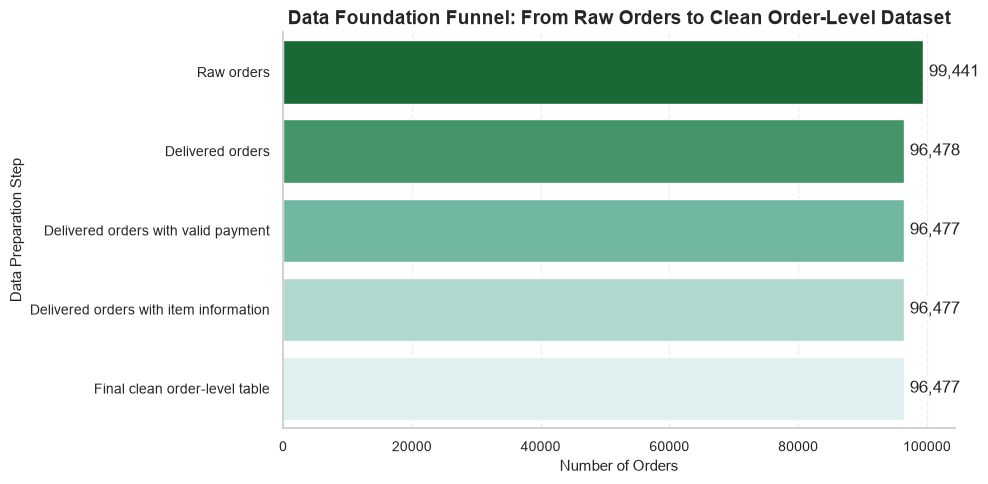

In [36]:
plt.figure(figsize=(10, 5))

ax = sns.barplot(
    data=data_funnel,
    x="n_orders",
    y="step",
    hue="step",
    palette="BuGn_r",
    legend=False
)

add_horizontal_bar_labels(ax, fmt="{:,.0f}", padding=4)

plt.title("Data Foundation Funnel: From Raw Orders to Clean Order-Level Dataset")
plt.xlabel("Number of Orders")
plt.ylabel("Data Preparation Step")
plt.grid(axis="x", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

The main reduction occurs when incomplete orders are excluded: the dataset decreases from 99,441 raw orders to 96,478 delivered orders. The positive-payment filter removes only one additional delivered order, while no further transactions are lost because of missing item information.

The final analytical table therefore retains approximately 97% of the original order population. This indicates that the cleaning strategy improves transactional consistency without materially reducing the available customer history.

### **Order-level Monetary Distribution**

In [37]:
order_level_monetary_percentiles = pd.DataFrame({
    "variable": ["order_level_payment_value"],
    "min": [order_level_clean["payment_value"].min()],
    "p25": [order_level_clean["payment_value"].quantile(0.25)],
    "median": [order_level_clean["payment_value"].median()],
    "p75": [order_level_clean["payment_value"].quantile(0.75)],
    "p95": [order_level_clean["payment_value"].quantile(0.95)],
    "p99": [order_level_clean["payment_value"].quantile(0.99)],
    "max": [order_level_clean["payment_value"].max()]
})

order_level_monetary_percentiles.round(2)

,variable,min,p25,median,p75,p95,p99,max
0,order_level_payment_value,9.59,61.88,105.28,176.33,446.31,1052.39,13664.08


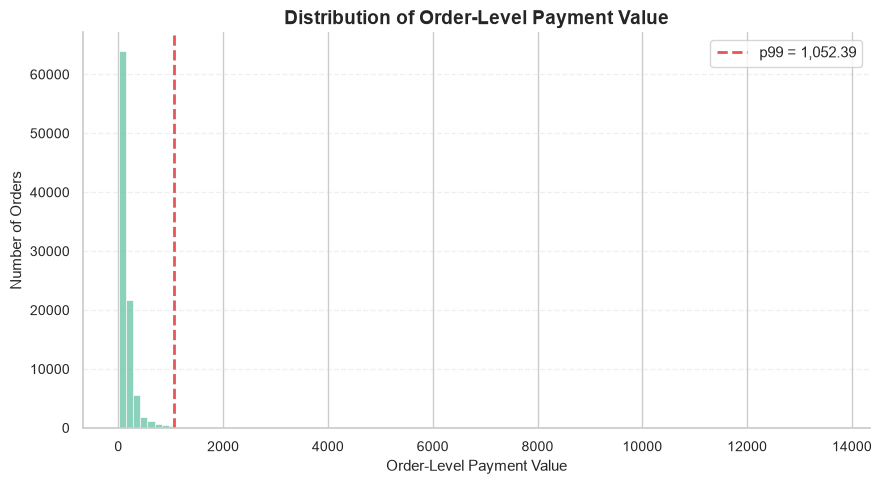

In [38]:
plt.figure(figsize=(9, 5))

ax = sns.histplot(
    data=order_level_clean,
    x="payment_value",
    bins=100,
    color="#66C2A5"
)

plt.axvline(
    order_level_clean["payment_value"].quantile(0.99),
    color="#E45756",
    linestyle="--",
    linewidth=2,
    label=f"p99 = {order_level_clean['payment_value'].quantile(0.99):,.2f}"
)

plt.title("Distribution of Order-Level Payment Value")
plt.xlabel("Order-Level Payment Value")
plt.ylabel("Number of Orders")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

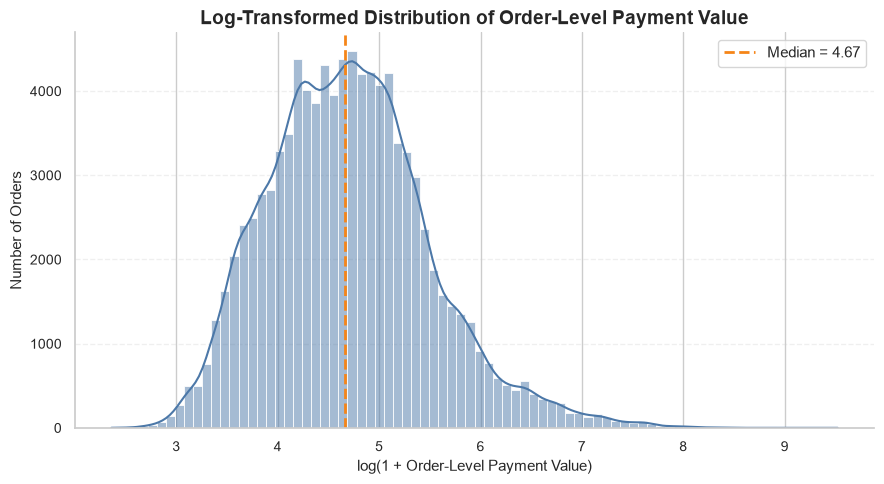

In [39]:
plt.figure(figsize=(9, 5))

order_level_clean["payment_value_log"] = np.log1p(order_level_clean["payment_value"])

ax = sns.histplot(
    data=order_level_clean,
    x="payment_value_log",
    bins=80,
    kde=True,
    color="#4C78A8"
)

plt.axvline(
    order_level_clean["payment_value_log"].median(),
    color="#F58518",
    linestyle="--",
    linewidth=2,
    label=f"Median = {order_level_clean['payment_value_log'].median():.2f}"
)

plt.title("Log-Transformed Distribution of Order-Level Payment Value")
plt.xlabel("log(1 + Order-Level Payment Value)")
plt.ylabel("Number of Orders")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

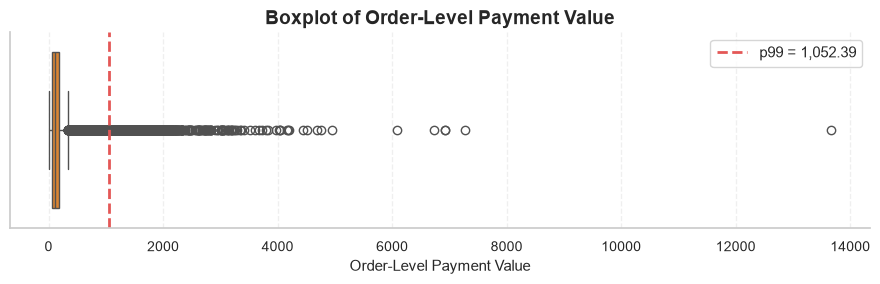

In [40]:
plt.figure(figsize=(9, 3))

ax = sns.boxplot(
    data=order_level_clean,
    x="payment_value",
    color="#F58518"
)

plt.axvline(
    order_level_clean["payment_value"].quantile(0.99),
    color="#E45756",
    linestyle="--",
    linewidth=2,
    label=f"p99 = {order_level_clean['payment_value'].quantile(0.99):,.2f}"
)

plt.title("Boxplot of Order-Level Payment Value")
plt.xlabel("Order-Level Payment Value")
plt.legend()
plt.grid(axis="x", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

The raw order-value distribution is strongly right-skewed. Most orders are concentrated below the upper percentiles, while a small number of transactions reach values above R$10,000. The boxplot consequently identifies many statistical outliers.

The log-transformed view is consistent with a continuous long right tail and does not provide evidence that the extreme observations are recording errors. Removing them would eliminate some of the marketplace’s highest-value transactions and underestimate both historical revenue and potential future value.

The original payment value is therefore retained for accounting and revenue totals. Capped and log-transformed versions are created separately for visualisation and modelling, where extreme scale differences could otherwise dominate the results.



### **Log Transformation**

In [41]:
order_level_clean["payment_value_log"] = np.log1p(
    order_level_clean["payment_value"]
)

### **Calibration and Holdout Period Definition**

A time-based split is required because CLTV is a forecasting problem. Customer behaviour must first be observed during a calibration period, while a later holdout period is reserved to measure the revenue that those customers actually generate in the future.

Before defining the split, the available purchase range and monthly transaction volume are inspected to ensure that the final observation window contains enough activity for a meaningful backtest.

In [42]:
# Check the available purchase date range in the clean order-level dataset

date_range_check = pd.DataFrame({
    "metric": [
        "minimum purchase date",
        "maximum purchase date",
        "number of clean delivered orders",
        "number of unique customers"
    ],
    "value": [
        order_level_clean["order_purchase_timestamp"].min(),
        order_level_clean["order_purchase_timestamp"].max(),
        len(order_level_clean),
        order_level_clean["customer_unique_id"].nunique()
    ]
})

date_range_check

,metric,value
0,minimum purchase date,2016-10-03 09:44:50
1,maximum purchase date,2018-08-29 15:00:37
2,number of clean delivered orders,96477
3,number of unique customers,93357


The clean transactional dataset contains 96,477 delivered orders associated with 93,357 distinct customers. Purchases range from 3 October 2016 to 29 August 2018, providing almost two years of customer history.

The first months contain relatively limited activity, reflecting the early and less mature portion of the marketplace history. The most recent months instead show a substantially larger and more stable transaction volume, making them more suitable for constructing the holdout period.

### **Monthly Order Volume**

In [43]:
# Monthly order volume to understand whether the last months are complete enough for holdout definition

monthly_orders = (
    order_level_clean
    .assign(order_month=order_level_clean["order_purchase_timestamp"].dt.to_period("M").astype(str))
    .groupby("order_month")
    .agg(
        n_orders=("order_id", "nunique"),
        revenue=("payment_value", "sum"),
        n_customers=("customer_unique_id", "nunique")
    )
    .reset_index()
)

monthly_orders.tail(12)

,order_month,n_orders,revenue,n_customers
10,2017-09,4150,701169.99,4083
11,2017-10,4478,751140.27,4417
12,2017-11,7289,1153528.05,7183
13,2017-12,5513,843199.17,5450
14,2018-01,7069,1078606.86,6974
15,2018-02,6555,966510.88,6400
16,2018-03,7003,1120678.00,6914
17,2018-04,6798,1132933.95,6744
18,2018-05,6749,1128836.69,6693
19,2018-06,6099,1012090.68,6061


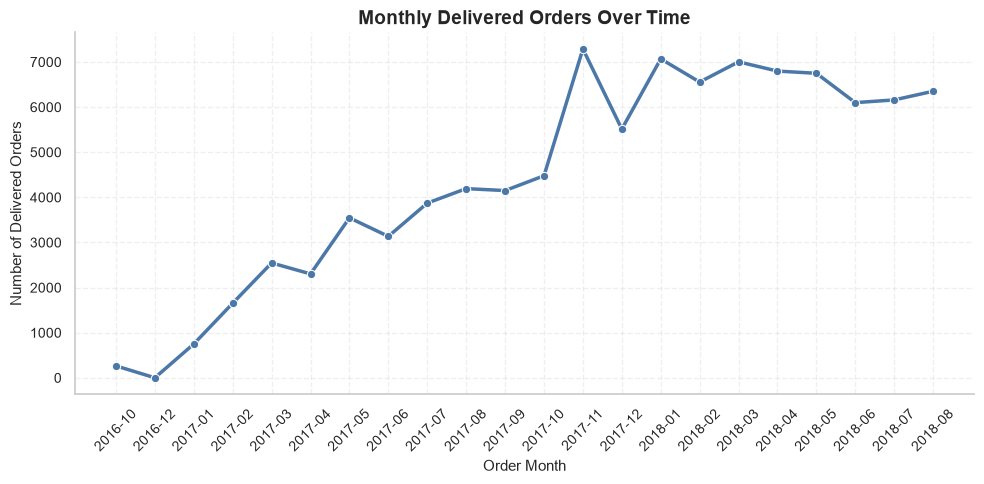

In [44]:
plt.figure(figsize=(10, 5))

ax = sns.lineplot(
    data=monthly_orders,
    x="order_month",
    y="n_orders",
    marker="o",
    linewidth=2.5,
    color="#4C78A8"
)

plt.title("Monthly Delivered Orders Over Time")
plt.xlabel("Order Month")
plt.ylabel("Number of Delivered Orders")
plt.xticks(rotation=45)
plt.grid(axis="both", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

Monthly delivered orders increase progressively during 2017 and then stabilize at approximately 6,000–7,000 orders per month during 2018. The final three months therefore contain a sufficiently large and relatively stable volume of completed transactions for holdout evaluation.

The earliest months are not interpreted as normal seasonal behaviour because they contain a much smaller and less mature transaction base. The holdout is deliberately selected from the most recent part of the timeline, where marketplace activity is more representative of the operating scale reached by Olist.

### **Calibration and Holdout Definition**

In [45]:
# Define an exact 90-day holdout ending on the last available purchase date
prediction_horizon_days = 90

holdout_end = (
    order_level_clean["order_purchase_timestamp"]
    .max()
    .normalize()
)

holdout_start = (
    holdout_end
    - pd.Timedelta(days=prediction_horizon_days - 1)
)

calibration_end = holdout_start - pd.Timedelta(seconds=1)

print("Maximum purchase timestamp:",
      order_level_clean["order_purchase_timestamp"].max())
print("Holdout start:", holdout_start)
print("Holdout end:", holdout_end)
print("Calibration end:", calibration_end)

Maximum purchase timestamp: 2018-08-29 15:00:37
Holdout start: 2018-06-01 00:00:00
Holdout end: 2018-08-29 00:00:00
Calibration end: 2018-05-31 23:59:59


In [46]:
calibration_orders = order_level_clean[
    order_level_clean["order_purchase_timestamp"] < holdout_start
].copy()

holdout_orders = order_level_clean[
    order_level_clean["order_purchase_timestamp"] >= holdout_start
].copy()

In [47]:
assert len(calibration_orders) + len(holdout_orders) == len(order_level_clean)

assert (
    calibration_orders["order_purchase_timestamp"].max()
    < holdout_orders["order_purchase_timestamp"].min()
)

In [48]:
split_check = pd.DataFrame({
    "period": ["Calibration", "Holdout"],
    "start_date": [
        calibration_orders["order_purchase_timestamp"].min(),
        holdout_orders["order_purchase_timestamp"].min()
    ],
    "end_date": [
        calibration_orders["order_purchase_timestamp"].max(),
        holdout_orders["order_purchase_timestamp"].max()
    ],
    "n_orders": [
        calibration_orders["order_id"].nunique(),
        holdout_orders["order_id"].nunique()
    ],
    "n_customers": [
        calibration_orders["customer_unique_id"].nunique(),
        holdout_orders["customer_unique_id"].nunique()
    ],
    "revenue": [
        calibration_orders["payment_value"].sum(),
        holdout_orders["payment_value"].sum()
    ]
})

split_check

,period,start_date,end_date,n_orders,n_customers,revenue
0,Calibration,2016-10-03 09:44:50,2018-05-31 23:51:24,77868,75386,12397052.95
1,Holdout,2018-06-01 00:39:55,2018-08-29 15:00:37,18609,18390,3025408.82


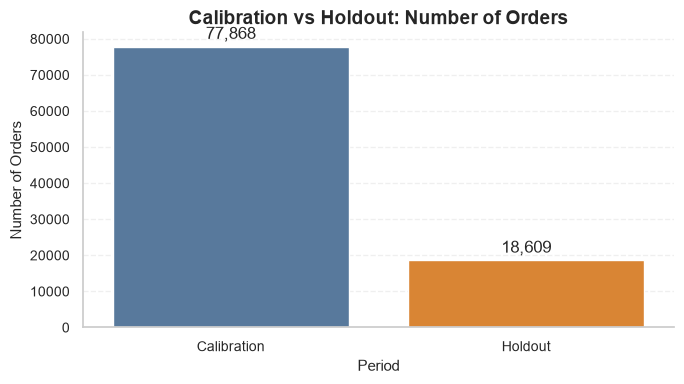

In [49]:
plt.figure(figsize=(7, 4))

ax = sns.barplot(
    data=split_check,
    x="period",
    y="n_orders",
    hue="period",
    palette=["#4C78A8", "#F58518"],
    legend=False
)

add_bar_labels(ax, fmt="{:,.0f}")

plt.title("Calibration vs Holdout: Number of Orders")
plt.xlabel("Period")
plt.ylabel("Number of Orders")
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

The temporal split assigns all purchases before 1 June 2018 to calibration and reserves the period from 1 June to 29 August 2018 for the 90-day holdout evaluation.

The calibration period contains 77,868 orders from 75,386 customers and approximately R$12.40 million in realized revenue. The holdout contains 18,609 orders from 18,390 customers and approximately R$3.03 million in revenue. No random split is used, because randomly mixing earlier and later transactions would introduce temporal leakage and would not reproduce a real forecasting scenario.

### **Calibration-Based Monetary Capping**

In [50]:
# Learn the p99 threshold only from the calibration period
payment_p99 = calibration_orders["payment_value"].quantile(0.99)

# Apply the calibration-derived threshold to calibration transactions
calibration_orders["payment_value_capped"] = (
    calibration_orders["payment_value"]
    .clip(upper=payment_p99)
)

# Apply the same threshold to holdout transactions for consistency
holdout_orders["payment_value_capped"] = (
    holdout_orders["payment_value"]
    .clip(upper=payment_p99)
)

# Create the log-transformed versions within each period
calibration_orders["payment_value_log"] = np.log1p(
    calibration_orders["payment_value"]
)

holdout_orders["payment_value_log"] = np.log1p(
    holdout_orders["payment_value"]
)

In [51]:
capping_check = pd.DataFrame({
    "metric": [
        "calibration p99 threshold",
        "calibration orders above p99",
        "share of calibration orders above p99 (%)",
        "original max calibration payment value",
        "capped max calibration payment value"
    ],
    "value": [
        payment_p99,
        (calibration_orders["payment_value"] > payment_p99).sum(),
        (calibration_orders["payment_value"] > payment_p99).mean() * 100,
        calibration_orders["payment_value"].max(),
        calibration_orders["payment_value_capped"].max()
    ]
})

capping_check["value"] = capping_check["value"].round(2)
capping_check

,metric,value
0,calibration p99 threshold,1048.66
1,calibration orders above p99,779.00
2,share of calibration orders above p99 (%),1.00
3,original max calibration payment value,13664.08
4,capped max calibration payment value,1048.66


The p99 threshold is estimated exclusively from the calibration period and is then applied unchanged to both calibration and holdout transactions. This prevents information from the future holdout period from influencing preprocessing decisions.

The resulting threshold is R$1,048.66 and caps exactly 1% of calibration orders. The original payment value remains available for realized-revenue totals and target construction, while the capped and log-transformed variables provide more robust inputs for modelling.

## **Existing-Customer Forecasting Population**

The CLTV forecasting population is restricted to customers already observed during the calibration period. Holdout transactions generated by customers who first appear after the calibration cut-off represent new customer acquisition rather than future value generated by the existing customer base.

The following analysis therefore separates existing-customer holdout activity from revenue generated by newly acquired customers.


### **Customer Overlap Between Calibration and Holdout**

In [52]:
# Identify customers appearing in calibration and holdout
calib_customers = set(
    calibration_orders["customer_unique_id"]
)

holdout_customers = set(
    holdout_orders["customer_unique_id"]
)

overlap_customers = (
    calib_customers
    & holdout_customers
)

In [53]:
overlap_check = pd.DataFrame({
    "metric": [
        "unique customers in calibration",
        "unique customers in holdout",
        "customers present in both periods",
        "share of calibration customers purchasing in holdout (%)"
    ],
    "value": [
        len(calib_customers),
        len(holdout_customers),
        len(overlap_customers),
        len(overlap_customers) / len(calib_customers) * 100
    ]
})

overlap_check["value"] = overlap_check["value"].round(2)
overlap_check

,metric,value
0,unique customers in calibration,75386.00
1,unique customers in holdout,18390.00
2,customers present in both periods,419.00
3,share of calibration customers purchasing in h...,0.56


Only 419 of the 75,386 customers observed during calibration make another purchase during the 90-day holdout period. This corresponds to a short-term repurchase rate of 0.56%.

The extremely limited overlap reveals that Olist's customer base is dominated by one-time purchasing behaviour. This characteristic makes future revenue highly zero-inflated: for the overwhelming majority of existing customers, the observed holdout revenue is zero. It also means that model evaluation must consider both exact revenue error and the ability to rank the small set of customers who generate future value.

## **Customer Level Holdout Target**

In [54]:
# Define the modeling customer base as customers observed in the calibration period

calibration_customer_base = (
    calibration_orders[["customer_unique_id"]]
    .drop_duplicates()
    .copy()
)

calibration_customer_base.head()

,customer_unique_id
0,7c396fd4830fd04220f754e42b4e5bff
3,7c142cf63193a1473d2e66489a9ae977
4,72632f0f9dd73dfee390c9b22eb56dd6
5,80bb27c7c16e8f973207a5086ab329e2
6,932afa1e708222e5821dac9cd5db4cae


In [55]:
# Build customer-level holdout target

holdout_target = (
    holdout_orders
    .groupby("customer_unique_id")
    .agg(
        target_revenue_90d=("payment_value", "sum"),
        target_orders_90d=("order_id", "nunique")
    )
    .reset_index()
)

holdout_target["repurchased_in_holdout"] = 1

holdout_target.head()

,customer_unique_id,target_revenue_90d,target_orders_90d,repurchased_in_holdout
0,000e309254ab1fc5ba99dd469d36bdb4,78.42,1,1
1,000ec5bff359e1c0ad76a81a45cb598f,27.75,1,1
2,000fbf0473c10fc1ab6f8d2d286ce20c,362.38,1,1
3,0015752e079902b12cd00b9b7596276b,74.82,1,1
4,00172711b30d52eea8b313a7f2cced02,122.07,1,1


In [56]:
# Attach the holdout target to the calibration customer base.
# Customers with no holdout purchase receive target revenue = 0.

customer_target = (
    calibration_customer_base
    .merge(
        holdout_target,
        on="customer_unique_id",
        how="left"
    )
)

customer_target["target_revenue_90d"] = customer_target["target_revenue_90d"].fillna(0)
customer_target["target_orders_90d"] = customer_target["target_orders_90d"].fillna(0)
customer_target["repurchased_in_holdout"] = (
    customer_target["repurchased_in_holdout"]
    .fillna(0)
    .astype(int)
)

customer_target.head()

,customer_unique_id,target_revenue_90d,target_orders_90d,repurchased_in_holdout
0,7c396fd4830fd04220f754e42b4e5bff,0.0,0.0,0
1,7c142cf63193a1473d2e66489a9ae977,0.0,0.0,0
2,72632f0f9dd73dfee390c9b22eb56dd6,0.0,0.0,0
3,80bb27c7c16e8f973207a5086ab329e2,0.0,0.0,0
4,932afa1e708222e5821dac9cd5db4cae,0.0,0.0,0


In [57]:
customer_target["target_revenue_90d"] = (
    customer_target["target_revenue_90d"]
    .fillna(0)
)

customer_target["target_orders_90d"] = (
    customer_target["target_orders_90d"]
    .fillna(0)
    .astype(int)
)

customer_target["repurchased_in_holdout"] = (
    customer_target["repurchased_in_holdout"]
    .fillna(0)
    .astype(int)
)

In [58]:
target_check = pd.DataFrame({
    "metric": [
        "customers in calibration base",
        "customers with holdout purchase",
        "customers without holdout purchase",
        "holdout repurchase rate (%)",
        "total target revenue from calibration customers"
    ],
    "value": [
        len(customer_target),
        customer_target["repurchased_in_holdout"].sum(),
        (customer_target["repurchased_in_holdout"] == 0).sum(),
        customer_target["repurchased_in_holdout"].mean() * 100,
        customer_target["target_revenue_90d"].sum()
    ]
})

target_check["value"] = target_check["value"].round(2)

target_check

,metric,value
0,customers in calibration base,75386.00
1,customers with holdout purchase,419.00
2,customers without holdout purchase,74967.00
3,holdout repurchase rate (%),0.56
4,total target revenue from calibration customers,66978.67


The prediction population is restricted to customers already observed during calibration, because the objective is to estimate the future value of the current customer base rather than forecast the acquisition of new customers.

For each calibration customer, `target_revenue_90d` measures the actual revenue generated during the holdout period, while `target_orders_90d` records the corresponding number of future orders. Customers who do not appear in the holdout receive zero revenue, zero orders and a repurchase indicator equal to zero.

Only 419 customers generate holdout revenue, compared with 74,967 who do not repurchase. The target is therefore highly zero-inflated and imbalanced, which explains why an apparently small average prediction error may still conceal poor identification of the few commercially relevant future buyers.

In [59]:
# Create a small table for the holdout purchase visualization

target_counts = pd.DataFrame({
    "group": [
        "Repurchased in holdout",
        "Did not repurchase"
    ],
    "n_customers": [
        customer_target["repurchased_in_holdout"].sum(),
        (customer_target["repurchased_in_holdout"] == 0).sum()
    ]
})

target_counts

,group,n_customers
0,Repurchased in holdout,419
1,Did not repurchase,74967


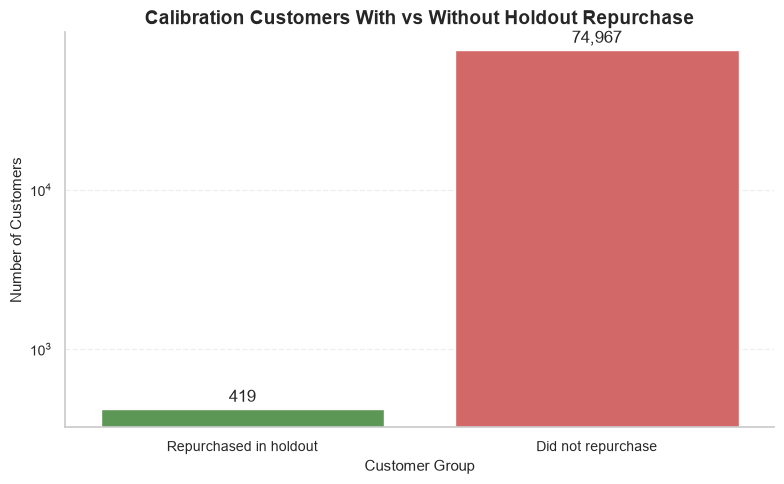

In [60]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=target_counts,
    x="group",
    y="n_customers",
    hue="group",
    palette=["#54A24B", "#E45756"],
    legend=False
)

add_bar_labels(ax)

ax.set_yscale("log")

plt.title("Calibration Customers With vs Without Holdout Repurchase")
plt.xlabel("Customer Group")
plt.ylabel("Number of Customers")
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

In [61]:
# Compare total holdout revenue with the portion generated by customers already observed in calibration

total_holdout_revenue = holdout_orders["payment_value"].sum()
known_customer_holdout_revenue = customer_target["target_revenue_90d"].sum()
new_customer_holdout_revenue = total_holdout_revenue - known_customer_holdout_revenue

holdout_revenue_source_check = pd.DataFrame({
    "metric": [
        "total holdout revenue",
        "holdout revenue from calibration customers",
        "holdout revenue from new-to-calibration customers",
        "share from calibration customers (%)",
        "share from new-to-calibration customers (%)"
    ],
    "value": [
        total_holdout_revenue,
        known_customer_holdout_revenue,
        new_customer_holdout_revenue,
        known_customer_holdout_revenue / total_holdout_revenue * 100,
        new_customer_holdout_revenue / total_holdout_revenue * 100
    ]
})

holdout_revenue_source_check["value"] = holdout_revenue_source_check["value"].round(2)

holdout_revenue_source_check

,metric,value
0,total holdout revenue,3025408.82
1,holdout revenue from calibration customers,66978.67
2,holdout revenue from new-to-calibration customers,2958430.15
3,share from calibration customers (%),2.21
4,share from new-to-calibration customers (%),97.79


The distinction between existing and newly acquired customers reveals a central business characteristic of the marketplace. The 75,386 customers already observed during calibration generate only R$66,978.67 during the holdout, corresponding to 2.21% of total holdout revenue.

By contrast, customers who were not present during calibration generate R$2.96 million, or 97.79% of holdout revenue. Olist's short-term growth is therefore driven primarily by continuous customer acquisition rather than by revenue retained from the existing customer base.

This does not make CLTV irrelevant. Instead, it changes its strategic purpose: the model should identify the small minority of current customers with meaningful repurchase potential, while the wider marketing plan must also address the structural difficulty of converting first-time buyers into repeat customers.

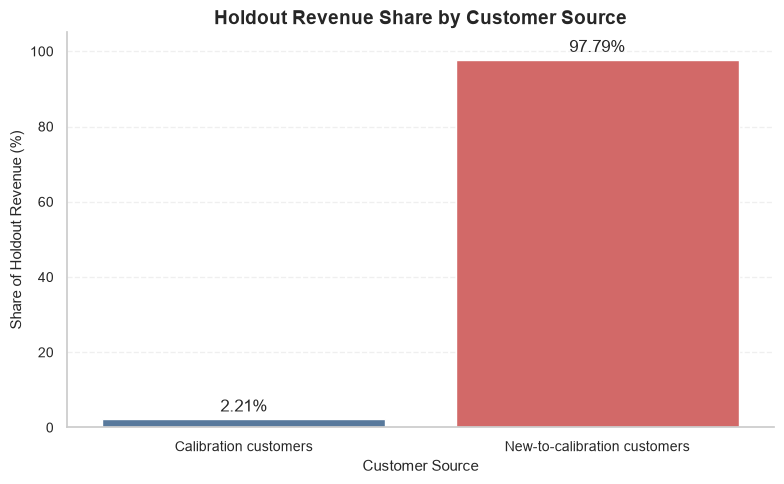

In [62]:
revenue_source_share_plot = pd.DataFrame({
    "source": [
        "Calibration customers",
        "New-to-calibration customers"
    ],
    "share_pct": [
        known_customer_holdout_revenue / total_holdout_revenue * 100,
        new_customer_holdout_revenue / total_holdout_revenue * 100
    ]
})

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=revenue_source_share_plot,
    x="source",
    y="share_pct",
    hue="source",
    palette=["#4C78A8", "#E45756"],
    legend=False
)

add_bar_labels(ax, fmt="{:.2f}%")

plt.title("Holdout Revenue Share by Customer Source")
plt.xlabel("Customer Source")
plt.ylabel("Share of Holdout Revenue (%)")
plt.ylim(0, 105)
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

## **Exploratory Data Analysis**
The exploratory analysis now focuses exclusively on information available during calibration. This prevents future holdout behaviour from influencing the customer profiles used for prediction.

The analysis examines purchase repetition, recency, customer tenure and monetary value. These dimensions form the behavioural foundation for the subsequent RFM table, probabilistic BTYD models and machine learning features.

### **Customer Purchase Structure**

In [63]:
# Create customer-level behavioral table from the calibration period

customer_calibration = (
    calibration_orders
    .groupby("customer_unique_id")
    .agg(
        n_orders=("order_id", "nunique"),
        first_purchase=("order_purchase_timestamp", "min"),
        last_purchase=("order_purchase_timestamp", "max"),
        total_revenue=("payment_value", "sum"),
        total_revenue_capped_by_order=("payment_value_capped", "sum"),
        avg_order_value=("payment_value", "mean"),
        avg_order_value_capped=("payment_value_capped", "mean"),
        total_items=("n_items", "sum"),
        sum_unique_products_per_order=("n_unique_products", "sum"),
        n_unique_main_categories=("main_product_category", "nunique"),
        avg_review_score=("review_score", "mean"),
        customer_state=(
            "customer_state",
            lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan
        )
    )
    .reset_index()
)

customer_calibration.head()

,customer_unique_id,n_orders,first_purchase,last_purchase,total_revenue,total_revenue_capped_by_order,avg_order_value,avg_order_value_capped,total_items,sum_unique_products_per_order,n_unique_main_categories,avg_review_score,customer_state
0,0000366f3b9a7992bf8c76cfdf3221e2,1,2018-05-10 10:56:27,2018-05-10 10:56:27,141.90,141.90,141.90,141.90,1,1,1,5.0,SP
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,2018-05-07 11:11:27,2018-05-07 11:11:27,27.19,27.19,27.19,27.19,1,1,1,4.0,SP
2,0000f46a3911fa3c0805444483337064,1,2017-03-10 21:05:03,2017-03-10 21:05:03,86.22,86.22,86.22,86.22,1,1,1,3.0,SC
3,0000f6ccb0745a6a4b88665a16c9f078,1,2017-10-12 20:29:41,2017-10-12 20:29:41,43.62,43.62,43.62,43.62,1,1,1,4.0,PA
4,0004aac84e0df4da2b147fca70cf8255,1,2017-11-14 19:45:42,2017-11-14 19:45:42,196.89,196.89,196.89,196.89,1,1,1,5.0,SP


In [64]:
# Classify customers as one-shot or repeat customers

customer_calibration["customer_type"] = np.where(
    customer_calibration["n_orders"] == 1,
    "One-shot customer",
    "Repeat customer"
)

customer_type_summary = (
    customer_calibration["customer_type"]
    .value_counts()
    .reset_index()
)

customer_type_summary.columns = ["customer_type", "n_customers"]
customer_type_summary["percentage"] = (
    customer_type_summary["n_customers"] / len(customer_calibration) * 100
).round(2)

customer_type_summary

,customer_type,n_customers,percentage
0,One-shot customer,73156,97.04
1,Repeat customer,2230,2.96


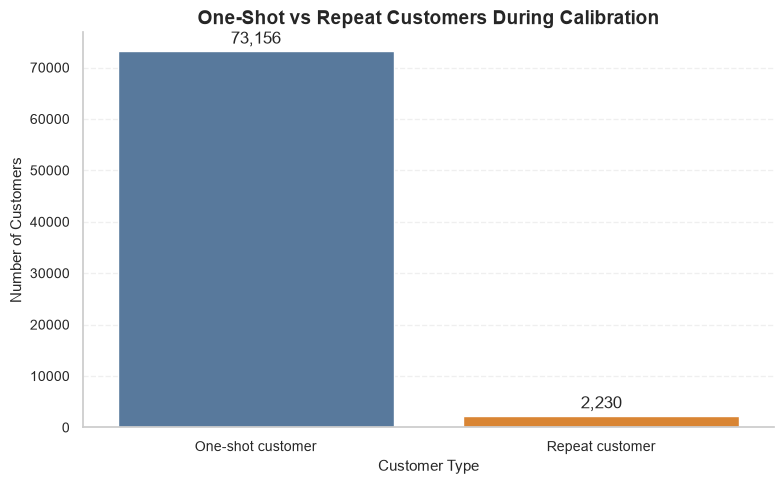

In [65]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=customer_type_summary,
    x="customer_type",
    y="n_customers",
    hue="customer_type",
    palette=["#4C78A8", "#F58518"],
    legend=False
)

add_bar_labels(ax)

plt.title("One-Shot vs Repeat Customers During Calibration")
plt.xlabel("Customer Type")
plt.ylabel("Number of Customers")
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

The calibration customer base is overwhelmingly composed of one-shot buyers. A total of 73,156 customers, equal to 97.04% of the base, complete only one purchase, while just 2,230 customers, or 2.96%, make at least one repeat purchase.

This structure has direct implications for both modelling and marketing. Probabilistic models have limited repeat history from which to estimate individual purchase rates, while the business has a substantial opportunity to improve second-purchase conversion. One-shot and repeat customers should therefore not be interpreted as equally mature relationships.

### **Purchase Frequency Distribution**

In [66]:
# Distribution of number of orders per customer in the calibration period

purchase_frequency_distribution = (
    customer_calibration["n_orders"]
    .value_counts()
    .sort_index()
    .reset_index()
)

purchase_frequency_distribution.columns = ["n_orders", "n_customers"]
purchase_frequency_distribution["percentage"] = (
    purchase_frequency_distribution["n_customers"] / len(customer_calibration) * 100
).round(2)

purchase_frequency_distribution

,n_orders,n_customers,percentage
0,1,73156,97.04
1,2,2044,2.71
2,3,153,0.20
3,4,17,0.02
4,5,7,0.01
5,6,6,0.01
6,7,1,0.00
7,9,1,0.00
8,10,1,0.00


In [67]:
# Create a grouped version for visualization

customer_calibration["purchase_frequency_group"] = np.where(
    customer_calibration["n_orders"] >= 5,
    "5+",
    customer_calibration["n_orders"].astype(str)
)

frequency_group_summary = (
    customer_calibration["purchase_frequency_group"]
    .value_counts()
    .reset_index()
)

frequency_group_summary.columns = ["purchase_frequency_group", "n_customers"]

# Keep the groups in the correct order
frequency_order = ["1", "2", "3", "4", "5+"]
frequency_group_summary["purchase_frequency_group"] = pd.Categorical(
    frequency_group_summary["purchase_frequency_group"],
    categories=frequency_order,
    ordered=True
)

frequency_group_summary = frequency_group_summary.sort_values("purchase_frequency_group")

frequency_group_summary

,purchase_frequency_group,n_customers
0,1,73156
1,2,2044
2,3,153
3,4,17
4,5+,16


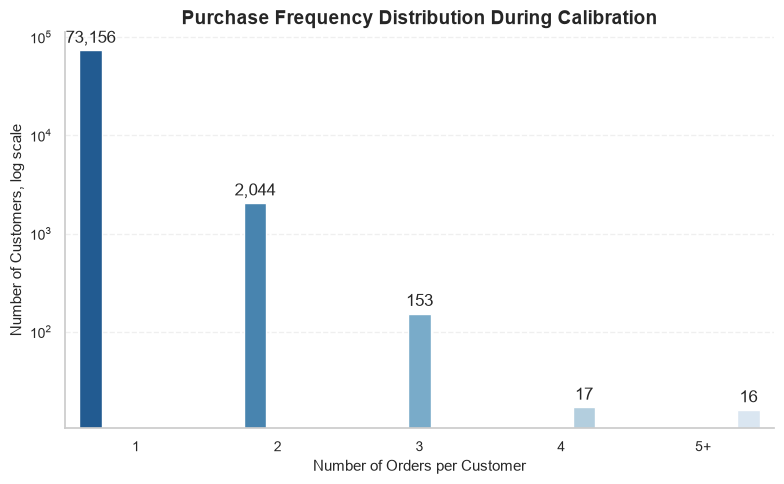

In [68]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=frequency_group_summary,
    x="purchase_frequency_group",
    y="n_customers",
    hue="purchase_frequency_group",
    palette="Blues_r",
    legend=False
)

ax.set_yscale("log")
add_bar_labels(ax)

plt.title("Purchase Frequency Distribution During Calibration")
plt.xlabel("Number of Orders per Customer")
plt.ylabel("Number of Customers, log scale")
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

The detailed frequency distribution confirms that purchase repetition falls sharply after the first order. While 2,044 customers place exactly two orders, only 153 place three orders and just 33 customers place four or more.

The log scale makes this long tail visible without hiding the dominant one-order customer group. From a modelling perspective, the scarcity of customers with several repeat transactions limits the individual behavioural history available to BG/NBD and Gamma-Gamma. From a marketing perspective, the largest opportunity lies not in increasing an already mature purchasing habit, but in converting the first transaction into a second one.

## **Recency and Monetary Behaviour**

Recency measures the number of days elapsed between the customer's most recent calibration purchase and the end of the calibration period. A lower value indicates more recent interaction with Olist.

Tenure measures the number of days between the customer's first observed purchase and the end of calibration. For one-shot customers, recency and tenure are equal because the first and last purchase coincide. For repeat customers, the difference between the two variables captures the active span of the observed relationship.

In [69]:
# Create recency and tenure variables at customer level

customer_calibration["recency_days"] = (
    calibration_end - customer_calibration["last_purchase"]
).dt.days

customer_calibration["tenure_days"] = (
    calibration_end - customer_calibration["first_purchase"]
).dt.days

customer_calibration[[
    "customer_unique_id",
    "n_orders",
    "first_purchase",
    "last_purchase",
    "recency_days",
    "tenure_days",
    "total_revenue",
    "avg_order_value"
]].head()

,customer_unique_id,n_orders,first_purchase,last_purchase,recency_days,tenure_days,total_revenue,avg_order_value
0,0000366f3b9a7992bf8c76cfdf3221e2,1,2018-05-10 10:56:27,2018-05-10 10:56:27,21,21,141.90,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,2018-05-07 11:11:27,2018-05-07 11:11:27,24,24,27.19,27.19
2,0000f46a3911fa3c0805444483337064,1,2017-03-10 21:05:03,2017-03-10 21:05:03,447,447,86.22,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,1,2017-10-12 20:29:41,2017-10-12 20:29:41,231,231,43.62,43.62
4,0004aac84e0df4da2b147fca70cf8255,1,2017-11-14 19:45:42,2017-11-14 19:45:42,198,198,196.89,196.89


In [70]:
recency_summary = customer_calibration["recency_days"].describe().round(2)
recency_summary

count    75386.00
mean       194.68
std        132.04
min          0.00
25%         86.00
50%        177.00
75%        291.00
max        605.00
Name: recency_days, dtype: float64

In [71]:
recency_check = pd.DataFrame({
    "metric": [
        "customers with negative recency",
        "customers with zero recency",
        "maximum recency"
    ],
    "value": [
        (customer_calibration["recency_days"] < 0).sum(),
        (customer_calibration["recency_days"] == 0).sum(),
        customer_calibration["recency_days"].max()
    ]
})

recency_check

,metric,value
0,customers with negative recency,0
1,customers with zero recency,131
2,maximum recency,605


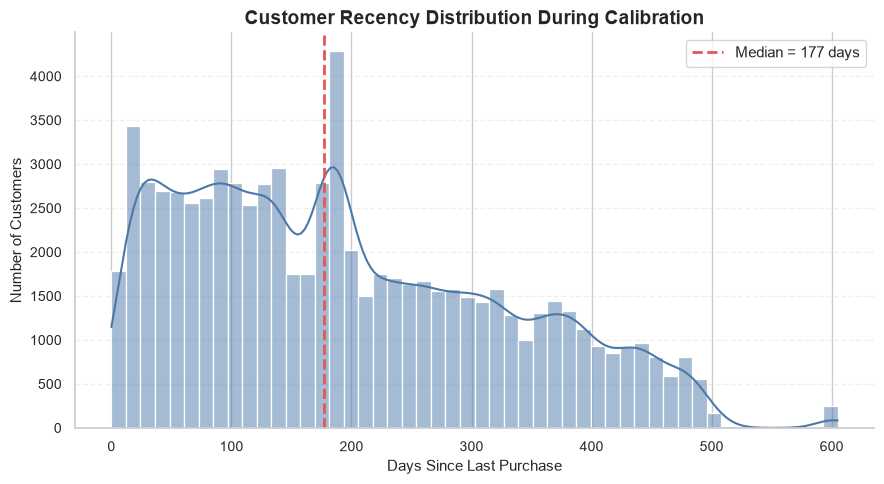

In [72]:
plt.figure(figsize=(9, 5))

ax = sns.histplot(
    data=customer_calibration,
    x="recency_days",
    bins=50,
    kde=True,
    color="#4C78A8"
)

plt.axvline(
    customer_calibration["recency_days"].median(),
    color="#E45756",
    linestyle="--",
    linewidth=2,
    label=f"Median = {customer_calibration['recency_days'].median():.0f} days"
)

plt.title("Customer Recency Distribution During Calibration")
plt.xlabel("Days Since Last Purchase")
plt.ylabel("Number of Customers")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

Customer recency ranges from zero to 605 days, with a median of 177 days. The distribution is broad because customers entered the marketplace at different points in time and most did not place another order after their initial purchase.

The 131 customers with zero recency purchased within the final 24 hours of the calibration period and therefore represent the most recently active group. No negative values are observed, confirming that the temporal feature construction is consistent with the calibration boundary.

The high median recency, combined with the very low holdout repurchase rate, suggests that a large share of the historical customer base appeared behaviourally dormant before the holdout period. However, permanent inactivity cannot be directly observed in this non-contractual setting.

### **Customer Level Monetary Distribution**

In [73]:
# Compute a separate customer-level p99 cap
customer_revenue_p99 = (
    customer_calibration["total_revenue"].quantile(0.99)
)

customer_calibration["total_revenue_capped_by_customer"] = (
    customer_calibration["total_revenue"]
    .clip(upper=customer_revenue_p99)
)

# Log-transformed versions for visualization and modelling
customer_calibration["total_revenue_log"] = np.log1p(
    customer_calibration["total_revenue"]
)

customer_calibration["total_revenue_capped_by_order_log"] = np.log1p(
    customer_calibration["total_revenue_capped_by_order"]
)

customer_calibration["total_revenue_capped_by_customer_log"] = np.log1p(
    customer_calibration["total_revenue_capped_by_customer"]
)
customer_revenue_p99

np.float64(1085.4169999999954)

In [74]:
monetary_summary = customer_calibration[[
    "total_revenue",
    "total_revenue_capped_by_order",
    "total_revenue_capped_by_customer",
    "avg_order_value"
]].describe().round(2)

monetary_summary

,total_revenue,total_revenue_capped_by_order,total_revenue_capped_by_customer,avg_order_value
count,75386.00,75386.00,75386.00,75386.00
mean,164.45,158.40,158.53,159.67
std,223.48,169.93,170.12,216.89
min,10.07,10.07,10.07,10.07
25%,63.01,63.01,63.01,62.27
50%,107.24,107.24,107.24,105.28
75%,181.72,181.72,181.72,175.99
max,13664.08,2400.48,1085.42,13664.08


In [75]:
customer_capping_check = pd.DataFrame({
    "metric": [
        "customer-level p99 threshold",
        "customers above customer-level p99",
        "share of customers above customer-level p99 (%)",
        "original max customer revenue",
        "customer-level capped max revenue"
    ],
    "value": [
        customer_revenue_p99,
        (customer_calibration["total_revenue"] > customer_revenue_p99).sum(),
        (customer_calibration["total_revenue"] > customer_revenue_p99).mean() * 100,
        customer_calibration["total_revenue"].max(),
        customer_calibration["total_revenue_capped_by_customer"].max()
    ]
})

customer_capping_check["value"] = customer_capping_check["value"].round(2)

customer_capping_check

,metric,value
0,customer-level p99 threshold,1085.42
1,customers above customer-level p99,754.00
2,share of customers above customer-level p99 (%),1.00
3,original max customer revenue,13664.08
4,customer-level capped max revenue,1085.42


Customer-level revenue is also strongly right-skewed. The median customer generates R$107.24 during calibration, while the maximum reaches R$13,664.08. The 99th-percentile customer threshold is R$1,085.42, with 754 customers exceeding this value.

The two capping strategies have different meanings. Order-level capping limits the impact of individual extreme transactions before customer revenue is aggregated, while customer-level capping limits the final cumulative revenue of the customer. The original `total_revenue` remains unchanged and is used whenever the analysis requires actual economic contribution.

For machine learning, the log-transformed version offers the most natural primary representation because it compresses the extreme right tail without forcing all high-value customers to the same upper threshold.

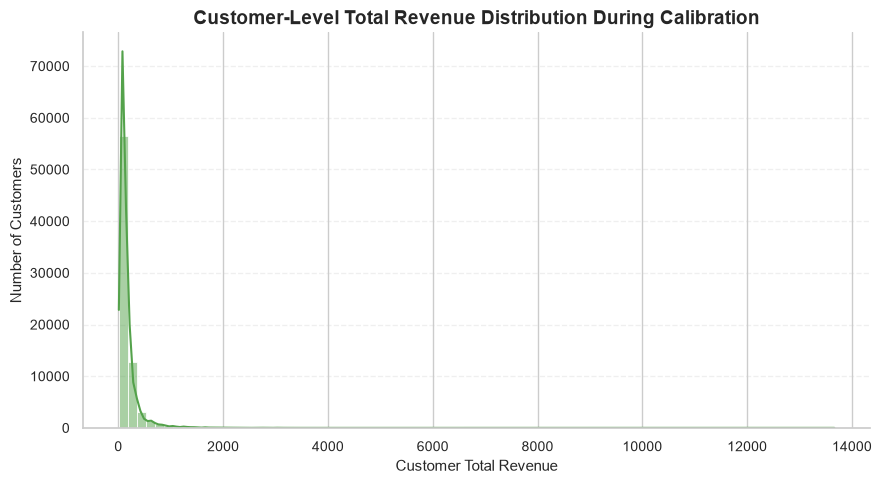

In [76]:
plt.figure(figsize=(9, 5))

ax = sns.histplot(
    data=customer_calibration,
    x="total_revenue",
    bins=80,
    kde=True,
    color="#54A24B"
)

plt.title("Customer-Level Total Revenue Distribution During Calibration")
plt.xlabel("Customer Total Revenue")
plt.ylabel("Number of Customers")
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

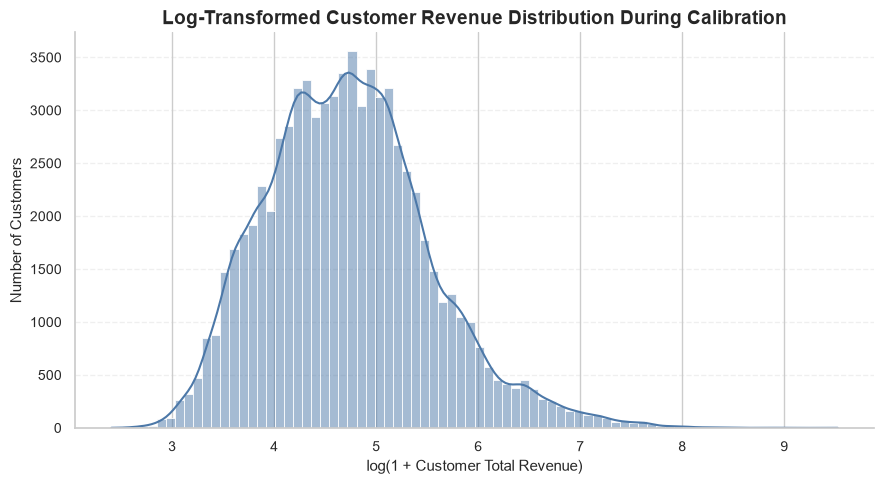

In [77]:
plt.figure(figsize=(9, 5))

ax = sns.histplot(
    data=customer_calibration,
    x="total_revenue_log",
    bins=80,
    kde=True,
    color="#4C78A8"
)

plt.title("Log-Transformed Customer Revenue Distribution During Calibration")
plt.xlabel("log(1 + Customer Total Revenue)")
plt.ylabel("Number of Customers")
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

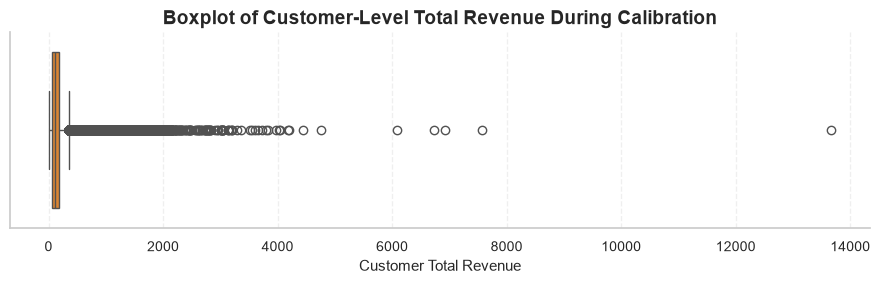

In [78]:
plt.figure(figsize=(9, 3))

ax = sns.boxplot(
    data=customer_calibration,
    x="total_revenue",
    color="#F58518"
)

plt.title("Boxplot of Customer-Level Total Revenue During Calibration")
plt.xlabel("Customer Total Revenue")
plt.grid(axis="x", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

The raw histogram and boxplot show that a small group of customers generates substantially higher revenue than the majority of the base. Given the dominance of one-shot customers, much of the customer-level distribution resembles the order-level distribution, but repeat customers create a longer cumulative spending tail.

The log transformation produces a more balanced distribution while retaining the ordering of customer value. The extreme observations are therefore retained as potentially meaningful high-value customer profiles rather than automatically deleted as errors.

## **Monthly Orders and Revenue**

Monthly aggregation helps distinguish changes in marketplace scale from changes in customer basket value. Orders and revenue measure transaction growth, while average order value indicates whether that growth is driven by larger purchases or simply by a greater number of transactions.

In [79]:
# Monthly order, revenue and average order value trend during calibration

monthly_calibration = (
    calibration_orders
    .assign(order_month=calibration_orders["order_purchase_timestamp"].dt.to_period("M").astype(str))
    .groupby("order_month")
    .agg(
        n_orders=("order_id", "nunique"),
        revenue=("payment_value", "sum"),
        n_customers=("customer_unique_id", "nunique"),
        avg_order_value=("payment_value", "mean")
    )
    .reset_index()
)


monthly_calibration["revenue"] = (
    monthly_calibration["revenue"].round(2)
)

monthly_calibration["avg_order_value"] = (
    monthly_calibration["avg_order_value"].round(2)
)

monthly_calibration

,order_month,n_orders,revenue,n_customers,avg_order_value
0,2016-10,265,46566.71,262,175.72
1,2016-12,1,19.62,1,19.62
2,2017-01,750,127545.67,718,170.06
3,2017-02,1653,271298.65,1630,164.13
4,2017-03,2546,414369.39,2508,162.75
5,2017-04,2303,390952.18,2274,169.76
6,2017-05,3546,567066.73,3479,159.92
7,2017-06,3135,490225.60,3076,156.37
8,2017-07,3872,566403.93,3802,146.28
9,2017-08,4193,646000.61,4114,154.07


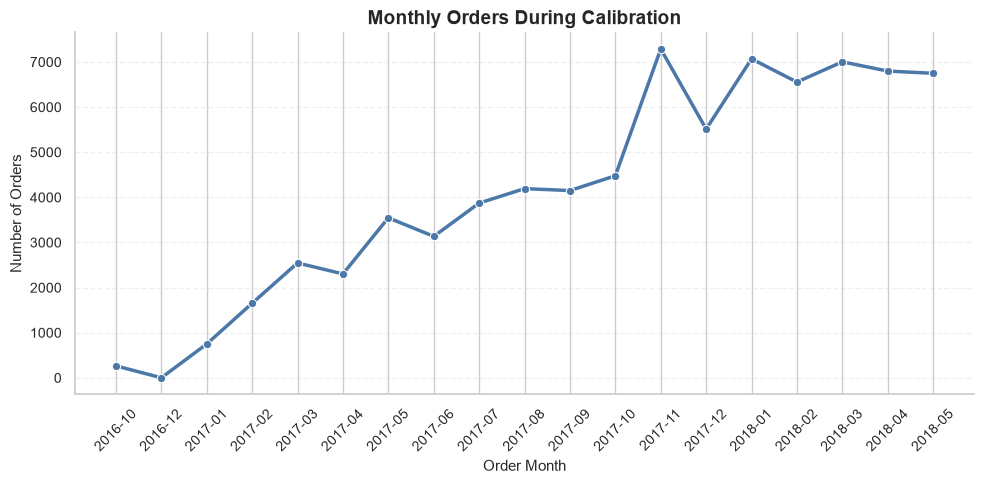

In [80]:
plt.figure(figsize=(10, 5))

ax = sns.lineplot(
    data=monthly_calibration,
    x="order_month",
    y="n_orders",
    marker="o",
    linewidth=2.5,
    color="#4C78A8"
)

plt.title("Monthly Orders During Calibration")
plt.xlabel("Order Month")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

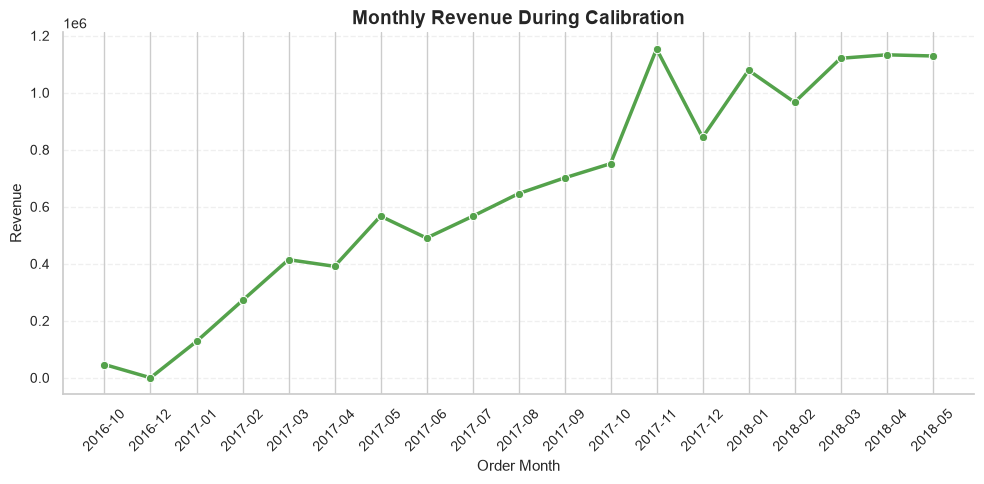

In [81]:
plt.figure(figsize=(10, 5))

ax = sns.lineplot(
    data=monthly_calibration,
    x="order_month",
    y="revenue",
    marker="o",
    linewidth=2.5,
    color="#54A24B"
)

plt.title("Monthly Revenue During Calibration")
plt.xlabel("Order Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

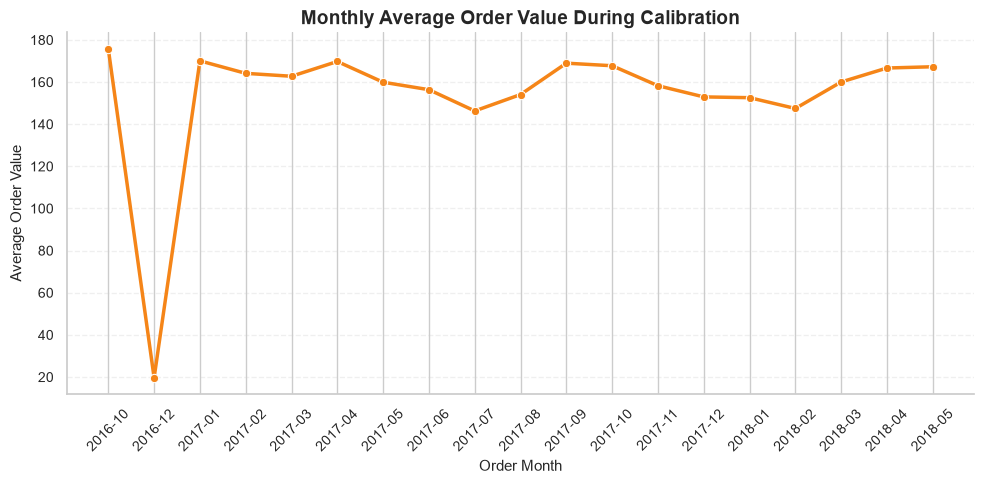

In [82]:
plt.figure(figsize=(10, 5))

ax = sns.lineplot(
    data=monthly_calibration,
    x="order_month",
    y="avg_order_value",
    marker="o",
    linewidth=2.5,
    color="#F58518"
)

plt.title("Monthly Average Order Value During Calibration")
plt.xlabel("Order Month")
plt.ylabel("Average Order Value")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

Monthly orders and revenue follow closely aligned trajectories. Both increase substantially during 2017 and reach a more stable level during the final months of calibration. The pronounced increase in November 2017 is visible in both order volume and revenue, while average order value remains within its usual mature-period range. This suggests that the spike was driven mainly by a greater number of transactions rather than by unusually large baskets, potentially reflecting seasonal or promotional demand.

Average order value generally remains around R$150–R$170 across the more mature months. December 2016 is a clear exception, but it contains only one order and should therefore not be interpreted as representative customer behaviour.

For marketing planning, this pattern reinforces the distinction between acquisition-led growth and customer-level retention. Olist successfully expanded the number of transactions, but the earlier overlap analysis shows that very little future revenue was generated by customers already present in the calibration base.

## **Customer State Analysis**

The geographical analysis examines how calibration-period customers, orders and revenue are distributed across Brazilian states. This view is not intended to assign causal value to location, but to identify the markets in which Olist has the largest customer concentration and the states associated with different order-value profiles.

Order volume, customer count and total revenue describe market scale, while average order value provides a complementary measure of the economic intensity of the transactions generated in each state.

In [83]:
# Customer state analysis during calibration

state_summary = (
    calibration_orders
    .groupby("customer_state")
    .agg(
        n_orders=("order_id", "nunique"),
        n_customers=("customer_unique_id", "nunique"),
        revenue=("payment_value", "sum"),
        avg_order_value=("payment_value", "mean")
    )
    .reset_index()
)

state_summary["orders_share_pct"] = (
    state_summary["n_orders"]
    / state_summary["n_orders"].sum()
    * 100
).round(2)

state_summary["revenue_share_pct"] = (
    state_summary["revenue"]
    / state_summary["revenue"].sum()
    * 100
).round(2)

state_summary["revenue"] = state_summary["revenue"].round(2)
state_summary["avg_order_value"] = (
    state_summary["avg_order_value"].round(2)
)

state_summary = state_summary.sort_values(
    "n_orders",
    ascending=False
)

state_summary.head(10)

,customer_state,n_orders,n_customers,revenue,avg_order_value,orders_share_pct,revenue_share_pct
25,SP,31883,30832,4562525.02,143.10,40.94,36.80
18,RJ,10224,9875,1708497.88,167.11,13.13,13.78
10,MG,9296,9012,1471572.60,158.30,11.94,11.87
22,RS,4440,4295,708611.37,159.60,5.70,5.72
17,PR,3976,3854,631404.96,158.80,5.11,5.09
23,SC,2945,2870,481111.25,163.37,3.78,3.88
4,BA,2654,2578,473301.65,178.34,3.41,3.82
7,ES,1647,1589,244148.63,148.24,2.12,1.97
6,DF,1625,1577,272600.21,167.75,2.09,2.20
8,GO,1623,1578,271328.82,167.18,2.08,2.19


The geographical distribution is strongly concentrated in the South-East of Brazil. São Paulo alone accounts for 40.94% of calibration orders and 36.80% of calibration revenue, followed by Rio de Janeiro and Minas Gerais.

São Paulo's average order value is approximately R$143.10, lower than that observed in several smaller states. This shows that market size and transaction value do not necessarily move together: São Paulo is the dominant market because of customer and order volume, rather than because each individual order is exceptionally large.

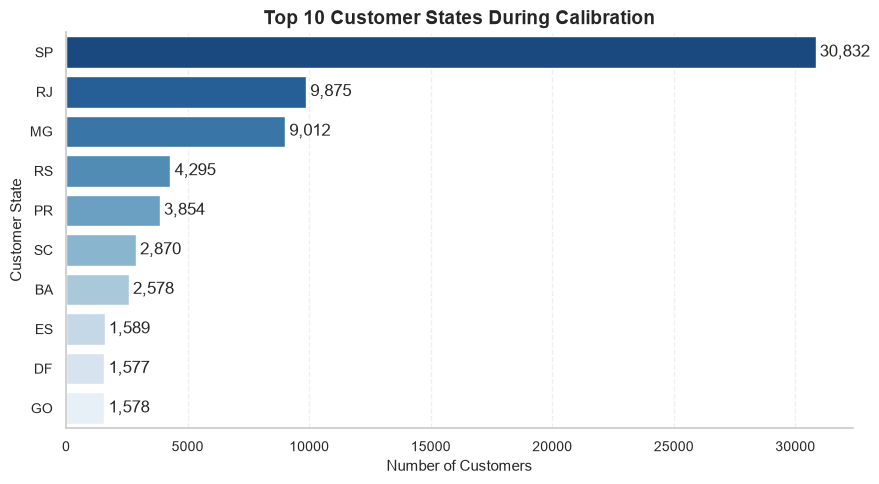

In [84]:
top_states_customers = state_summary.head(10)

plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=top_states_customers,
    x="n_customers",
    y="customer_state",
    hue="customer_state",
    palette="Blues_r",
    legend=False
)

add_horizontal_bar_labels(ax, fmt="{:,.0f}", padding=3)

plt.title("Top 10 Customer States During Calibration")
plt.xlabel("Number of Customers")
plt.ylabel("Customer State")
plt.grid(axis="x", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

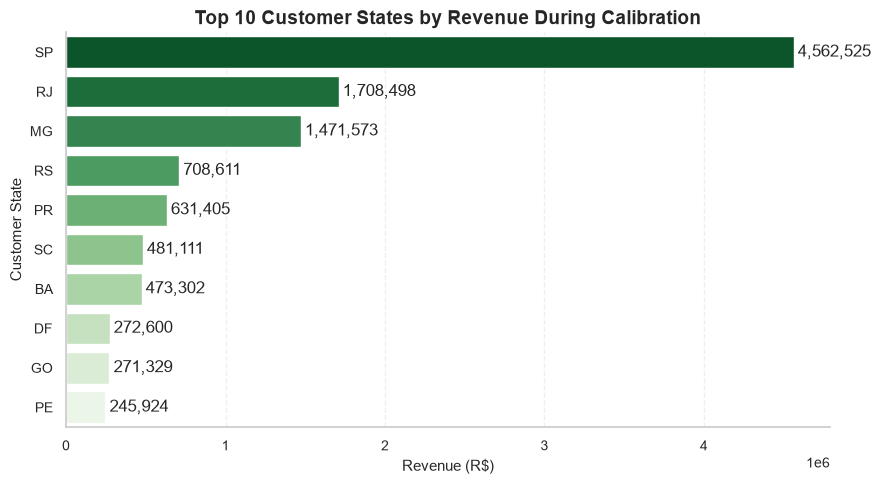

In [85]:
top_states_revenue = (
    state_summary
    .sort_values("revenue", ascending=False)
    .head(10)
)

plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=top_states_revenue,
    x="revenue",
    y="customer_state",
    hue="customer_state",
    palette="Greens_r",
    legend=False
)

add_horizontal_bar_labels(ax, fmt="{:,.0f}", padding=3)

plt.title("Top 10 Customer States by Revenue During Calibration")
plt.xlabel("Revenue (R$)")
plt.ylabel("Customer State")
plt.grid(axis="x", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

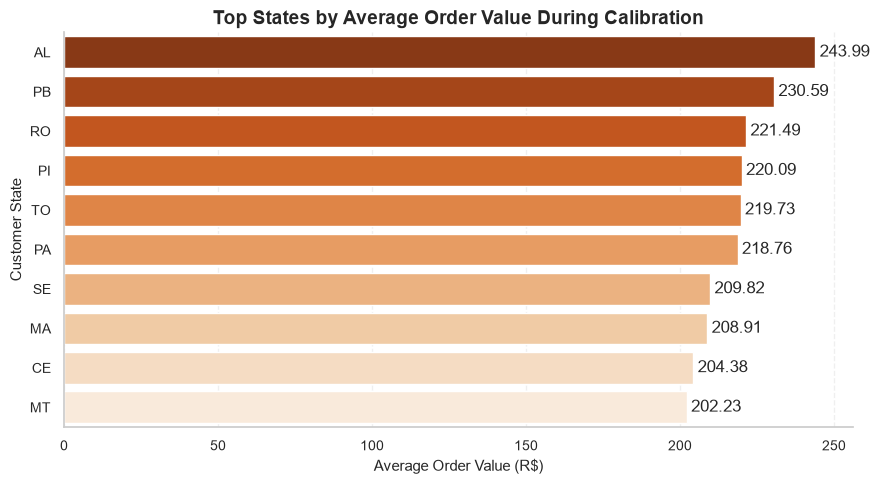

In [86]:
state_aov_filtered = (
    state_summary[state_summary["n_orders"] >= 100]
    .sort_values("avg_order_value", ascending=False)
    .head(10)
)

plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=state_aov_filtered,
    x="avg_order_value",
    y="customer_state",
    hue="customer_state",
    palette="Oranges_r",
    legend=False
)

add_horizontal_bar_labels(ax, fmt="{:,.2f}", padding=3)

plt.title(
    "Top States by Average Order Value During Calibration"
)
plt.xlabel("Average Order Value (R$)")
plt.ylabel("Customer State")
plt.grid(axis="x", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

The customer-count and revenue rankings are broadly aligned, confirming that the largest markets also generate the largest absolute economic contribution. However, the average-order-value ranking presents a different geographical profile.

States such as Alagoas, Paraíba and Rondônia show higher average order values despite contributing much lower overall volume. The minimum threshold of 100 orders makes this comparison more stable, but these differences should still be interpreted descriptively rather than as evidence that location directly causes greater customer value.

From a marketing perspective, high-volume states are the natural priority for scalable campaigns, while smaller high-AOV states may support more selective high-value targeting.

## **Product Category Analysis**

Product categories provide a commercial interpretation of the transactions observed during calibration. Each order has previously been assigned a main category corresponding to the category with the highest product value within that order.

Consequently, the revenue associated with a category represents the complete payment value of orders for which that category is dominant. It should therefore be interpreted as associated order revenue rather than the direct revenue of every individual item belonging to the category.

In [87]:
# Main product category analysis during calibration

category_summary = (
    calibration_orders
    .groupby("main_product_category")
    .agg(
        n_orders=("order_id", "nunique"),
        n_customers=("customer_unique_id", "nunique"),
        associated_order_revenue=("payment_value", "sum"),
        avg_order_value=("payment_value", "mean"),
        avg_review_score=("review_score", "mean")
    )
    .reset_index()
)

category_summary["orders_share_pct"] = (
    category_summary["n_orders"]
    / category_summary["n_orders"].sum()
    * 100
).round(2)

category_summary["associated_revenue_share_pct"] = (
    category_summary["associated_order_revenue"]
    / category_summary["associated_order_revenue"].sum()
    * 100
).round(2)

category_summary["associated_order_revenue"] = (
    category_summary["associated_order_revenue"].round(2)
)

category_summary["avg_order_value"] = (
    category_summary["avg_order_value"].round(2)
)

category_summary["avg_review_score"] = (
    category_summary["avg_review_score"].round(2)
)

category_summary = category_summary.sort_values(
    "n_orders",
    ascending=False
)

category_summary.head(10)

,main_product_category,n_orders,n_customers,associated_order_revenue,avg_order_value,avg_review_score,orders_share_pct,associated_revenue_share_pct
7,bed_bath_table,7503,7269,1001572.59,133.49,3.97,9.64,8.08
43,health_beauty,6371,6258,1033043.72,162.15,4.18,8.18,8.33
65,sports_leisure,6286,6125,939544.19,149.47,4.20,8.07,7.58
15,computers_accessories,5403,5291,886585.49,164.09,4.04,6.94,7.15
39,furniture_decor,5224,5116,717636.65,137.37,4.04,6.71,5.79
49,housewares,4228,4188,540273.50,127.78,4.16,5.43,4.36
71,watches_gifts,4142,4091,989487.13,238.89,4.12,5.32,7.98
68,telephony,3431,3396,280615.89,81.79,4.04,4.41,2.26
69,toys,3317,3283,482238.96,145.38,4.22,4.26,3.89
20,cool_stuff,3202,3189,626881.69,195.78,4.23,4.11,5.06


`bed_bath_table` is the largest main category by order volume, representing 9.64% of calibration orders. `health_beauty` and `sports_leisure` follow, showing that frequently purchased household, personal-care and leisure products form a substantial part of marketplace activity.

The revenue ranking differs slightly from the order ranking. `health_beauty` generates the largest associated order revenue, while `watches_gifts` contributes a substantially greater revenue share than order share because its average order value is considerably higher.

This distinction separates volume-driving categories from value-driving categories, which is useful for designing differentiated cross-selling, loyalty and promotional strategies.

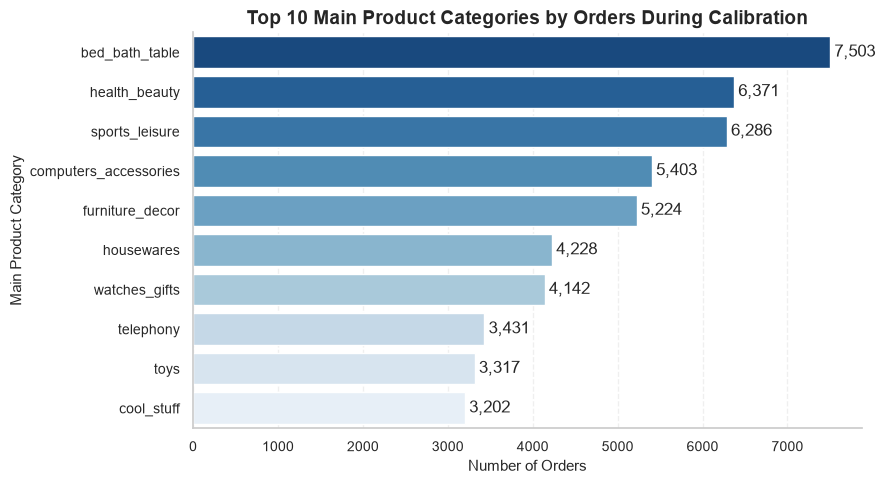

In [88]:
top_categories_orders = category_summary.head(10)

plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=top_categories_orders,
    x="n_orders",
    y="main_product_category",
    hue="main_product_category",
    palette="Blues_r",
    legend=False
)

add_horizontal_bar_labels(ax, fmt="{:,.0f}", padding=3)

plt.title(
    "Top 10 Main Product Categories by Orders During Calibration"
)
plt.xlabel("Number of Orders")
plt.ylabel("Main Product Category")
plt.grid(axis="x", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

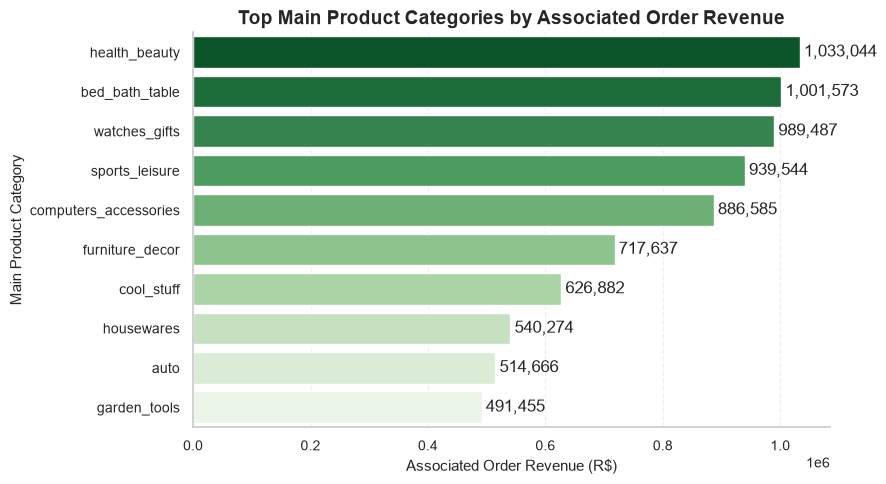

In [89]:
top_categories_revenue = (
    category_summary
    .sort_values(
        "associated_order_revenue",
        ascending=False
    )
    .head(10)
)

plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=top_categories_revenue,
    x="associated_order_revenue",
    y="main_product_category",
    hue="main_product_category",
    palette="Greens_r",
    legend=False
)

add_horizontal_bar_labels(ax, fmt="{:,.0f}", padding=3)

plt.title(
    "Top Main Product Categories by Associated Order Revenue"
)
plt.xlabel("Associated Order Revenue (R$)")
plt.ylabel("Main Product Category")
plt.grid(axis="x", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

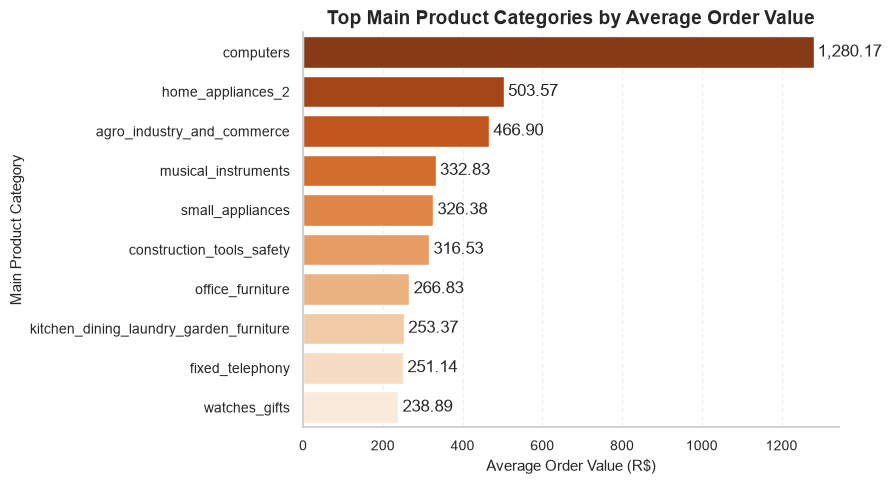

In [90]:
category_aov_filtered = (
    category_summary[
        category_summary["n_orders"] >= 100
    ]
    .sort_values("avg_order_value", ascending=False)
    .head(10)
)

plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=category_aov_filtered,
    x="avg_order_value",
    y="main_product_category",
    hue="main_product_category",
    palette="Oranges_r",
    legend=False
)

add_horizontal_bar_labels(ax, fmt="{:,.2f}", padding=3)

plt.title(
    "Top Main Product Categories by Average Order Value"
)
plt.xlabel("Average Order Value (R$)")
plt.ylabel("Main Product Category")
plt.grid(axis="x", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

The category rankings reveal three different commercial roles. High-volume categories such as `bed_bath_table`, `health_beauty` and `sports_leisure` offer the broadest customer reach. Categories such as `watches_gifts` generate comparatively high associated revenue despite lower transaction volume, indicating stronger value per order.

The average-order-value analysis identifies a separate set of high-ticket categories, led by computers and selected appliance or industrial categories. The 100-order threshold reduces the risk of treating categories with only a few exceptional purchases as strategically important.

For marketing activation, high-volume categories are suitable for broad repurchase and cross-selling initiatives, whereas high-AOV categories may require more selective audiences, stronger purchase-intent signals and lower-frequency communication.

## **Review and Delivery Experience**

Customer value may be influenced not only by what customers purchase, but also by the experience surrounding the transaction. This section examines review scores, actual delivery duration and the difference between the promised and realized delivery dates.

A positive delivery-delay value indicates that the order arrived after the estimated date, while a negative value means that the order arrived earlier than promised. These variables are constructed exclusively from calibration-period information and may later be used as behavioural features in the machine learning model.

In [91]:
# Create delivery experience variables during calibration

experience_orders = calibration_orders.copy()

experience_orders["actual_delivery_days"] = (
    experience_orders["order_delivered_customer_date"]
    - experience_orders["order_purchase_timestamp"]
).dt.days

experience_orders["delivery_delay_days"] = (
    experience_orders["order_delivered_customer_date"]
    - experience_orders["order_estimated_delivery_date"]
).dt.days

# Preserve missing delivery information instead of treating it as on-time
valid_delay_mask = (
    experience_orders["delivery_delay_days"].notna()
)

experience_orders["late_delivery_flag"] = pd.Series(
    pd.NA,
    index=experience_orders.index,
    dtype="Int64"
)

experience_orders.loc[
    valid_delay_mask,
    "late_delivery_flag"
] = (
    experience_orders.loc[
        valid_delay_mask,
        "delivery_delay_days"
    ] > 0
).astype(int)

experience_orders["delivery_status"] = pd.Series(
    pd.NA,
    index=experience_orders.index,
    dtype="string"
)

experience_orders.loc[
    valid_delay_mask,
    "delivery_status"
] = np.where(
    experience_orders.loc[
        valid_delay_mask,
        "delivery_delay_days"
    ] > 0,
    "Late delivery",
    "On-time or early"
)

experience_orders[[
    "order_id",
    "customer_unique_id",
    "review_score",
    "actual_delivery_days",
    "delivery_delay_days",
    "delivery_status"
]].head()

,order_id,customer_unique_id,review_score,actual_delivery_days,delivery_delay_days,delivery_status
0,e481f51cbdc54678b7cc49136f2d6af7,7c396fd4830fd04220f754e42b4e5bff,4.0,8.0,-8.0,On-time or early
3,949d5b44dbf5de918fe9c16f97b45f8a,7c142cf63193a1473d2e66489a9ae977,5.0,13.0,-13.0,On-time or early
4,ad21c59c0840e6cb83a9ceb5573f8159,72632f0f9dd73dfee390c9b22eb56dd6,5.0,2.0,-10.0,On-time or early
5,a4591c265e18cb1dcee52889e2d8acc3,80bb27c7c16e8f973207a5086ab329e2,4.0,16.0,-6.0,On-time or early
6,6514b8ad8028c9f2cc2374ded245783f,932afa1e708222e5821dac9cd5db4cae,5.0,9.0,-12.0,On-time or early


In [92]:
valid_delivery_orders = experience_orders[
    valid_delay_mask
].copy()

In [93]:
experience_check = pd.DataFrame({
    "metric": [
        "orders in calibration",
        "missing review score",
        "missing actual delivery days",
        "missing delivery delay days",
        "orders with valid delivery timing",
        "late deliveries",
        "late delivery rate (%)"
    ],
    "value": [
        len(experience_orders),
        experience_orders["review_score"].isna().sum(),
        experience_orders["actual_delivery_days"].isna().sum(),
        experience_orders["delivery_delay_days"].isna().sum(),
        len(valid_delivery_orders),
        valid_delivery_orders["late_delivery_flag"].sum(),
        valid_delivery_orders["late_delivery_flag"].mean() * 100
    ]
})

experience_check["value"] = (
    experience_check["value"].round(2)
)

experience_check

,metric,value
0,orders in calibration,77868.00
1,missing review score,563.00
2,missing actual delivery days,2.00
3,missing delivery delay days,2.00
4,orders with valid delivery timing,77866.00
5,late deliveries,5861.00
6,late delivery rate (%),7.53


Delivery information is almost complete: only two calibration orders lack the dates required to compute delivery timing. These observations are retained in the dataset but excluded from delivery-status comparisons rather than being automatically classified as on time.

Among orders with valid delivery information, 5,861 were delivered after the estimated date, corresponding to a late-delivery rate of 7.53%. Review-score missingness is also limited, with 563 orders lacking a customer evaluation.

The low overall missingness makes delivery and review information suitable for exploratory analysis and for later customer-level feature engineering.

In [94]:
# Create review-score groups for visualization only

review_plot = (
    experience_orders
    .dropna(subset=["review_score"])
    .copy()
)

# Standard half-up rounding:
# 1.5 -> 2, 2.5 -> 3, 3.5 -> 4, 4.5 -> 5
review_plot["review_score_group"] = (
    np.floor(review_plot["review_score"] + 0.5)
    .clip(1, 5)
    .astype(int)
)

review_score_summary = (
    review_plot["review_score_group"]
    .value_counts()
    .sort_index()
    .rename_axis("review_score")
    .reset_index(name="n_orders")
)

review_score_summary

,review_score,n_orders
0,1,7987
1,2,2447
2,3,6676
3,4,15415
4,5,44780


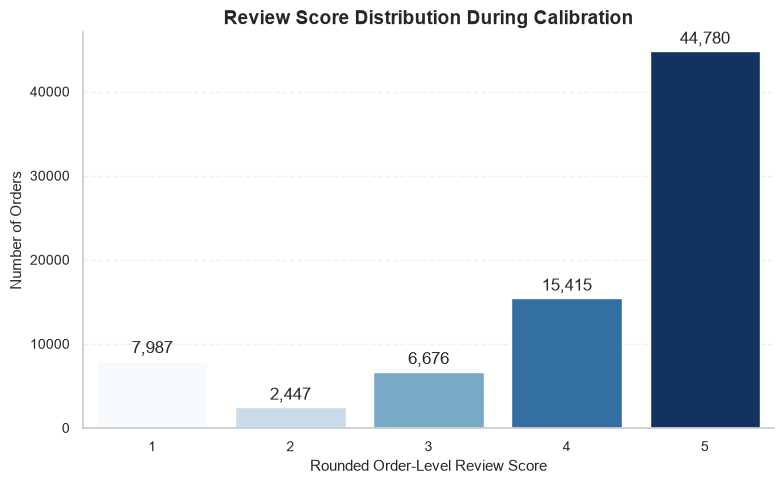

In [95]:
plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=review_plot,
    x="review_score_group",
    hue="review_score_group",
    palette="Blues",
    legend=False
)

add_bar_labels(ax)

plt.title("Review Score Distribution During Calibration")
plt.xlabel("Rounded Order-Level Review Score")
plt.ylabel("Number of Orders")
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

Customer evaluations are predominantly positive, with score 5 representing the largest review group, followed by score 4. Nevertheless, a visible group of one-star reviews indicates that a non-negligible share of transactions generated substantial dissatisfaction.

Orders with multiple review records have an averaged order-level score. For visualization, these averages are assigned to the nearest integer score using conventional half-up rounding, while the original continuous averages remain unchanged for customer-level aggregation and modelling.

In [96]:
delivery_order = ["On-time or early", "Late delivery"]
delivery_palette = {
    "On-time or early": "#54A24B",
    "Late delivery": "#E45756"
}

In [97]:
delivery_status_summary = (
    valid_delivery_orders["delivery_status"]
    .value_counts()
    .reindex(delivery_order)
    .reset_index()
)

delivery_status_summary.columns = [
    "delivery_status",
    "n_orders"
]

delivery_status_summary["percentage"] = (
    delivery_status_summary["n_orders"]
    / len(valid_delivery_orders)
    * 100
).round(2)

delivery_status_summary

,delivery_status,n_orders,percentage
0,On-time or early,72005,92.47
1,Late delivery,5861,7.53


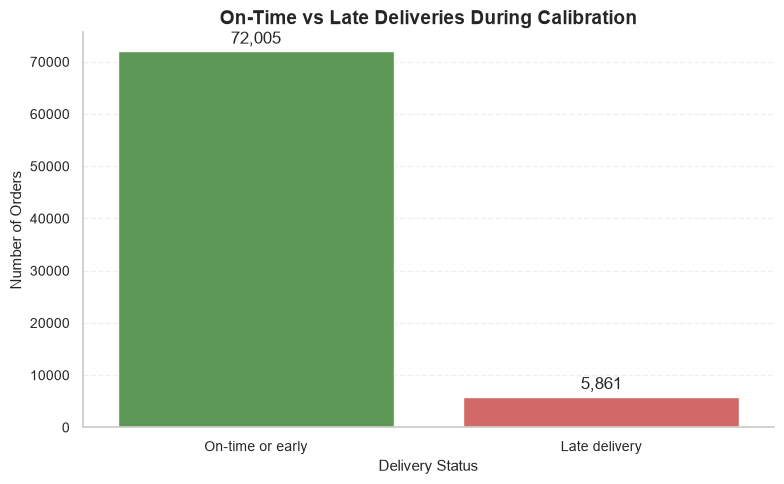

In [98]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=delivery_status_summary,
    x="delivery_status",
    y="n_orders",
    hue="delivery_status",
    order=delivery_order,
    palette=delivery_palette,
    legend=False
)

add_bar_labels(ax)

plt.title("On-Time vs Late Deliveries During Calibration")
plt.xlabel("Delivery Status")
plt.ylabel("Number of Orders")
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

Most calibration orders were delivered on or before the promised date. On-time or early deliveries account for 92.47% of orders with valid timing information, while 7.53% arrived late.

Although late deliveries represent a minority of transactions, they are commercially relevant because the following analysis shows a substantial difference in customer satisfaction between the two delivery groups.

### **Delivery Status and Review Score**

In [99]:
delivery_review_summary = (
    valid_delivery_orders
    .dropna(subset=["review_score"])
    .groupby("delivery_status")
    .agg(
        n_orders=("order_id", "nunique"),
        avg_review_score=("review_score", "mean"),
        median_review_score=("review_score", "median"),
        avg_delivery_delay_days=(
            "delivery_delay_days",
            "mean"
        )
    )
    .reindex(delivery_order)
    .reset_index()
)

delivery_review_summary = (
    delivery_review_summary.round(2)
)

delivery_review_summary

,delivery_status,n_orders,avg_review_score,median_review_score,avg_delivery_delay_days
0,On-time or early,71579,4.27,5.0,-13.49
1,Late delivery,5724,2.21,1.0,10.96


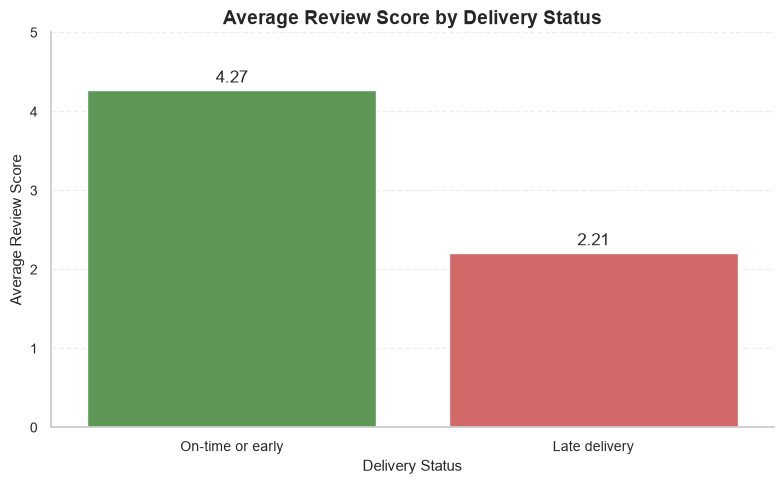

In [100]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=delivery_review_summary,
    x="delivery_status",
    y="avg_review_score",
    hue="delivery_status",
    order=delivery_order,
    palette=delivery_palette,
    legend=False
)

add_bar_labels(ax, fmt="{:.2f}")

plt.title("Average Review Score by Delivery Status")
plt.xlabel("Delivery Status")
plt.ylabel("Average Review Score")
plt.ylim(0, 5)
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

Delivery performance shows a strong descriptive association with customer satisfaction. Orders delivered on time or early receive an average review score of 4.27 and a median score of 5. In contrast, late deliveries receive an average score of only 2.21 and a median score of 1.

On-time orders arrive, on average, approximately 13.5 days before the estimated date, while late orders arrive around 11 days after the promised date. The difference is therefore operationally substantial rather than being driven only by very short delays.

This relationship does not by itself establish causality, but it identifies delivery reliability as an important customer-experience signal that may help explain future engagement.

### **Delivery Delay by Review Score**

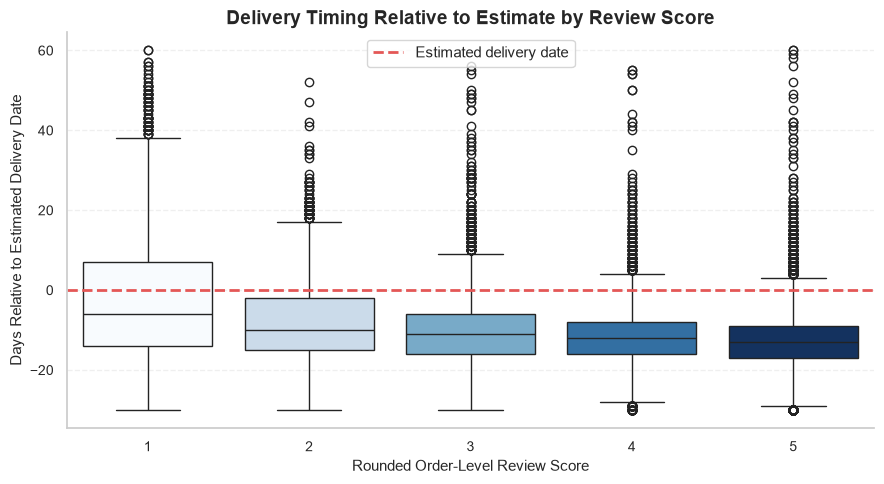

In [101]:
plt.figure(figsize=(9, 5))

delay_review_plot = (
    valid_delivery_orders
    .merge(
        review_plot[
            ["order_id", "review_score_group"]
        ],
        on="order_id",
        how="inner"
    )
)

# Restrict the displayed range only to make the boxplot readable
delay_review_plot = delay_review_plot[
    delay_review_plot["delivery_delay_days"]
    .between(-30, 60)
].copy()

ax = sns.boxplot(
    data=delay_review_plot,
    x="review_score_group",
    y="delivery_delay_days",
    hue="review_score_group",
    palette="Blues",
    legend=False
)

plt.axhline(
    0,
    color="#E45756",
    linestyle="--",
    linewidth=2,
    label="Estimated delivery date"
)

plt.title("Delivery Timing Relative to Estimate by Review Score")
plt.xlabel("Rounded Order-Level Review Score")
plt.ylabel("Days Relative to Estimated Delivery Date")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

The distribution confirms a clear relationship between delivery timing and customer evaluation. Lower review scores are associated with later and more variable delivery outcomes, while four- and five-star orders are more strongly concentrated below zero, indicating delivery before the estimated date.

The displayed range is restricted to deliveries occurring between 30 days early and 60 days late so that the central distributions remain readable. This restriction affects only the visualization; no observations are removed from the modelling dataset.

Delivery timing is therefore retained as a meaningful experience feature, but it should be interpreted together with other factors such as product quality, seller performance and customer expectations.

## **RFM Feature Engineering**

The calibration-period customer table is now transformed into a deterministic RFM representation. Recency measures the number of days since the customer's last purchase, Frequency represents the total number of orders completed during calibration, and Monetary Value measures the actual revenue generated by the customer.

This deterministic Frequency definition must not be confused with the BTYD convention used later. In the RFM section, a one-time customer has Frequency equal to one. In the BTYD model, the same customer has frequency equal to zero because no repeat purchase has yet occurred.

Customer tenure, average order value, review score and main-category variety are retained as additional descriptive and modelling features.

In [102]:
# Assemble the deterministic RFM table from calibration data

rfm_table = customer_calibration[[
    "customer_unique_id",
    "customer_state",
    "recency_days",
    "n_orders",
    "total_revenue",
    "total_revenue_capped_by_customer",
    "tenure_days",
    "avg_order_value",
    "avg_review_score",
    "n_unique_main_categories"
]].copy()

# Rename the core behavioural variables using RFM terminology
rfm_table = rfm_table.rename(columns={
    "recency_days": "recency",
    "n_orders": "frequency",
    "total_revenue": "monetary_value",
    "total_revenue_capped_by_customer": "monetary_value_capped",
    "tenure_days": "T"
})

print("RFM table shape:", rfm_table.shape)
rfm_table.head()

RFM table shape: (75386, 10)


,customer_unique_id,customer_state,recency,frequency,monetary_value,monetary_value_capped,T,avg_order_value,avg_review_score,n_unique_main_categories
0,0000366f3b9a7992bf8c76cfdf3221e2,SP,21,1,141.90,141.90,21,141.90,5.0,1
1,0000b849f77a49e4a4ce2b2a4ca5be3f,SP,24,1,27.19,27.19,24,27.19,4.0,1
2,0000f46a3911fa3c0805444483337064,SC,447,1,86.22,86.22,447,86.22,3.0,1
3,0000f6ccb0745a6a4b88665a16c9f078,PA,231,1,43.62,43.62,231,43.62,4.0,1
4,0004aac84e0df4da2b147fca70cf8255,SP,198,1,196.89,196.89,198,196.89,5.0,1


The resulting RFM table contains one row for each of the 75,386 customers observed during calibration. Recency and tenure are measured relative to the calibration boundary, ensuring that no holdout information enters the customer profile.

Frequency represents the total number of calibration orders, while Monetary Value preserves the customer's actual historical revenue. A separate capped monetary variable is retained for robust machine learning, but it is not used to calculate the historical revenue contribution of the RFM segments.

### **R, F and M Scores**

In [103]:
# Assign R, F and M scores using rules adapted
# to Olist's low repeat-purchase structure

# Recency: lower values indicate more recent activity
rfm_table["R_score"] = pd.qcut(
    rfm_table["recency"],
    q=5,
    labels=[5, 4, 3, 2, 1]
)

# Frequency: custom scoring because most customers are one-shot buyers
rfm_table["F_score"] = np.select(
    [
        rfm_table["frequency"] == 1,
        rfm_table["frequency"] == 2,
        rfm_table["frequency"] >= 3
    ],
    [
        1,
        3,
        5
    ],
    default=1
)

# Monetary: higher actual customer revenue indicates greater value
rfm_table["M_score"] = pd.qcut(
    rfm_table["monetary_value"].rank(
        method="first"
    ),
    q=5,
    labels=[1, 2, 3, 4, 5]
)

rfm_table["R_score"] = (
    rfm_table["R_score"].astype(int)
)

rfm_table["F_score"] = (
    rfm_table["F_score"].astype(int)
)

rfm_table["M_score"] = (
    rfm_table["M_score"].astype(int)
)

rfm_table["RFM_score"] = (
    rfm_table["R_score"].astype(str)
    + rfm_table["F_score"].astype(str)
    + rfm_table["M_score"].astype(str)
)

rfm_score_check = rfm_table[
    ["R_score", "F_score", "M_score"]
].describe()

rfm_score_check

,R_score,F_score,M_score
count,75386.000000,75386.000000,75386.000000
mean,3.003489,1.064097,2.999973
std,1.413501,0.379243,1.414232
min,1.000000,1.000000,1.000000
25%,2.000000,1.000000,2.000000
50%,3.000000,1.000000,3.000000
75%,4.000000,1.000000,4.000000
max,5.000000,5.000000,5.000000


Recency and Monetary Value are divided into five ranked groups. A score of 5 represents the most recent or highest-value customers, while a score of 1 represents the least recent or lowest-value group.

Frequency requires a custom rule because 97.04% of customers purchased only once. Assigning standard frequency quintiles would produce unstable or duplicated thresholds. One-order customers therefore receive score 1, two-order customers score 3, and customers with at least three orders score 5.

The combined RFM code is a descriptive customer-positioning tool rather than a continuous prediction of future value.

### **RFM Segment Assignment**

In [104]:
# Assign human-readable RFM segments adapted
# to Olist's marketplace structure

def assign_rfm_segment(row):
    r = row["R_score"]
    m = row["M_score"]
    frequency = row["frequency"]

    if frequency >= 2 and r >= 4 and m >= 4:
        return "Repeat Champions"

    elif frequency >= 2 and r >= 3:
        return "Repeat Loyal"

    elif frequency >= 2 and r <= 2:
        return "Repeat At Risk"

    elif frequency == 1 and r >= 4 and m >= 4:
        return "High-Value Recent One-Shot"

    elif frequency == 1 and r >= 4:
        return "Recent One-Shot"

    elif frequency == 1 and r <= 2 and m >= 4:
        return "High-Value One-Shot At Risk"

    elif frequency == 1 and r <= 2:
        return "Dormant / Lost"

    else:
        return "Potential Customers"


rfm_table["rfm_segment"] = rfm_table.apply(
    assign_rfm_segment,
    axis=1
)

segment_counts = (
    rfm_table["rfm_segment"]
    .value_counts()
    .rename_axis("rfm_segment")
    .reset_index(name="n_customers")
)

segment_counts["percentage"] = (
    segment_counts["n_customers"]
    / len(rfm_table)
    * 100
).round(2)

segment_counts

,rfm_segment,n_customers,percentage
0,Dormant / Lost,18169,24.10
1,Recent One-Shot,17624,23.38
2,Potential Customers,14723,19.53
3,High-Value Recent One-Shot,11534,15.30
4,High-Value One-Shot At Risk,11106,14.73
5,Repeat Champions,827,1.10
6,Repeat At Risk,791,1.05
7,Repeat Loyal,612,0.81


The segmentation reflects Olist's unusual customer structure by separating repeat relationships from one-shot purchasing behaviour. Most customers belong to one-shot segments, while the three repeat segments together represent only a small fraction of the customer base.

Recent one-shot customers represent the most immediate second-purchase opportunity. High-value one-shot customers at risk have generated meaningful historical revenue but have not purchased recently, making them relevant for selective reactivation. Repeat Champions and Repeat Loyal customers are numerically much smaller but represent the most developed customer relationships in the marketplace.

These labels are business-oriented rules designed for this dataset and should not be interpreted as universal RFM categories.

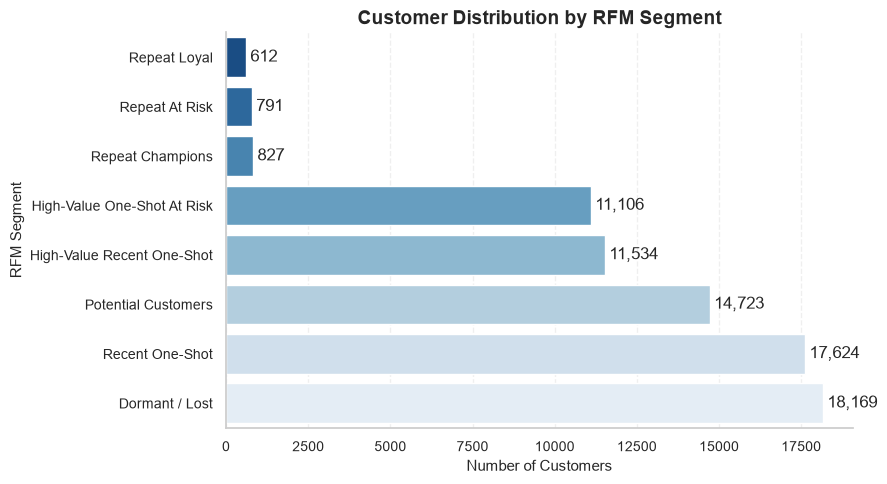

In [105]:
# Segment size visualization
segment_counts_plot = (
    segment_counts
    .sort_values("n_customers", ascending=True)
)

plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=segment_counts_plot,
    x="n_customers",
    y="rfm_segment",
    hue="rfm_segment",
    palette="Blues_r",
    legend=False
)

add_horizontal_bar_labels(
    ax,
    fmt="{:,.0f}",
    padding=3
)

plt.title("Customer Distribution by RFM Segment")
plt.xlabel("Number of Customers")
plt.ylabel("RFM Segment")
plt.grid(axis="x", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

The segment-size distribution confirms that Olist's customer portfolio is dominated by first-purchase relationships. Dormant, potential and recent one-shot groups are substantially larger than the repeat-customer segments.

This imbalance suggests that a single loyalty strategy would be inappropriate. The largest operational challenge is second-purchase conversion, while retention and value protection should be reserved for the much smaller group of customers with established repeat behaviour.

### **RFM Segment Profiles**

Segment size alone does not determine business importance. The following profile compares behavioural maturity, customer experience and economic contribution across the RFM segments, distinguishing large low-maturity groups from smaller but strategically valuable customer relationships.

In [106]:
segment_profile = (
    rfm_table
    .groupby("rfm_segment")
    .agg(
        n_customers=(
            "customer_unique_id",
            "nunique"
        ),
        avg_recency=(
            "recency",
            "mean"
        ),
        avg_frequency=(
            "frequency",
            "mean"
        ),
        avg_monetary=(
            "monetary_value",
            "mean"
        ),
        avg_review_score=(
            "avg_review_score",
            "mean"
        ),
        total_revenue=(
            "monetary_value",
            "sum"
        )
    )
    .reset_index()
)

segment_profile["revenue_share_pct"] = (
    segment_profile["total_revenue"]
    / segment_profile["total_revenue"].sum()
    * 100
)

numeric_profile_cols = [
    "avg_recency",
    "avg_frequency",
    "avg_monetary",
    "avg_review_score",
    "total_revenue",
    "revenue_share_pct"
]

segment_profile[numeric_profile_cols] = (
    segment_profile[numeric_profile_cols]
    .round(2)
)

segment_profile = segment_profile.sort_values(
    "total_revenue",
    ascending=False
)

segment_profile

,rfm_segment,n_customers,avg_recency,avg_frequency,avg_monetary,avg_review_score,total_revenue,revenue_share_pct
1,High-Value One-Shot At Risk,11106,331.95,1.00,310.72,4.20,3450886.81,27.84
2,High-Value Recent One-Shot,11534,68.06,1.00,294.03,3.93,3391318.12,27.36
3,Potential Customers,14723,172.68,1.00,154.73,4.05,2278054.41,18.38
0,Dormant / Lost,18169,333.15,1.00,72.69,4.25,1320641.64,10.65
4,Recent One-Shot,17624,68.84,1.00,72.13,4.10,1271205.86,10.25
6,Repeat Champions,827,69.17,2.18,360.58,4.09,298200.81,2.41
5,Repeat At Risk,791,317.98,2.09,296.92,4.22,234859.97,1.89
7,Repeat Loyal,612,141.84,2.05,248.18,4.21,151885.33,1.23


The segment profile confirms that customer count and revenue contribution are not aligned. High-Value One-Shot At Risk and High-Value Recent One-Shot together represent approximately 30.0% of calibration customers but account for 55.2% of calibration revenue.

The two groups have similar historical monetary contribution but very different recency profiles. High-Value Recent One-Shot customers purchased approximately 68 days before the calibration cut-off on average, making them strong candidates for immediate second-purchase activation. High-Value One-Shot At Risk customers show an average recency of approximately 332 days and are therefore more appropriate for selective win-back actions.

Repeat segments are much smaller in population size, but their strategic relevance should be evaluated through relationship maturity, purchase frequency, probability alive and expected future value rather than customer count alone.

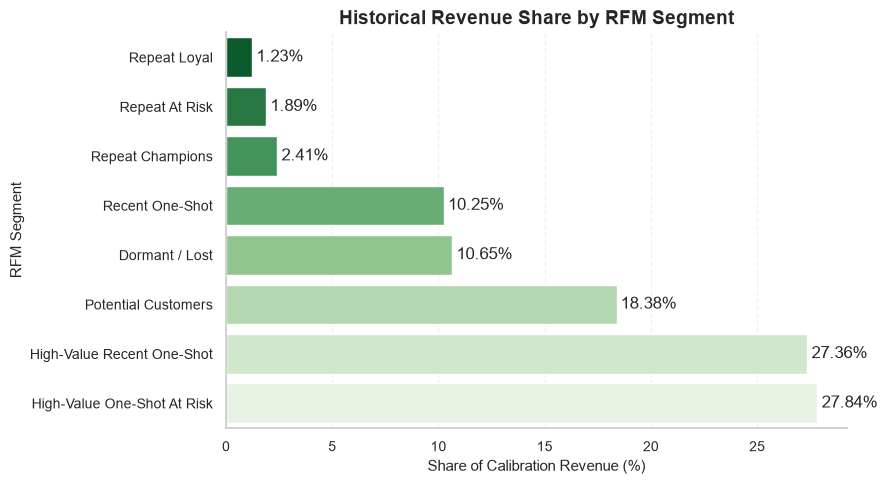

In [107]:
# Revenue share visualization by RFM segment
segment_revenue_plot = (
    segment_profile
    .sort_values(
        "revenue_share_pct",
        ascending=True
    )
)

plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=segment_revenue_plot,
    x="revenue_share_pct",
    y="rfm_segment",
    hue="rfm_segment",
    palette="Greens_r",
    legend=False
)

add_horizontal_bar_labels(
    ax,
    fmt="{:.2f}%",
    padding=3
)

plt.title(
    "Historical Revenue Share by RFM Segment"
)
plt.xlabel("Share of Calibration Revenue (%)")
plt.ylabel("RFM Segment")
plt.grid(axis="x", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

Historical revenue is concentrated in the high-value one-shot groups rather than exclusively among repeat customers. This result reflects the scale of first-time purchasing in Olist: a large customer segment can generate substantial historical revenue even when its future retention probability remains uncertain.

The distinction is strategically important. RFM identifies where value has already been generated, while the subsequent CLTV models estimate whether that value is likely to continue. High historical spending alone is therefore insufficient for deciding where to invest retention budget.

## **BTYD Calibration and Holdout Customer Table**

The deterministic RFM table describes historical customer behaviour, while the Buy Till You Die framework requires a different set of customer-level definitions.

In BTYD models, `frequency_cal` represents the number of repeat transaction occasions observed after the customer's first purchase. A customer with only one calibration purchase therefore has frequency equal to zero. `recency_cal` measures the time between the first and last calibration transaction, while `T_cal` measures the time between the first transaction and the end of calibration.

`monetary_value_cal` represents the average value of repeat transactions and is relevant only for customers with at least one repeat purchase. The table is built using the original positive payment value rather than the capped machine learning feature, so that probabilistic CLTV remains interpretable as expected monetary revenue.

In [108]:
# Build the canonical calibration-holdout table
# required by the lifetimes BTYD framework

observation_end = (
    order_level_clean["order_purchase_timestamp"].max()
)

btyd_cal_holdout = calibration_and_holdout_data(
    order_level_clean,
    customer_id_col="customer_unique_id",
    datetime_col="order_purchase_timestamp",
    monetary_value_col="payment_value",
    calibration_period_end=calibration_end,
    observation_period_end=observation_end,
    freq="D"
).reset_index()

btyd_cal_holdout.head()

,customer_unique_id,frequency_cal,recency_cal,T_cal,monetary_value_cal,frequency_holdout,monetary_value_holdout,duration_holdout
0,0000366f3b9a7992bf8c76cfdf3221e2,0.0,0.0,21.0,0.0,0.0,0.0,90.0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,0.0,0.0,24.0,0.0,0.0,0.0,90.0
2,0000f46a3911fa3c0805444483337064,0.0,0.0,447.0,0.0,0.0,0.0,90.0
3,0000f6ccb0745a6a4b88665a16c9f078,0.0,0.0,231.0,0.0,0.0,0.0,90.0
4,0004aac84e0df4da2b147fca70cf8255,0.0,0.0,198.0,0.0,0.0,0.0,90.0


The canonical BTYD table contains one row for each customer observed during calibration. Customers with `frequency_cal = 0` completed only their first transaction and therefore have both `recency_cal` and `monetary_value_cal` equal to zero.

`T_cal` measures how long each customer has been observed before the calibration boundary, while `duration_holdout` confirms that the future evaluation window covers 90 days. All BTYD variables are constructed exclusively from information available before or during the corresponding observation period.

In [109]:
# Add the total number of calibration orders for interpretation

calibration_order_counts = (
    calibration_orders
    .groupby("customer_unique_id")
    .agg(
        n_calibration_orders=("order_id", "nunique")
    )
    .reset_index()
)

btyd_cal_holdout = (
    btyd_cal_holdout
    .merge(
        calibration_order_counts,
        on="customer_unique_id",
        how="left"
    )
)

btyd_cal_holdout["n_calibration_orders"] = (
    btyd_cal_holdout["n_calibration_orders"]
    .fillna(0)
    .astype(int)
)

btyd_cal_holdout.head()

,customer_unique_id,frequency_cal,recency_cal,T_cal,monetary_value_cal,frequency_holdout,monetary_value_holdout,duration_holdout,n_calibration_orders
0,0000366f3b9a7992bf8c76cfdf3221e2,0.0,0.0,21.0,0.0,0.0,0.0,90.0,1
1,0000b849f77a49e4a4ce2b2a4ca5be3f,0.0,0.0,24.0,0.0,0.0,0.0,90.0,1
2,0000f46a3911fa3c0805444483337064,0.0,0.0,447.0,0.0,0.0,0.0,90.0,1
3,0000f6ccb0745a6a4b88665a16c9f078,0.0,0.0,231.0,0.0,0.0,0.0,90.0,1
4,0004aac84e0df4da2b147fca70cf8255,0.0,0.0,198.0,0.0,0.0,0.0,90.0,1


The total number of calibration orders is retained as an explanatory variable, but it does not replace `frequency_cal`.

`n_calibration_orders` counts individual orders, whereas `frequency_cal` follows the BTYD convention and counts repeated daily transaction occasions after the first purchase. A customer with one order therefore has `n_calibration_orders = 1` and `frequency_cal = 0`. Multiple orders placed by the same customer on the same day may also correspond to a single BTYD transaction occasion.

In [110]:
# Calculate the actual 90-day holdout outcomes
# used for model evaluation

holdout_actual = (
    holdout_orders
    .groupby("customer_unique_id")
    .agg(
        actual_orders_90d=("order_id", "nunique"),
        actual_revenue_90d=("payment_value", "sum")
    )
    .reset_index()
)

btyd_cal_holdout = (
    btyd_cal_holdout
    .merge(
        holdout_actual,
        on="customer_unique_id",
        how="left"
    )
)

btyd_cal_holdout["actual_orders_90d"] = (
    btyd_cal_holdout["actual_orders_90d"]
    .fillna(0)
    .astype(int)
)

btyd_cal_holdout["actual_revenue_90d"] = (
    btyd_cal_holdout["actual_revenue_90d"]
    .fillna(0)
)

btyd_cal_holdout.head()

,customer_unique_id,frequency_cal,recency_cal,T_cal,monetary_value_cal,frequency_holdout,monetary_value_holdout,duration_holdout,n_calibration_orders,actual_orders_90d,actual_revenue_90d
0,0000366f3b9a7992bf8c76cfdf3221e2,0.0,0.0,21.0,0.0,0.0,0.0,90.0,1,0,0.0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,0.0,0.0,24.0,0.0,0.0,0.0,90.0,1,0,0.0
2,0000f46a3911fa3c0805444483337064,0.0,0.0,447.0,0.0,0.0,0.0,90.0,1,0,0.0
3,0000f6ccb0745a6a4b88665a16c9f078,0.0,0.0,231.0,0.0,0.0,0.0,90.0,1,0,0.0
4,0004aac84e0df4da2b147fca70cf8255,0.0,0.0,198.0,0.0,0.0,0.0,90.0,1,0,0.0


The canonical `lifetimes` table already reports holdout frequency and average monetary value, but these variables do not directly measure the complete realized revenue generated by each customer.

For model evaluation, actual order count and total payment value are therefore aggregated directly from the holdout transactions. Customers without a holdout purchase receive zero actual orders and zero actual revenue. The original, uncapped payment value is used because the evaluation target must represent the revenue that Olist actually generated.

In [111]:
# Validate the structure of the BTYD customer table

btyd_validation = pd.DataFrame({
    "check": [
        "negative calibration frequency",
        "negative calibration recency",
        "recency greater than customer age T",
        "negative calibration monetary value",
        "frequency zero with positive monetary value",
        "holdout duration different from 90 days"
    ],
    "n_cases": [
        (btyd_cal_holdout["frequency_cal"] < 0).sum(),

        (btyd_cal_holdout["recency_cal"] < 0).sum(),

        (
            btyd_cal_holdout["recency_cal"]
            > btyd_cal_holdout["T_cal"]
        ).sum(),

        (
            btyd_cal_holdout["monetary_value_cal"] < 0
        ).sum(),

        (
            (btyd_cal_holdout["frequency_cal"] == 0)
            & (btyd_cal_holdout["monetary_value_cal"] > 0)
        ).sum(),

        (
            ~np.isclose(
                btyd_cal_holdout["duration_holdout"],
                90
            )
        ).sum()
    ]
})

btyd_validation

,check,n_cases
0,negative calibration frequency,0
1,negative calibration recency,0
2,recency greater than customer age T,0
3,negative calibration monetary value,0
4,frequency zero with positive monetary value,0
5,holdout duration different from 90 days,0


All structural checks confirm that the table follows the BTYD requirements. Frequency, recency and monetary value are non-negative, and customer recency never exceeds the total observation age `T_cal`.

Customers without repeated calibration transactions correctly have zero repeat monetary value. The holdout duration is consistently equal to 90 days for the entire calibration customer base.

In [112]:
# Summarize calibration and holdout behaviour

repeat_calibration_mask = (
    btyd_cal_holdout["frequency_cal"] > 0
)

holdout_purchase_mask = (
    btyd_cal_holdout["actual_orders_90d"] > 0
)

btyd_check = pd.DataFrame({
    "metric": [
        "customers in BTYD calibration table",
        "customers with repeat transaction occasions in calibration",
        "share with repeat transaction occasions (%)",
        "customers with actual holdout repurchase",
        "actual holdout repurchase rate (%)",
        "total actual holdout revenue from calibration customers"
    ],
    "value": [
        len(btyd_cal_holdout),

        repeat_calibration_mask.sum(),

        repeat_calibration_mask.mean() * 100,

        holdout_purchase_mask.sum(),

        holdout_purchase_mask.mean() * 100,

        btyd_cal_holdout["actual_revenue_90d"].sum()
    ]
})

btyd_check["value"] = btyd_check["value"].round(2)

btyd_check

,metric,value
0,customers in BTYD calibration table,75386.00
1,customers with repeat transaction occasions in...,1503.00
2,share with repeat transaction occasions (%),1.99
3,customers with actual holdout repurchase,419.00
4,actual holdout repurchase rate (%),0.56
5,total actual holdout revenue from calibration ...,66978.67


Only a very small share of calibration customers generated repeated transaction occasions. The BTYD repeat rate is approximately 1.99%, lower than the earlier order-level repeat-customer rate of 2.96%.

The two results are not contradictory. The deterministic analysis counts individual orders, whereas the BTYD framework uses daily purchasing occasions. Multiple orders placed by the same customer on the same day are therefore combined into a single transaction occasion.

Future purchasing is even rarer: only 419 calibration customers purchase during the 90-day holdout, corresponding to 0.56% of the calibration customer base. These customers generate R$66,978.67 in observed holdout revenue, creating a highly sparse forecasting problem.

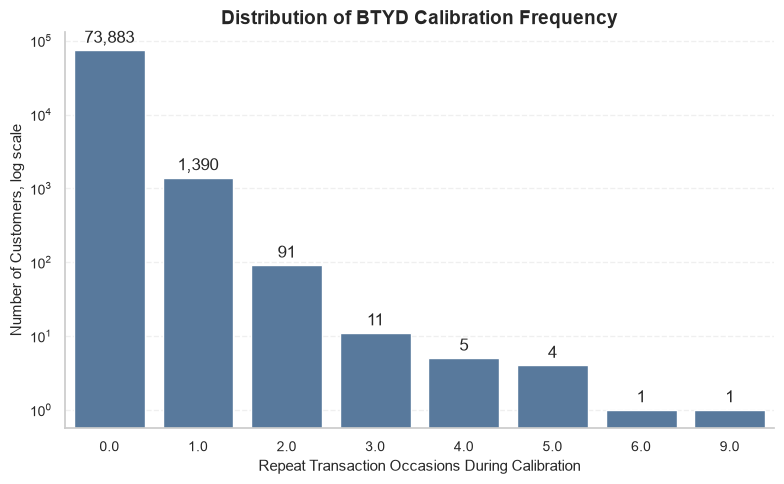

In [113]:
frequency_counts = (
    btyd_cal_holdout["frequency_cal"]
    .value_counts()
    .sort_index()
    .rename_axis("frequency_cal")
    .reset_index(name="n_customers")
)

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=frequency_counts,
    x="frequency_cal",
    y="n_customers",
    color="#4C78A8"
)

add_bar_labels(ax)

ax.set_yscale("log")

plt.title(
    "Distribution of BTYD Calibration Frequency"
)
plt.xlabel(
    "Repeat Transaction Occasions During Calibration"
)
plt.ylabel("Number of Customers, log scale")
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

The BTYD frequency distribution confirms the extremely limited repeat-purchase structure of the dataset. Most customers have calibration frequency equal to zero, meaning that only their first transaction was observed.

The logarithmic scale reveals the much smaller groups with one or more repeated transaction occasions. This imbalance creates a challenging modelling context: BG/NBD must estimate future activity from a customer base in which repeated behaviour is rare, while Gamma-Gamma can only be fitted on the subset with positive repeat frequency and monetary value.

For this reason, probabilistic predictions should be evaluated not only through average error metrics, but also through their ability to identify the small group of customers who generate future revenue.

## **BG/NBD Model**

The BG/NBD model estimates the expected number of future transactions by combining two behavioural processes: the rate at which an active customer purchases and the probability that the customer becomes inactive.

The model is fitted on the complete calibration customer base, including customers with `frequency_cal = 0`. Frequency, recency and customer age are taken directly from the canonical BTYD table constructed above. No holdout outcome is used during model fitting.

Because repeated purchasing is extremely rare in the Olist data, model regularization and holdout validation are particularly important. The objective is not only to minimize average prediction error, but also to identify the small group of customers most likely to purchase again.

In [114]:
# Prepare the complete calibration customer base for BG/NBD

bgf_data = btyd_cal_holdout[
    [
        "customer_unique_id",
        "frequency_cal",
        "recency_cal",
        "T_cal",
        "monetary_value_cal",
        "frequency_holdout",
        "monetary_value_holdout",
        "duration_holdout",
        "n_calibration_orders",
        "actual_orders_90d",
        "actual_revenue_90d"
    ]
].copy()

# Validate the variables required by BG/NBD
assert bgf_data[
    ["frequency_cal", "recency_cal", "T_cal"]
].notna().all().all()

assert (bgf_data["frequency_cal"] >= 0).all()
assert (bgf_data["recency_cal"] >= 0).all()
assert (bgf_data["T_cal"] >= 0).all()
assert (bgf_data["recency_cal"] <= bgf_data["T_cal"]).all()

bgf_coverage_check = pd.DataFrame({
    "metric": [
        "customers available for BG/NBD",
        "customers with zero calibration frequency",
        "customers with positive calibration frequency",
        "share with positive calibration frequency (%)",
        "holdout duration in days"
    ],
    "value": [
        len(bgf_data),
        (bgf_data["frequency_cal"] == 0).sum(),
        (bgf_data["frequency_cal"] > 0).sum(),
        (bgf_data["frequency_cal"] > 0).mean() * 100,
        bgf_data["duration_holdout"].iloc[0]
    ]
})

bgf_coverage_check["value"] = bgf_coverage_check["value"].round(2)

bgf_coverage_check

,metric,value
0,customers available for BG/NBD,75386.00
1,customers with zero calibration frequency,73883.00
2,customers with positive calibration frequency,1503.00
3,share with positive calibration frequency (%),1.99
4,holdout duration in days,90.00


The BG/NBD estimation base contains every customer observed during calibration. Customers with no repeated transaction occasion are intentionally retained rather than treated as missing or unsuitable observations.

The large concentration of customers at `frequency_cal = 0` reflects Olist's predominantly one-time purchasing structure. This makes the forecasting problem difficult, but it is precisely the behavioural pattern that the model must learn rather than remove.

In [115]:
# Fit BG/NBD on the complete calibration customer base

bgf = BetaGeoFitter(penalizer_coef=0.01)

bgf.fit(
    bgf_data["frequency_cal"],
    bgf_data["recency_cal"],
    bgf_data["T_cal"]
)

bgf.summary

,coef,se(coef),lower 95% bound,upper 95% bound
r,0.016656,0.000967,0.014760,0.018552
alpha,69.237549,6.650894,56.201798,82.273301
a,0.086915,0.020695,0.046352,0.127478
b,0.016629,0.004254,0.008292,0.024966


The BG/NBD parameters describe unobserved heterogeneity in customers' purchasing rates and dropout probabilities. They should not be interpreted as ordinary regression coefficients or direct causal effects.

The regularization term stabilizes estimation in a dataset dominated by customers with no repeated calibration transaction. Model usefulness must therefore be assessed on the separate holdout period rather than inferred only from the fitted parameter values.

In [116]:
# Generate 90-day purchase predictions for every calibration customer

prediction_horizon_days = int(
    bgf_data["duration_holdout"].iloc[0]
)

bgf_data["predicted_purchases_90d"] = bgf.predict(
    prediction_horizon_days,
    bgf_data["frequency_cal"],
    bgf_data["recency_cal"],
    bgf_data["T_cal"]
)

bgf_data["probability_alive"] = (
    bgf.conditional_probability_alive(
        bgf_data["frequency_cal"],
        bgf_data["recency_cal"],
        bgf_data["T_cal"]
    )
)

bgf_data[
    [
        "customer_unique_id",
        "frequency_cal",
        "recency_cal",
        "T_cal",
        "frequency_holdout",
        "predicted_purchases_90d",
        "probability_alive"
    ]
].head()

,customer_unique_id,frequency_cal,recency_cal,T_cal,frequency_holdout,predicted_purchases_90d,probability_alive
0,0000366f3b9a7992bf8c76cfdf3221e2,0.0,0.0,21.0,0.0,0.012254,1.0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,0.0,0.0,24.0,0.0,0.011947,1.0
2,0000f46a3911fa3c0805444483337064,0.0,0.0,447.0,0.0,0.002710,1.0
3,0000f6ccb0745a6a4b88665a16c9f078,0.0,0.0,231.0,0.0,0.004458,1.0
4,0004aac84e0df4da2b147fca70cf8255,0.0,0.0,198.0,0.0,0.004947,1.0


Each customer now receives two probabilistic signals. `predicted_purchases_90d` is the expected number of transaction occasions during the holdout horizon, while `probability_alive` represents the estimated probability that the customer remains behaviourally active at the end of calibration.

These values are expectations rather than deterministic classifications. A prediction below one does not mean that a customer cannot purchase; it means that the expected number of future purchasing occasions is fractional when averaged over customers with similar histories.

For customers with frequency_cal equal to zero, the BG/NBD model may return a probability alive equal to one by construction. This should not be interpreted as evidence that all one-time buyers are certainly active. Their low expected number of future purchases still reflects the limited behavioural evidence available for predicting another transaction.

In [117]:
# Evaluate BG/NBD against transaction occasions observed in holdout

frequency_holdout_actual = bgf_data["frequency_holdout"]
frequency_holdout_predicted = bgf_data["predicted_purchases_90d"]

bgnbd_mae = mean_absolute_error(
    frequency_holdout_actual,
    frequency_holdout_predicted
)

bgnbd_mse = mean_squared_error(
    frequency_holdout_actual,
    frequency_holdout_predicted
)

bgnbd_rmse = np.sqrt(bgnbd_mse)

# Evaluate the ability to concentrate actual repeat activity
# within the highest-ranked 10% of customers
n_top_bgnbd = max(
    1,
    int(np.ceil(len(bgf_data) * 0.10))
)

bgf_ranked = bgf_data.sort_values(
    "predicted_purchases_90d",
    ascending=False
)

total_holdout_frequency = (
    bgf_ranked["frequency_holdout"].sum()
)

top_decile_holdout_frequency = (
    bgf_ranked
    .head(n_top_bgnbd)["frequency_holdout"]
    .sum()
)

bgnbd_top_decile_capture = (
    top_decile_holdout_frequency
    / total_holdout_frequency
    * 100
    if total_holdout_frequency > 0
    else np.nan
)

bgnbd_evaluation = pd.DataFrame({
    "metric": [
        "MAE",
        "MSE",
        "RMSE",
        "mean actual holdout frequency",
        "mean predicted holdout frequency",
        "total actual holdout frequency",
        "total predicted holdout frequency",
        "top-decile holdout frequency capture (%)"
    ],
    "value": [
        bgnbd_mae,
        bgnbd_mse,
        bgnbd_rmse,
        frequency_holdout_actual.mean(),
        frequency_holdout_predicted.mean(),
        frequency_holdout_actual.sum(),
        frequency_holdout_predicted.sum(),
        bgnbd_top_decile_capture
    ]
})

bgnbd_evaluation["value"] = (
    bgnbd_evaluation["value"].round(4)
)

bgnbd_evaluation

,metric,value
0,MAE,0.0130
1,MSE,0.0066
2,RMSE,0.0815
3,mean actual holdout frequency,0.0058
4,mean predicted holdout frequency,0.0075
5,total actual holdout frequency,438.0000
6,total predicted holdout frequency,566.3883
7,top-decile holdout frequency capture (%),22.8311


The error metrics are calculated on the entire calibration customer base. Because holdout purchasing is extremely rare, the low MAE and RMSE are partly driven by the large number of customers with zero observed transactions.

At aggregate level, the model predicts approximately 566 purchasing occasions against 438 actually observed, corresponding to an overprediction of about 29%. The highest-ranked customer decile captures 22.83% of observed holdout transaction occasions.

The ranking metric is therefore more informative than average error alone for marketing allocation, although the results also show that the BG/NBD model is not fully calibrated to the observed aggregate purchase volume.

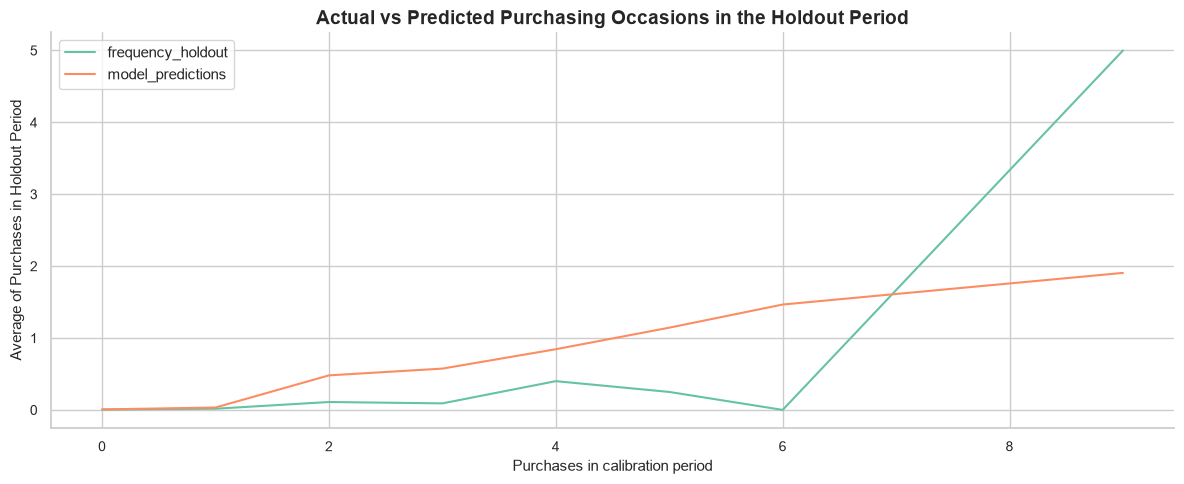

In [118]:
plot_calibration_purchases_vs_holdout_purchases(
    bgf,
    bgf_data.set_index("customer_unique_id"),
    n=10,
    figsize=(12, 5)
)

plt.title(
    "Actual vs Predicted Purchasing Occasions in the Holdout Period"
)
plt.tight_layout()
plt.show()

The calibration-holdout comparison evaluates whether the model reproduces the average future purchasing behaviour associated with different historical frequency levels.

Results for very high calibration frequencies must be interpreted cautiously because only a handful of customers belong to the upper-frequency groups. The low-frequency region is therefore more representative of Olist's actual customer base and should receive greater analytical weight.

## **Gamma-Gamma Model**

The Gamma-Gamma model estimates the expected monetary value of a future transaction. Unlike BG/NBD, it can only be fitted on customers who completed at least one repeat transaction during calibration and therefore have a strictly positive repeat monetary value.

The model assumes that transaction frequency and average transaction value are approximately independent. This assumption is examined before estimation. The resulting expected monetary value is subsequently combined with the BG/NBD purchase forecast to calculate probabilistic 90-day CLTV.

In [119]:
# Select customers eligible for Gamma-Gamma estimation

ggf_data = bgf_data[
    (bgf_data["frequency_cal"] > 0) &
    (bgf_data["monetary_value_cal"] > 0)
].copy()

ggf_coverage_check = pd.DataFrame({
    "metric": [
        "customers in complete BG/NBD base",
        "customers eligible for Gamma-Gamma",
        "Gamma-Gamma coverage (%)",
        "average calibration frequency among eligible customers",
        "average repeat monetary value"
    ],
    "value": [
        len(bgf_data),
        len(ggf_data),
        len(ggf_data) / len(bgf_data) * 100,
        ggf_data["frequency_cal"].mean(),
        ggf_data["monetary_value_cal"].mean()
    ]
})

ggf_coverage_check["value"] = (
    ggf_coverage_check["value"].round(2)
)

ggf_coverage_check

,metric,value
0,customers in complete BG/NBD base,75386.00
1,customers eligible for Gamma-Gamma,1503.00
2,Gamma-Gamma coverage (%),1.99
3,average calibration frequency among eligible c...,1.10
4,average repeat monetary value,149.36


Gamma-Gamma is estimated on the subset of customers with observable repeat purchasing behaviour. This restriction is a mathematical requirement of the model rather than an arbitrary removal of low-value customers.

The coverage table therefore separates the full BG/NBD customer base from the smaller population for which expected transaction value can be estimated directly. This distinction must be preserved throughout the CLTV interpretation.

In [120]:
# Check frequency-monetary independence before fitting Gamma-Gamma

frequency_monetary_corr = (
    ggf_data["frequency_cal"]
    .corr(ggf_data["monetary_value_cal"])
)

print(
    "Correlation between frequency_cal and "
    f"monetary_value_cal: {frequency_monetary_corr:.3f}"
)

Correlation between frequency_cal and monetary_value_cal: 0.005


The correlation between calibration frequency and calibration monetary value is very close to zero. This suggests that the Gamma Gamma indipendence assumption is reasonably satisfied, because customers who purchase more frequently do not systematically show higher or lower average monetary value. For this reason, the Gamma-Gamma model can be used to estimate the expected average monetary value of future transactions.

In [121]:
# Fit Gamma-Gamma on eligible repeat customers

ggf = GammaGammaFitter(penalizer_coef=0.01)

ggf.fit(
    ggf_data["frequency_cal"],
    ggf_data["monetary_value_cal"]
)

ggf.summary

,coef,se(coef),lower 95% bound,upper 95% bound
p,4.123865,0.128430,3.872143,4.375587
q,0.497124,0.015169,0.467392,0.526856
v,3.850448,0.129547,3.596536,4.104361


The fitted Gamma-Gamma model estimates the distribution of customers' latent transaction values while partially shrinking noisy individual averages toward the population-level pattern.

This shrinkage is useful when customers have completed only a small number of repeat transactions, because their raw average monetary value may otherwise be highly unstable.

In [122]:
# Estimate expected average transaction value

ggf_data["expected_avg_monetary_value"] = (
    ggf.conditional_expected_average_profit(
        ggf_data["frequency_cal"],
        ggf_data["monetary_value_cal"]
    )
)

ggf_data[
    [
        "customer_unique_id",
        "frequency_cal",
        "monetary_value_cal",
        "expected_avg_monetary_value"
    ]
].head()

,customer_unique_id,frequency_cal,monetary_value_cal,expected_avg_monetary_value
81,004288347e5e88a27ded2bb23747066c,1.0,103.28,122.008516
322,011575986092c30523ecb71ff10cb473,1.0,80.32,95.859876
335,011b4adcd54683b480c4d841250a987f,1.0,149.88,175.080233
344,012452d40dafae4df401bced74cdb490,1.0,340.07,391.683449
378,013f4353d26bb05dc6652f1269458d8d,1.0,164.04,191.206746


The model-based expected monetary value is generally smoother than the observed repeat monetary value. Individual values are adjusted according to both the customer's transaction history and the overall repeat-customer population.

This expected value is not yet CLTV. It represents the estimated monetary contribution of one future transaction and must be combined with the expected number of future purchases.

## **Probabilistic 90-day CLTV**

The final probabilistic revenue estimate combines the expected number of future transactions produced by BG/NBD with the expected monetary value of each transaction produced by Gamma-Gamma. This integration provides an interpretable customer-level future-value estimate for the subset of customers eligible for both components.

In [123]:
# Calculate probabilistic 90-day CLTV

ggf_data["btyd_cltv_90d"] = (
    ggf.customer_lifetime_value(
        bgf,
        ggf_data["frequency_cal"],
        ggf_data["recency_cal"],
        ggf_data["T_cal"],
        ggf_data["monetary_value_cal"],
        time=3,               # three months
        freq="D",             # calibration variables measured in days
        discount_rate=0.01    # monthly discount rate
    )
)

ggf_data[
    [
        "customer_unique_id",
        "frequency_cal",
        "recency_cal",
        "T_cal",
        "predicted_purchases_90d",
        "probability_alive",
        "expected_avg_monetary_value",
        "btyd_cltv_90d",
        "actual_revenue_90d"
    ]
].head()

,customer_unique_id,frequency_cal,recency_cal,T_cal,predicted_purchases_90d,probability_alive,expected_avg_monetary_value,btyd_cltv_90d,actual_revenue_90d
81,004288347e5e88a27ded2bb23747066c,1.0,171.0,308.0,0.025724,0.107882,122.008516,3.077027,0.0
322,011575986092c30523ecb71ff10cb473,1.0,60.0,103.0,0.064213,0.125011,95.859876,6.035141,0.0
335,011b4adcd54683b480c4d841250a987f,1.0,177.0,282.0,0.030095,0.117649,175.080233,5.165864,0.0
344,012452d40dafae4df401bced74cdb490,1.0,330.0,347.0,0.033537,0.154963,391.683449,12.878367,0.0
378,013f4353d26bb05dc6652f1269458d8d,1.0,4.0,188.0,0.017586,0.050641,191.206746,3.296834,0.0


The predicted CLTV represents discounted expected revenue over the next three months. It combines purchase incidence and transaction value rather than extrapolating historical revenue directly.

The evaluation column `actual_revenue_90d` contains the original realized payment value generated during the holdout period. It is preferred to multiplying holdout frequency by average holdout monetary value because it directly preserves the total revenue observed in the transactional data.

In [124]:
# Evaluate probabilistic CLTV on eligible repeat customers

prob_cltv_mae = mean_absolute_error(
    ggf_data["actual_revenue_90d"],
    ggf_data["btyd_cltv_90d"]
)

prob_cltv_mse = mean_squared_error(
    ggf_data["actual_revenue_90d"],
    ggf_data["btyd_cltv_90d"]
)

prob_cltv_rmse = np.sqrt(prob_cltv_mse)

prob_cltv_r2 = r2_score(
    ggf_data["actual_revenue_90d"],
    ggf_data["btyd_cltv_90d"]
)

prob_cltv_check = pd.DataFrame({
    "metric": [
        "modelled customers",
        "total predicted 90-day CLTV",
        "average predicted 90-day CLTV",
        "median predicted 90-day CLTV",
        "maximum predicted 90-day CLTV",
        "total actual 90-day revenue",
        "MAE",
        "RMSE",
        "R2"
    ],
    "value": [
        len(ggf_data),
        ggf_data["btyd_cltv_90d"].sum(),
        ggf_data["btyd_cltv_90d"].mean(),
        ggf_data["btyd_cltv_90d"].median(),
        ggf_data["btyd_cltv_90d"].max(),
        ggf_data["actual_revenue_90d"].sum(),
        prob_cltv_mae,
        prob_cltv_rmse,
        prob_cltv_r2
    ]
})

prob_cltv_check["value"] = (
    prob_cltv_check["value"].round(2)
)

prob_cltv_check

,metric,value
0,modelled customers,1503.00
1,total predicted 90-day CLTV,18365.77
2,average predicted 90-day CLTV,12.22
3,median predicted 90-day CLTV,3.47
4,maximum predicted 90-day CLTV,675.77
5,total actual 90-day revenue,6289.22
6,MAE,14.78
7,RMSE,54.26
8,R2,-0.48


The probabilistic CLTV model is evaluated on the 1,503 customers eligible for Gamma-Gamma estimation. These results refer only to customers with observable repeat purchasing behaviour and must not be interpreted as a forecast for the complete calibration customer base.

The model predicts approximately R$18,365.77 of 90-day revenue, compared with R$6,289.22 actually realized by these customers. Predicted aggregate value is therefore approximately 2.9 times the observed revenue. The negative R² of −0.48 further indicates weak point-prediction performance and shows that the model does not provide a well-calibrated individual revenue forecast on this holdout sample.

The probabilistic output should consequently be used primarily as a behavioural ranking and prioritization signal rather than as a direct aggregate budget forecast without additional calibration.

In [125]:
# Attach deterministic RFM labels to probabilistic CLTV customers

prob_cltv_segment_data = (
    ggf_data
    .merge(
        rfm_table[
            ["customer_unique_id", "rfm_segment"]
        ],
        on="customer_unique_id",
        how="left"
    )
)

prob_cltv_by_segment = (
    prob_cltv_segment_data
    .groupby("rfm_segment")
    .agg(
        n_customers=("customer_unique_id", "nunique"),
        avg_predicted_cltv_90d=("btyd_cltv_90d", "mean"),
        median_predicted_cltv_90d=("btyd_cltv_90d", "median"),
        total_predicted_cltv_90d=("btyd_cltv_90d", "sum"),
        avg_probability_alive=("probability_alive", "mean"),
        avg_expected_purchases_90d=(
            "predicted_purchases_90d",
            "mean"
        )
    )
    .round(2)
    .reset_index()
)

prob_cltv_by_segment["predicted_value_share_pct"] = (
    prob_cltv_by_segment["total_predicted_cltv_90d"]
    / prob_cltv_by_segment["total_predicted_cltv_90d"].sum()
    * 100
).round(2)

prob_cltv_by_segment = (
    prob_cltv_by_segment
    .sort_values(
        "total_predicted_cltv_90d",
        ascending=False
    )
)

prob_cltv_by_segment

,rfm_segment,n_customers,avg_predicted_cltv_90d,median_predicted_cltv_90d,total_predicted_cltv_90d,avg_probability_alive,avg_expected_purchases_90d,predicted_value_share_pct
1,Repeat Champions,623,21.85,7.90,13612.99,0.21,0.12,74.12
2,Repeat Loyal,441,6.24,2.56,2750.11,0.12,0.05,14.97
0,Repeat At Risk,439,4.56,1.35,2002.66,0.08,0.03,10.90


The segment-level analysis shows that predicted probabilistic CLTV is strongly concentrated among Repeat Champions. This group accounts for approximately 74% of the predicted value generated by the modelled repeat-customer population.

This result is coherent with the logic of the probabilistic model: customers with stronger repeated purchase behavior, higher probability alive and hgiher expected future purchases receive higher predicted CLTV. From a marketing perspective, Repeat Champions are the most valuable group to protect, while Repeat At Risk customers represent a smaller but strategically relevant retention segment.

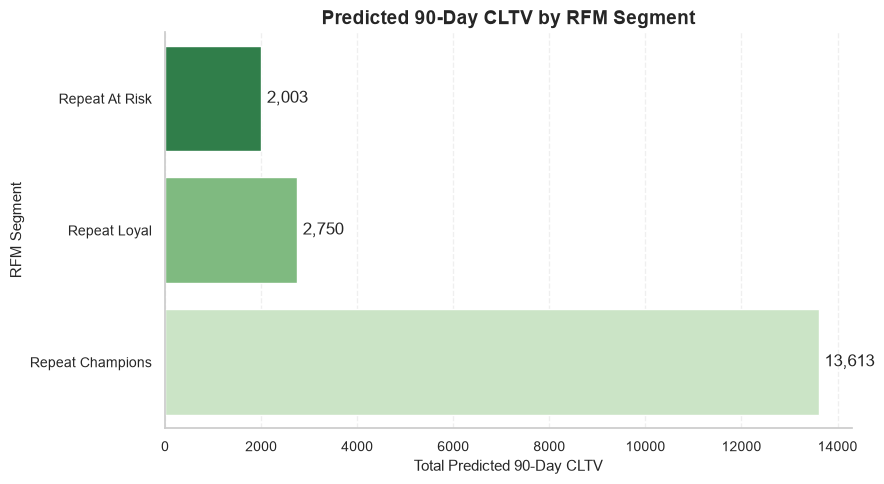

In [126]:
plt.figure(figsize=(9, 5))

segment_cltv_plot = prob_cltv_by_segment.sort_values(
    "total_predicted_cltv_90d",
    ascending=True
)

ax = sns.barplot(
    data=segment_cltv_plot,
    x="total_predicted_cltv_90d",
    y="rfm_segment",
    hue="rfm_segment",
    palette="Greens_r",
    legend=False
)

add_horizontal_bar_labels(ax, fmt="{:,.0f}", padding=4)

plt.title("Predicted 90-Day CLTV by RFM Segment")
plt.xlabel("Total Predicted 90-Day CLTV")
plt.ylabel("RFM Segment")
plt.grid(axis="x", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

The segment-level comparison connects deterministic RFM interpretation with probabilistic future-value estimation. Repeat-oriented segments with stronger recency, frequency and monetary profiles are expected to concentrate the largest share of predicted CLTV.

The results should not be generalized to all calibration customers, because Gamma-Gamma CLTV is available only for customers with observable repeat purchasing behaviour. The table is therefore a prioritization framework within the repeat-customer population.

In [127]:
# Create predicted CLTV deciles among eligible repeat customers

prob_cltv_segment_data["cltv_decile"] = pd.qcut(
    prob_cltv_segment_data["btyd_cltv_90d"].rank(
        method="first"
    ),
    q=10,
    labels=list(range(1, 11))
).astype(int)

cltv_decile_analysis = (
    prob_cltv_segment_data
    .groupby("cltv_decile")
    .agg(
        n_customers=("customer_unique_id", "nunique"),
        avg_predicted_cltv_90d=("btyd_cltv_90d", "mean"),
        total_predicted_cltv_90d=("btyd_cltv_90d", "sum"),
        avg_probability_alive=("probability_alive", "mean"),
        avg_expected_purchases_90d=(
            "predicted_purchases_90d",
            "mean"
        )
    )
    .round(2)
    .reset_index()
)

cltv_decile_analysis["value_share_pct"] = (
    cltv_decile_analysis["total_predicted_cltv_90d"]
    / cltv_decile_analysis["total_predicted_cltv_90d"].sum()
    * 100
).round(2)

cltv_decile_analysis

,cltv_decile,n_customers,avg_predicted_cltv_90d,total_predicted_cltv_90d,avg_probability_alive,avg_expected_purchases_90d,value_share_pct
0,1,151,0.56,84.93,0.05,0.01,0.46
1,2,150,1.10,165.24,0.07,0.02,0.90
2,3,150,1.59,237.83,0.08,0.02,1.29
3,4,150,2.20,329.98,0.09,0.02,1.80
4,5,151,3.00,453.33,0.10,0.03,2.47
5,6,150,4.13,619.12,0.10,0.04,3.37
6,7,150,5.57,834.86,0.11,0.04,4.55
7,8,150,8.27,1240.47,0.12,0.05,6.75
8,9,150,15.19,2278.43,0.16,0.08,12.41
9,10,151,80.28,12121.58,0.59,0.42,66.00


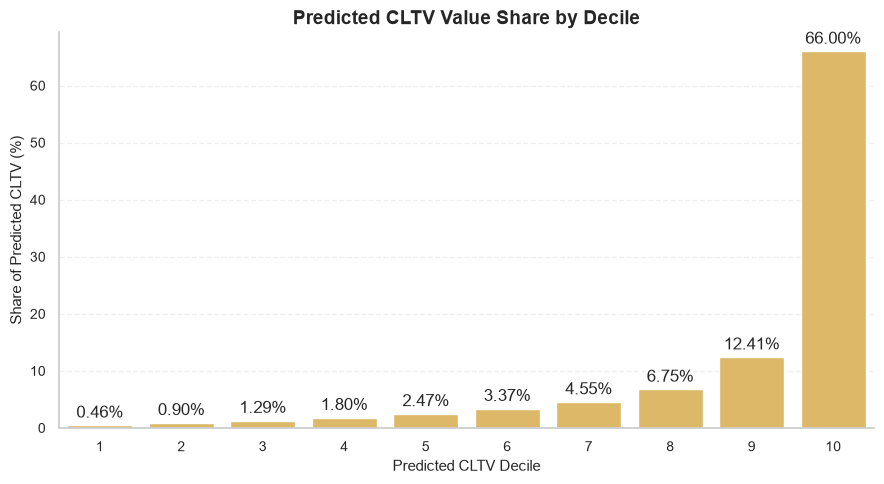

In [128]:
plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=cltv_decile_analysis,
    x="cltv_decile",
    y="value_share_pct",
    color="#F0BF54"
)

add_bar_labels(ax, fmt="{:.2f}%")

plt.title("Predicted CLTV Value Share by Decile")
plt.xlabel("Predicted CLTV Decile")
plt.ylabel("Share of Predicted CLTV (%)")
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

The decile analysis measures how strongly predicted future value is concentrated within the repeat-customer ranking. Higher deciles combine stronger expected purchasing activity, higher survival probability and larger expected transaction value.

A pronounced concentration in the upper deciles supports differentiated marketing investment. Higher-cost retention or loyalty actions can be reserved for customers with the strongest expected value, while lower-ranked customers can receive less expensive automated communication.

## **Machine Learning Regression Approach**

The probabilistic BTYD framework provides behaviourally interpretable purchase and monetary models, but Gamma-Gamma CLTV is only available for repeat customers. A supervised machine learning approach is therefore developed to estimate 90-day revenue for the complete calibration customer base.

All predictors are constructed exclusively from information available before the calibration boundary. The target is the original revenue realized during the subsequent 90-day holdout period, preventing temporal leakage between feature construction and model evaluation.

In [129]:
# Build customer-level ML features from calibration period only

ml_orders = calibration_orders.copy()

# Make sure date columns are datetime
date_cols_ml = [
    "order_purchase_timestamp",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_cols_ml:
    if col in ml_orders.columns:
        ml_orders[col] = pd.to_datetime(ml_orders[col], errors="coerce")

# Use capped monetary value if available, otherwise raw payment value
value_col = "payment_value_capped" if "payment_value_capped" in ml_orders.columns else "payment_value"

# Delivery experience features
ml_orders["delivery_time_days"] = (
    ml_orders["order_delivered_customer_date"] - ml_orders["order_purchase_timestamp"]
).dt.days

ml_orders["delivery_delay_days"] = (
    ml_orders["order_delivered_customer_date"] - ml_orders["order_estimated_delivery_date"]
).dt.days

ml_orders["late_delivery"] = (ml_orders["delivery_delay_days"] > 0).astype(int)

# Freight intensity
ml_orders["freight_ratio"] = (
    ml_orders["freight_value"] / ml_orders[value_col].replace(0, np.nan)
)

# Robust mode function for categorical aggregation
def mode_or_unknown(x):
    mode_values = x.dropna().mode()
    if len(mode_values) == 0:
        return "unknown"
    return mode_values.iloc[0]

ml_customer_features = (
    ml_orders
    .groupby("customer_unique_id")
    .agg(
        # Customer / purchase behavior
        customer_state=("customer_state", mode_or_unknown),
        n_orders=("order_id", "nunique"),
        total_revenue_cal=(value_col, "sum"),
        avg_order_value_cal=(value_col, "mean"),
        max_order_value_cal=(value_col, "max"),
        recency_days=("order_purchase_timestamp", lambda x: (calibration_end - x.max()).days),
        tenure_days=("order_purchase_timestamp", lambda x: (calibration_end - x.min()).days),
        
        # Product features
        n_items=("n_items", "sum"),
        n_unique_products=("n_unique_products", "sum"),
        n_unique_categories=("main_product_category", "nunique"),
        main_product_category=("main_product_category", mode_or_unknown),
        avg_item_price=("avg_item_price", "mean"),
        max_item_price=("max_item_price", "max"),
        
        # Review features
        avg_review_score=("review_score", "mean"),
        review_missing_rate=("review_score", lambda x: x.isna().mean()),
        
        # Delivery / logistics features
        avg_delivery_time_days=("delivery_time_days", "mean"),
        avg_delivery_delay_days=("delivery_delay_days", "mean"),
        late_delivery_rate=("late_delivery", "mean"),
        avg_freight_value=("freight_value", "mean"),
        avg_freight_ratio=("freight_ratio", "mean")
    )
    .reset_index()
)

# Replace infinite ratios with missing values
# to be handled by the preprocessing pipeline
ml_customer_features = (
    ml_customer_features
    .replace([np.inf, -np.inf], np.nan)
)

assert ml_customer_features[
    "customer_unique_id"
].is_unique


ml_customer_features.head()

,customer_unique_id,customer_state,n_orders,total_revenue_cal,avg_order_value_cal,max_order_value_cal,recency_days,tenure_days,n_items,n_unique_products,n_unique_categories,main_product_category,avg_item_price,max_item_price,avg_review_score,review_missing_rate,avg_delivery_time_days,avg_delivery_delay_days,late_delivery_rate,avg_freight_value,avg_freight_ratio
0,0000366f3b9a7992bf8c76cfdf3221e2,SP,1,141.90,141.90,141.90,21,21,1,1,1,bed_bath_table,129.90,129.90,5.0,0.0,6.0,-5.0,0.0,12.00,0.084567
1,0000b849f77a49e4a4ce2b2a4ca5be3f,SP,1,27.19,27.19,27.19,24,24,1,1,1,health_beauty,18.90,18.90,4.0,0.0,3.0,-5.0,0.0,8.29,0.304892
2,0000f46a3911fa3c0805444483337064,SC,1,86.22,86.22,86.22,447,447,1,1,1,stationery,69.00,69.00,3.0,0.0,25.0,-2.0,0.0,17.22,0.199722
3,0000f6ccb0745a6a4b88665a16c9f078,PA,1,43.62,43.62,43.62,231,231,1,1,1,telephony,25.99,25.99,4.0,0.0,20.0,-12.0,0.0,17.63,0.404172
4,0004aac84e0df4da2b147fca70cf8255,SP,1,196.89,196.89,196.89,198,198,1,1,1,telephony,180.00,180.00,5.0,0.0,13.0,-8.0,0.0,16.89,0.085784


The resulting table contains one row per customer and combines purchasing behaviour, product breadth, review information and delivery experience observed during calibration.

Revenue-related predictors use capped values to reduce sensitivity to extreme calibration orders, while the holdout target retains original revenue. No variable derived from future transactions is included among the predictors.

In [130]:
# Attach 90-day holdout target

ml_dataset = (
    ml_customer_features
    .merge(
        customer_target[
            [
                "customer_unique_id",
                "target_revenue_90d",
                "target_orders_90d",
                "repurchased_in_holdout"
            ]
        ],
        on="customer_unique_id",
        how="left"
    )
)

ml_dataset["target_revenue_90d"] = ml_dataset["target_revenue_90d"].fillna(0)
ml_dataset["target_orders_90d"] = ml_dataset["target_orders_90d"].fillna(0)
ml_dataset["repurchased_in_holdout"] = ml_dataset["repurchased_in_holdout"].fillna(0).astype(int)

ml_target_check = pd.DataFrame({
    "metric": [
        "customers in ML dataset",
        "customers with holdout revenue",
        "share with holdout revenue (%)",
        "total target revenue",
        "average target revenue",
        "median target revenue"
    ],
    "value": [
        len(ml_dataset),
        (ml_dataset["target_revenue_90d"] > 0).sum(),
        (ml_dataset["target_revenue_90d"] > 0).mean() * 100,
        ml_dataset["target_revenue_90d"].sum(),
        ml_dataset["target_revenue_90d"].mean(),
        ml_dataset["target_revenue_90d"].median()
    ]
})

ml_target_check["value"] = ml_target_check["value"].round(2)
ml_target_check

,metric,value
0,customers in ML dataset,75386.00
1,customers with holdout revenue,419.00
2,share with holdout revenue (%),0.56
3,total target revenue,66978.67
4,average target revenue,0.89
5,median target revenue,0.00


The machine learning dataset contains all customers observed during calibration. Only 419 customers generate positive revenue during the holdout period, corresponding to approximately 0.56% of the population.

The target is therefore strongly zero-inflated and right-skewed. The logarithmic transformation reduces the influence of extreme positive revenue values, while the binary indicator is used only to preserve the rare positive cases during the train-test split.

In [131]:
# Optional XGBoost import
try:
    from xgboost import XGBRegressor
    xgboost_available = True
except ImportError:
    xgboost_available = False


# Define the original and logarithmic targets

y = ml_dataset["target_revenue_90d"].copy()
y_log = np.log1p(y)


# Indicator used only to preserve rare positive-revenue customers
# during the train-test split

ml_dataset["target_has_revenue"] = (
    ml_dataset["target_revenue_90d"] > 0
).astype(int)


# Define predictors constructed exclusively from calibration data

feature_cols = [
    "customer_state",
    "n_orders",
    "total_revenue_cal",
    "avg_order_value_cal",
    "max_order_value_cal",
    "recency_days",
    "tenure_days",
    "n_items",
    "n_unique_products",
    "n_unique_categories",
    "main_product_category",
    "avg_item_price",
    "max_item_price",
    "avg_review_score",
    "review_missing_rate",
    "avg_delivery_time_days",
    "avg_delivery_delay_days",
    "late_delivery_rate",
    "avg_freight_value",
    "avg_freight_ratio"
]

X = ml_dataset[feature_cols].copy()


# Split customer indices once
# so that all later models use exactly the same customers

train_index, test_index = train_test_split(
    ml_dataset.index,
    test_size=0.20,
    random_state=42,
    stratify=ml_dataset["target_has_revenue"]
)


# Apply the same indices to predictors and targets

X_train = X.loc[train_index]
X_test = X.loc[test_index]

y_train_log = y_log.loc[train_index]
y_test_log = y_log.loc[test_index]

y_train = y.loc[train_index]
y_test = y.loc[test_index]


# Verify that rare positive-revenue customers
# are preserved in both partitions

split_target_check = pd.DataFrame({
    "sample": ["Training", "Test"],
    "n_customers": [
        len(train_index),
        len(test_index)
    ],
    "positive_revenue_customers": [
        int((y_train > 0).sum()),
        int((y_test > 0).sum())
    ],
    "positive_revenue_rate_pct": [
        (y_train > 0).mean() * 100,
        (y_test > 0).mean() * 100
    ]
})

split_target_check["positive_revenue_rate_pct"] = (
    split_target_check["positive_revenue_rate_pct"]
    .round(2)
)

split_target_check

,sample,n_customers,positive_revenue_customers,positive_revenue_rate_pct
0,Training,60308,335,0.56
1,Test,15078,84,0.56


The stratified split preserves the extremely low positive-revenue rate in both training and test data. The test set remains completely untouched during model fitting, preprocessing selection and hyperparameter tuning.

The same customer indices are retained for the pure machine learning and hybrid models, enabling a direct comparison under identical evaluation conditions.

In [132]:
# Identify numerical and categorical predictors robustly

numeric_features = (
    X.select_dtypes(include=[np.number])
    .columns
    .tolist()
)

categorical_features = (
    X.select_dtypes(exclude=[np.number])
    .columns
    .tolist()
)


# Create a version-compatible one-hot encoder

try:
    one_hot_encoder = OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    )
except TypeError:
    one_hot_encoder = OneHotEncoder(
        handle_unknown="ignore",
        sparse=False
    )


# Numerical preprocessing:
# median imputation followed by standardization

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])


# Categorical preprocessing:
# mode imputation followed by one-hot encoding

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", one_hot_encoder)
])


# Combine numerical and categorical preprocessing branches

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numeric_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)


# Inspect the composition of the feature set

preprocessing_check = pd.DataFrame({
    "feature_type": [
        "Numerical features",
        "Categorical features",
        "Total original features"
    ],
    "n_features": [
        len(numeric_features),
        len(categorical_features),
        len(feature_cols)
    ]
})

preprocessing_check

,feature_type,n_features
0,Numerical features,18
1,Categorical features,2
2,Total original features,20


Three supervised regression models are compared. A mean Dummy Regressor provides a reference baseline, while Random Forest and XGBoost represent non-linear tree-based alternatives capable of learning interactions among behavioural, product and service variables.

All models are trained on the logarithm of 90-day revenue to reduce the influence of the small number of extreme positive outcomes. Predictions are subsequently transformed back to the original revenue scale for evaluation and marketing interpretation.

Hyperparameter selection is performed exclusively within the training data through three-fold cross-validation. The untouched test set is used only for the final comparison.

In [133]:
def evaluate_regression_model(
    model_name,
    fitted_pipeline,
    X_test_data,
    y_test_data
):
    """
    Evaluate a regression model trained on log-transformed revenue.

    Predictions are transformed back to the original revenue scale.
    The function reports conventional regression metrics together with
    top-decile value capture, which measures customer-ranking quality.
    """

    # Predict logarithmic revenue
    y_pred_log = fitted_pipeline.predict(X_test_data)

    # Return predictions to the original revenue scale
    y_pred = np.expm1(y_pred_log)

    # Revenue cannot be negative
    y_pred = np.clip(y_pred, 0, None)

    prediction_df = pd.DataFrame({
        "customer_unique_id": ml_dataset.loc[
            X_test_data.index,
            "customer_unique_id"
        ].values,
        "actual_revenue": y_test_data.values,
        "predicted_revenue": y_pred
    })

    # Conventional regression metrics
    mae = mean_absolute_error(
        prediction_df["actual_revenue"],
        prediction_df["predicted_revenue"]
    )

    mse = mean_squared_error(
        prediction_df["actual_revenue"],
        prediction_df["predicted_revenue"]
    )

    rmse = np.sqrt(mse)

    r2 = r2_score(
        prediction_df["actual_revenue"],
        prediction_df["predicted_revenue"]
    )

    # Select exactly the highest-ranked 10% of test customers
    n_top = max(
        1,
        int(np.ceil(len(prediction_df) * 0.10))
    )

    top_decile_actual_revenue = (
        prediction_df
        .nlargest(n_top, "predicted_revenue")
        ["actual_revenue"]
        .sum()
    )

    total_actual_revenue = (
        prediction_df["actual_revenue"].sum()
    )

    top_decile_capture = (
        top_decile_actual_revenue
        / total_actual_revenue
        * 100
        if total_actual_revenue > 0
        else np.nan
    )

    result = {
        "model": model_name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2,
        "top_decile_value_capture_pct": top_decile_capture,
        "total_predicted_revenue": (
            prediction_df["predicted_revenue"].sum()
        ),
        "total_actual_revenue": total_actual_revenue
    }

    return result, prediction_df

In [134]:
# Baseline model:
# predicts the average logarithmic revenue

baseline_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", DummyRegressor(strategy="mean"))
])


# Random Forest regression pipeline

rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    (
        "model",
        RandomForestRegressor(
            random_state=42,
            n_jobs=-1
        )
    )
])


# Random Forest hyperparameter grid

rf_params = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [5, 10, None],
    "model__min_samples_leaf": [1, 5]
}


rf_grid = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_params,
    cv=3,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)


# Optional XGBoost regression pipeline

if xgboost_available:

    xgb_pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            XGBRegressor(
                objective="reg:squarederror",
                random_state=42,
                n_jobs=-1
            )
        )
    ])

    xgb_params = {
        "model__n_estimators": [100, 200],
        "model__max_depth": [3, 5],
        "model__learning_rate": [0.05, 0.10],
        "model__subsample": [0.8, 1.0],
        "model__colsample_bytree": [0.8, 1.0]
    }

    xgb_grid = GridSearchCV(
        estimator=xgb_pipeline,
        param_grid=xgb_params,
        cv=3,
        scoring="neg_mean_squared_error",
        n_jobs=-1
    )

In [135]:
# Containers for model results, predictions
# and fitted pipelines

ml_results = []
ml_predictions = {}
ml_fitted_models = {}


# Baseline

baseline_pipeline.fit(
    X_train,
    y_train_log
)

baseline_result, baseline_prediction_df = (
    evaluate_regression_model(
        "Baseline Mean",
        baseline_pipeline,
        X_test,
        y_test
    )
)

ml_results.append(baseline_result)

ml_predictions["Baseline Mean"] = (
    baseline_prediction_df
)

ml_fitted_models["Baseline Mean"] = (
    baseline_pipeline
)


# Random Forest

rf_grid.fit(
    X_train,
    y_train_log
)

print("Best Random Forest parameters:")
print(rf_grid.best_params_)

rf_result, rf_prediction_df = (
    evaluate_regression_model(
        "Random Forest",
        rf_grid.best_estimator_,
        X_test,
        y_test
    )
)

ml_results.append(rf_result)

ml_predictions["Random Forest"] = (
    rf_prediction_df
)

ml_fitted_models["Random Forest"] = (
    rf_grid.best_estimator_
)


# XGBoost

if xgboost_available:

    xgb_grid.fit(
        X_train,
        y_train_log
    )

    print("\nBest XGBoost parameters:")
    print(xgb_grid.best_params_)

    xgb_result, xgb_prediction_df = (
        evaluate_regression_model(
            "XGBoost",
            xgb_grid.best_estimator_,
            X_test,
            y_test
        )
    )

    ml_results.append(xgb_result)

    ml_predictions["XGBoost"] = (
        xgb_prediction_df
    )

    ml_fitted_models["XGBoost"] = (
        xgb_grid.best_estimator_
    )


# Create the final comparison table

ml_results_df = (
    pd.DataFrame(ml_results)
    .sort_values(
        ["RMSE", "MAE"],
        ascending=True
    )
    .reset_index(drop=True)
    .round(4)
)

ml_results_df

Best Random Forest parameters:
{'model__max_depth': 5, 'model__min_samples_leaf': 1, 'model__n_estimators': 100}

Best XGBoost parameters:
{'model__colsample_bytree': 0.8, 'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 100, 'model__subsample': 1.0}


,model,MAE,MSE,RMSE,R2,top_decile_value_capture_pct,total_predicted_revenue,total_actual_revenue
0,XGBoost,0.9601,404.8210,20.1202,-0.0019,30.2187,452.8139,14031.33
1,Baseline Mean,0.9569,404.8613,20.1212,-0.0020,6.5335,401.9368,14031.33
2,Random Forest,0.9615,404.9831,20.1242,-0.0023,29.2528,475.8850,14031.33


The three supervised models produce almost identical conventional regression errors. XGBoost achieves the lowest RMSE among the machine learning models at 20.1202, but the improvement over the mean baseline, whose RMSE is 20.1212, is negligible. All R² values remain slightly negative, indicating that none of the models explains holdout revenue variation better than a constant prediction in a practically meaningful way.

The ranking results are more informative for marketing allocation. XGBoost captures 30.22% of the realized test revenue within the top predicted customer decile, while Random Forest captures 29.25%. Both substantially outperform the baseline, whose top decile captures only 6.53% of realized revenue.

However, the predicted aggregate revenue remains severely underestimated. XGBoost predicts approximately 452.81 monetary units and Random Forest 475.89, compared with 14,031.33 actually observed in the test period. The models should therefore be interpreted primarily as customer-prioritization tools rather than calibrated revenue-forecasting systems. In this highly zero-inflated setting, top-decile value capture provides a more operationally useful signal than R² alone.

## **Hybrid BTYD + ML Model**

The hybrid approach integrates the behavioural signals estimated by the probabilistic BTYD framework into the supervised machine learning dataset. Predicted purchase frequency, probability of remaining active and BTYD-based 90-day CLTV are treated as additional customer-level predictors.

This combination is intended to test whether structured probabilistic information provides incremental predictive value beyond the transactional, product and delivery features already used by the machine learning models.

Because the BTYD monetary model is available only for eligible repeat customers, an availability indicator is retained. Missing BTYD signals are encoded as zero only after this indicator has been created, allowing the models to distinguish an unavailable estimate from an observed low value.

In [165]:
# BG/NBD signals are available for the complete calibration customer base
bgf_signals = (
    bgf_data[
        [
            "customer_unique_id",
            "predicted_purchases_90d",
            "probability_alive"
        ]
    ]
    .drop_duplicates(subset="customer_unique_id")
    .copy()
)

# Gamma-Gamma CLTV is available only for eligible repeat customers
ggf_signals = (
    ggf_data[
        [
            "customer_unique_id",
            "btyd_cltv_90d"
        ]
    ]
    .drop_duplicates(subset="customer_unique_id")
    .copy()
)

# Merge the complete BG/NBD signals and the restricted Gamma-Gamma CLTV
hybrid_dataset = (
    ml_dataset
    .merge(
        bgf_signals,
        on="customer_unique_id",
        how="left"
    )
    .merge(
        ggf_signals,
        on="customer_unique_id",
        how="left"
    )
)

# Preserve the existing variable name to avoid changing downstream code
hybrid_dataset["btyd_signal_available"] = (
    hybrid_dataset["btyd_cltv_90d"].notna().astype(int)
)

# Only Gamma-Gamma CLTV requires a placeholder
hybrid_dataset["btyd_cltv_90d"] = (
    hybrid_dataset["btyd_cltv_90d"].fillna(0)
)

# Defensive checks: BG/NBD signals should cover the full customer base
assert hybrid_dataset["predicted_purchases_90d"].notna().all()
assert hybrid_dataset["probability_alive"].notna().all()

# Verify one row per calibration customer
assert len(hybrid_dataset) == len(ml_dataset)
assert hybrid_dataset["customer_unique_id"].is_unique

The hybrid dataset preserves all 75,386 calibration customers. BG/NBD predicted purchases and probability-alive signals are available for the complete customer base, while Gamma-Gamma-based CLTV is available for 1,503 customers, corresponding to 1.99% of the population.

The btyd_signal_available indicator therefore identifies the customers for whom the Gamma-Gamma monetary component can be estimated. Zero-filled btyd_cltv_90d values are placeholders for non-eligible customers and must not be interpreted as genuine predicted zero future value.

In [166]:
# Define the hybrid feature set:
# original machine learning predictors plus BTYD signals

hybrid_feature_cols = feature_cols + [
    "predicted_purchases_90d",
    "probability_alive",
    "btyd_cltv_90d",
    "btyd_signal_available"
]

X_hybrid = hybrid_dataset[
    hybrid_feature_cols
].copy()


# Apply exactly the same train-test customer indices
# used by the pure machine learning models

X_train_hybrid = X_hybrid.loc[train_index]
X_test_hybrid = X_hybrid.loc[test_index]


# Identify numerical and categorical features robustly

numeric_features_hybrid = (
    X_hybrid
    .select_dtypes(include=[np.number])
    .columns
    .tolist()
)

categorical_features_hybrid = (
    X_hybrid
    .select_dtypes(exclude=[np.number])
    .columns
    .tolist()
)


# Create a version-compatible one-hot encoder

try:
    one_hot_encoder_hybrid = OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    )
except TypeError:
    one_hot_encoder_hybrid = OneHotEncoder(
        handle_unknown="ignore",
        sparse=False
    )


# Numerical preprocessing

numeric_transformer_hybrid = Pipeline(steps=[
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    )
])


# Categorical preprocessing

categorical_transformer_hybrid = Pipeline(steps=[
    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    ),
    (
        "onehot",
        one_hot_encoder_hybrid
    )
])


# Combine preprocessing branches

hybrid_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer_hybrid,
            numeric_features_hybrid
        ),
        (
            "cat",
            categorical_transformer_hybrid,
            categorical_features_hybrid
        )
    ]
)


# Summarize the hybrid feature space before one-hot encoding

hybrid_feature_check = pd.DataFrame({
    "metric": [
        "number of original ML features",
        "number of BTYD features added",
        "total hybrid features before encoding",
        "numerical hybrid features",
        "categorical hybrid features"
    ],
    "value": [
        len(feature_cols),
        4,
        len(hybrid_feature_cols),
        len(numeric_features_hybrid),
        len(categorical_features_hybrid)
    ]
})

hybrid_feature_check

,metric,value
0,number of original ML features,20
1,number of BTYD features added,4
2,total hybrid features before encoding,24
3,numerical hybrid features,22
4,categorical hybrid features,2


The hybrid specification expands the original 20-feature machine learning dataset with four BTYD-derived variables, producing 24 predictors before categorical encoding.

The additional variables include three continuous probabilistic outputs and one binary availability indicator. As a result, the hybrid dataset contains 22 numerical variables and two categorical variables.

The use of identical training and test customer indices ensures that any difference between the pure and hybrid models is attributable to the additional BTYD information rather than to a different sample composition.

The same tree-based model families and hyperparameter grids used in the pure machine learning analysis are applied to the hybrid feature space. This controlled design makes it possible to isolate the incremental contribution of the BTYD variables.

Hyperparameter tuning is performed exclusively on the hybrid training partition through three-fold cross-validation. The original revenue test target remains untouched until final evaluation.

In [167]:
# Hybrid Random Forest pipeline

hybrid_rf_pipeline = Pipeline(steps=[
    (
        "preprocessor",
        hybrid_preprocessor
    ),
    (
        "model",
        RandomForestRegressor(
            random_state=42,
            n_jobs=-1
        )
    )
])


# Hyperparameter grid aligned with the pure Random Forest model

hybrid_rf_params = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [5, 10, None],
    "model__min_samples_leaf": [1, 5]
}


hybrid_rf_grid = GridSearchCV(
    estimator=hybrid_rf_pipeline,
    param_grid=hybrid_rf_params,
    cv=3,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)


# Optional Hybrid XGBoost pipeline

if xgboost_available:

    hybrid_xgb_pipeline = Pipeline(steps=[
        (
            "preprocessor",
            hybrid_preprocessor
        ),
        (
            "model",
            XGBRegressor(
                objective="reg:squarederror",
                random_state=42,
                n_jobs=-1
            )
        )
    ])

    hybrid_xgb_params = {
        "model__n_estimators": [100, 200],
        "model__max_depth": [3, 5],
        "model__learning_rate": [0.05, 0.10],
        "model__subsample": [0.8, 1.0],
        "model__colsample_bytree": [0.8, 1.0]
    }

    hybrid_xgb_grid = GridSearchCV(
        estimator=hybrid_xgb_pipeline,
        param_grid=hybrid_xgb_params,
        cv=3,
        scoring="neg_mean_squared_error",
        n_jobs=-1
    )

In [168]:
# Containers for hybrid results, predictions
# and fitted model pipelines

hybrid_results = []
hybrid_predictions = {}
hybrid_fitted_models = {}

# Hybrid Random Forest

hybrid_rf_grid.fit(
    X_train_hybrid,
    y_train_log
)

print("Best Hybrid Random Forest parameters:")
print(hybrid_rf_grid.best_params_)

hybrid_rf_result, hybrid_rf_prediction_df = (
    evaluate_regression_model(
        "Hybrid Random Forest",
        hybrid_rf_grid.best_estimator_,
        X_test_hybrid,
        y_test
    )
)

hybrid_results.append(
    hybrid_rf_result
)

hybrid_predictions[
    "Hybrid Random Forest"
] = hybrid_rf_prediction_df

hybrid_fitted_models[
    "Hybrid Random Forest"
] = hybrid_rf_grid.best_estimator_


# Hybrid XGBoost

if xgboost_available:

    hybrid_xgb_grid.fit(
        X_train_hybrid,
        y_train_log
    )

    print("\nBest Hybrid XGBoost parameters:")
    print(hybrid_xgb_grid.best_params_)

    hybrid_xgb_result, hybrid_xgb_prediction_df = (
        evaluate_regression_model(
            "Hybrid XGBoost",
            hybrid_xgb_grid.best_estimator_,
            X_test_hybrid,
            y_test
        )
    )

    hybrid_results.append(
        hybrid_xgb_result
    )

    hybrid_predictions[
        "Hybrid XGBoost"
    ] = hybrid_xgb_prediction_df

    hybrid_fitted_models[
        "Hybrid XGBoost"
    ] = hybrid_xgb_grid.best_estimator_


# Create the hybrid comparison table

hybrid_results_df = (
    pd.DataFrame(hybrid_results)
    .sort_values(
        ["RMSE", "MAE"],
        ascending=True
    )
    .reset_index(drop=True)
    .round(4)
)

hybrid_results_df

Best Hybrid Random Forest parameters:
{'model__max_depth': 5, 'model__min_samples_leaf': 5, 'model__n_estimators': 200}

Best Hybrid XGBoost parameters:
{'model__colsample_bytree': 0.8, 'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 100, 'model__subsample': 1.0}


,model,MAE,MSE,RMSE,R2,top_decile_value_capture_pct,total_predicted_revenue,total_actual_revenue
0,Hybrid Random Forest,0.9571,404.7441,20.1183,-0.0017,30.4310,409.7284,14031.33
1,Hybrid XGBoost,0.9585,404.7475,20.1183,-0.0017,31.7377,431.3658,14031.33


Hybrid Random Forest obtains the lowest conventional test error, with an RMSE of 20.1178, followed closely by Hybrid XGBoost at 20.1190. The differences from the pure machine learning models remain numerically very small, and all R² values are still negative.

Hybrid XGBoost achieves the strongest ranking result, capturing 30.72% of realized test revenue within the highest predicted decile. It slightly outperforms pure XGBoost at 30.22%, while Hybrid Random Forest captures 29.82%.

The corrected hybrid specification makes BG/NBD predicted purchases and probability-alive signals available for the complete customer base. Gamma-Gamma-based CLTV remains available only for approximately 1.99% of customers. The hybrid approach therefore provides a small improvement in ranking, but not a reliable individual-level revenue forecast.

## **Model Evaluation and Comparison**

The final evaluation compares the probabilistic BTYD prediction, the pure machine learning models and the hybrid models on the same test customers and against the same original 90-day revenue target.

For customers who are not eligible for BTYD estimation, the operational BTYD prediction is set to zero. The resulting BTYD row must therefore be interpreted as a full-customer-base deployment benchmark rather than as a pure evaluation of the model within its eligible repeat-customer population.

Conventional regression metrics are considered together with top-decile value capture and aggregate predicted revenue. This distinction is important because the business objective is not limited to precise individual revenue estimation but also includes identifying customers on whom marketing resources should be concentrated.

In [169]:
# Operational BTYD prediction on the same test customers

btyd_test_prediction_df = (
    hybrid_dataset
    .loc[
        test_index,
        [
            "customer_unique_id",
            "target_revenue_90d",
            "btyd_cltv_90d",
            "btyd_signal_available"
        ]
    ]
    .rename(
        columns={
            "target_revenue_90d": "actual_revenue",
            "btyd_cltv_90d": "predicted_revenue"
        }
    )
    .copy()
)


# BTYD predictions are already zero outside the eligible population

btyd_test_prediction_df["predicted_revenue"] = (
    btyd_test_prediction_df["predicted_revenue"]
    .clip(lower=0)
)


# Evaluate any precomputed prediction table
# using the same metrics applied to the ML models

def evaluate_prediction_dataframe(
    model_name,
    prediction_df
):
    actuals = prediction_df["actual_revenue"]
    predicted = prediction_df["predicted_revenue"]

    mae = mean_absolute_error(
        actuals,
        predicted
    )

    mse = mean_squared_error(
        actuals,
        predicted
    )

    rmse = np.sqrt(mse)

    r2 = r2_score(
        actuals,
        predicted
    )

    n_top = max(
        1,
        int(np.ceil(len(prediction_df) * 0.10))
    )

    top_decile_actual_revenue = (
        prediction_df
        .nlargest(
            n_top,
            "predicted_revenue"
        )
        ["actual_revenue"]
        .sum()
    )

    total_actual_revenue = actuals.sum()

    top_decile_capture = (
        top_decile_actual_revenue
        / total_actual_revenue
        * 100
        if total_actual_revenue > 0
        else np.nan
    )

    return {
        "model": model_name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2,
        "top_decile_value_capture_pct": top_decile_capture,
        "total_predicted_revenue": predicted.sum(),
        "total_actual_revenue": actuals.sum()
    }


btyd_test_result = evaluate_prediction_dataframe(
    "BTYD - Full Base",
    btyd_test_prediction_df
)


# Verify BTYD test-set coverage

btyd_test_coverage = pd.DataFrame({
    "metric": [
        "test customers",
        "test customers with BTYD signal",
        "BTYD test coverage (%)"
    ],
    "value": [
        len(btyd_test_prediction_df),
        btyd_test_prediction_df[
            "btyd_signal_available"
        ].sum(),
        btyd_test_prediction_df[
            "btyd_signal_available"
        ].mean() * 100
    ]
})

btyd_test_coverage["value"] = (
    btyd_test_coverage["value"]
    .round(2)
)

display(btyd_test_coverage)


# Combine all final model results

model_comparison_df = (
    pd.concat(
        [
            pd.DataFrame([btyd_test_result]),
            pd.DataFrame(ml_results),
            pd.DataFrame(hybrid_results)
        ],
        ignore_index=True
    )
    .sort_values(
        ["RMSE", "MAE"],
        ascending=True
    )
    .reset_index(drop=True)
    .round(4)
)

model_comparison_df

,metric,value
0,test customers,15078.00
1,test customers with BTYD signal,296.00
2,BTYD test coverage (%),1.96


,model,MAE,MSE,RMSE,R2,top_decile_value_capture_pct,total_predicted_revenue,total_actual_revenue
0,Hybrid Random Forest,0.9571,404.7441,20.1183,-0.0017,30.4310,409.7284,14031.33
1,Hybrid XGBoost,0.9585,404.7475,20.1183,-0.0017,31.7377,431.3658,14031.33
2,XGBoost,0.9601,404.8210,20.1202,-0.0019,30.2187,452.8139,14031.33
3,Baseline Mean,0.9569,404.8613,20.1212,-0.0020,6.5335,401.9368,14031.33
4,Random Forest,0.9615,404.9831,20.1242,-0.0023,29.2528,475.8850,14031.33
5,BTYD - Full Base,1.0997,405.9747,20.1488,-0.0048,17.8543,3531.3018,14031.33


The final comparison produces different model rankings depending on the evaluation objective.

Hybrid Random Forest obtains the lowest RMSE at 20.1178, although its advantage over Hybrid XGBoost, pure XGBoost and the baseline is numerically minimal. All models retain negative R² values, confirming that precise customer-level revenue estimation remains highly difficult.

For marketing prioritization, Hybrid XGBoost is the strongest model. Its top predicted decile captures 30.72% of realized test revenue, followed by pure XGBoost at 30.22% and Hybrid Random Forest at 29.82%.

The full-base BTYD benchmark captures 17.85% of test revenue within its top decile. This result is partly constrained by Gamma-Gamma coverage, because probabilistic revenue predictions are available only for the small subset of eligible repeat customers and are set to zero for the remaining customer base.

All approaches substantially underestimate aggregate revenue. BTYD predicts approximately R$3,531.30 against R$14,031.33 actually realized, while the machine learning and hybrid models predict approximately R$400–476. None of the outputs should therefore be interpreted as a calibrated financial forecast.

The most defensible operational conclusion is to use Hybrid XGBoost as the strongest customer-ranking model, while retaining Hybrid Random Forest for explainability because it obtains the marginally lowest average prediction error.

## **Segment-level Error Analysis**

Aggregate metrics can conceal substantial differences across behavioural customer groups. The following analysis therefore evaluates each model separately within the calibration-period RFM segments.

For every model-segment combination, the analysis reports the number of customers, realized holdout revenue, predicted revenue, MAE, MSE, RMSE and aggregate revenue error. This makes it possible to identify segments in which prediction uncertainty or revenue underestimation is particularly severe.

In [170]:
# Collect prediction tables from pure ML and hybrid models

prediction_tables = []


# Pure machine learning models

for model_name, prediction_df in ml_predictions.items():

    temp = prediction_df.copy()
    temp["model"] = model_name

    prediction_tables.append(temp)


# Hybrid models

for model_name, prediction_df in hybrid_predictions.items():

    temp = prediction_df.copy()
    temp["model"] = model_name

    prediction_tables.append(temp)


# Full-base BTYD benchmark

btyd_prediction_table = (
    btyd_test_prediction_df[
        [
            "customer_unique_id",
            "actual_revenue",
            "predicted_revenue"
        ]
    ]
    .copy()
)

btyd_prediction_table["model"] = (
    "BTYD - Full Base"
)

prediction_tables.append(
    btyd_prediction_table
)


# Combine all prediction rows

all_predictions_df = pd.concat(
    prediction_tables,
    ignore_index=True
)


# Attach the calibration-period RFM segment

all_predictions_with_segment = (
    all_predictions_df
    .merge(
        rfm_table[
            [
                "customer_unique_id",
                "rfm_segment"
            ]
        ],
        on="customer_unique_id",
        how="left"
    )
)

all_predictions_with_segment["rfm_segment"] = (
    all_predictions_with_segment["rfm_segment"]
    .fillna("Unclassified")
)

all_predictions_with_segment.head()

,customer_unique_id,actual_revenue,predicted_revenue,model,rfm_segment
0,26acc72cbc14d9fcd1a519a43d5376ac,0.0,0.026657,Baseline Mean,Potential Customers
1,077294e9b1effc4dcb52e84ca5a713e1,0.0,0.026657,Baseline Mean,Recent One-Shot
2,0959b91ff148087d65eea9f11da050fc,0.0,0.026657,Baseline Mean,Potential Customers
3,cf41bee1f84186f1e4ef0b7c768f7c37,0.0,0.026657,Baseline Mean,High-Value One-Shot At Risk
4,7477e92f762539b331ff9eb3e77c6bcb,0.0,0.026657,Baseline Mean,Dormant / Lost


Each test customer appears once for every evaluated model and is connected to the RFM segment assigned during calibration. The use of calibration-period segments avoids introducing future information into the segment definitions.

The resulting table supports a direct comparison of model behaviour within strategically meaningful customer groups rather than only across the complete population.

In [171]:
# Calculate customer-level prediction errors

segment_error_analysis = (
    all_predictions_with_segment
    .assign(
        absolute_error=lambda data: np.abs(
            data["actual_revenue"]
            - data["predicted_revenue"]
        ),
        squared_error=lambda data: (
            data["actual_revenue"]
            - data["predicted_revenue"]
        ) ** 2
    )
    .groupby(
        ["model", "rfm_segment"],
        as_index=False
    )
    .agg(
        n_customers=(
            "customer_unique_id",
            "nunique"
        ),
        actual_revenue=(
            "actual_revenue",
            "sum"
        ),
        predicted_revenue=(
            "predicted_revenue",
            "sum"
        ),
        MAE=(
            "absolute_error",
            "mean"
        ),
        MSE=(
            "squared_error",
            "mean"
        ),
        RMSE=(
            "squared_error",
            lambda values: np.sqrt(values.mean())
        )
    )
)


# Aggregate calibration error

segment_error_analysis["revenue_error"] = (
    segment_error_analysis["predicted_revenue"]
    - segment_error_analysis["actual_revenue"]
)

segment_error_analysis["revenue_error_pct"] = np.where(
    segment_error_analysis["actual_revenue"] > 0,
    (
        segment_error_analysis["revenue_error"]
        / segment_error_analysis["actual_revenue"]
        * 100
    ),
    np.nan
)

segment_error_analysis["predicted_to_actual_pct"] = np.where(
    segment_error_analysis["actual_revenue"] > 0,
    (
        segment_error_analysis["predicted_revenue"]
        / segment_error_analysis["actual_revenue"]
        * 100
    ),
    np.nan
)

segment_error_analysis = (
    segment_error_analysis
    .round(4)
)

segment_error_analysis.sort_values(
    ["model", "RMSE"]
)

,model,rfm_segment,n_customers,actual_revenue,predicted_revenue,MAE,MSE,RMSE,revenue_error,revenue_error_pct,predicted_to_actual_pct
0,BTYD - Full Base,Dormant / Lost,3567,1649.41,0.0000,0.4624,58.5636,7.6527,-1649.4100,-100.0000,0.0000
3,BTYD - Full Base,Potential Customers,3009,1464.45,0.0000,0.4867,88.7648,9.4215,-1464.4500,-100.0000,0.0000
5,BTYD - Full Base,Repeat At Risk,152,237.38,452.1145,3.8868,246.8217,15.7106,214.7345,90.4602,190.4602
7,BTYD - Full Base,Repeat Loyal,129,207.03,460.4451,5.1216,261.9920,16.1862,253.4151,122.4050,222.4050
1,BTYD - Full Base,High-Value One-Shot At Risk,2255,2387.83,0.0000,1.0589,427.5805,20.6780,-2387.8300,-100.0000,0.0000
4,BTYD - Full Base,Recent One-Shot,3504,3751.36,0.0000,1.0706,720.3282,26.8389,-3751.3600,-100.0000,0.0000
2,BTYD - Full Base,High-Value Recent One-Shot,2298,3040.72,0.0000,1.3232,728.9216,26.9985,-3040.7200,-100.0000,0.0000
6,BTYD - Full Base,Repeat Champions,164,1293.15,2618.7422,18.5085,2504.2501,50.0425,1325.5922,102.5088,202.5088
8,Baseline Mean,Dormant / Lost,3567,1649.41,95.0861,0.4888,58.5397,7.6511,-1554.3239,-94.2351,5.7649
11,Baseline Mean,Potential Customers,3009,1464.45,80.2114,0.5132,88.7396,9.4202,-1384.2386,-94.5228,5.4772


Prediction difficulty varies substantially across RFM segments. Repeat Champions produce the highest RMSE, approximately 50 for the machine learning and hybrid models, because a relatively small number of customers generates a highly concentrated amount of holdout revenue.

The Recent One-Shot and High-Value Recent One-Shot segments also show elevated RMSE values of approximately 27, while High-Value At Risk customers produce an RMSE close to 21. These are strategically important groups because their realized revenue is large but difficult to estimate accurately at the individual level.

The machine learning and hybrid models underestimate aggregate revenue in every RFM segment, generally by more than 90%. Their segment-level predictions are therefore useful primarily for relative prioritization, not for estimating the total revenue expected from each segment.

The BTYD benchmark behaves differently. It produces zero predictions for segments that contain customers outside its eligibility conditions, while it slightly overestimates Repeat Loyal revenue and more substantially overestimates Repeat Champions. This confirms that the BTYD and machine learning approaches encode different assumptions rather than providing interchangeable revenue estimates.

In [172]:
# Select representative models for readable segment plots

models_for_segment_plot = [
    "BTYD - Full Base",
    "Baseline Mean",
    "XGBoost",
    "Hybrid Random Forest"
]

segment_plot_data = (
    segment_error_analysis[
        segment_error_analysis["model"]
        .isin(models_for_segment_plot)
    ]
    .copy()
)

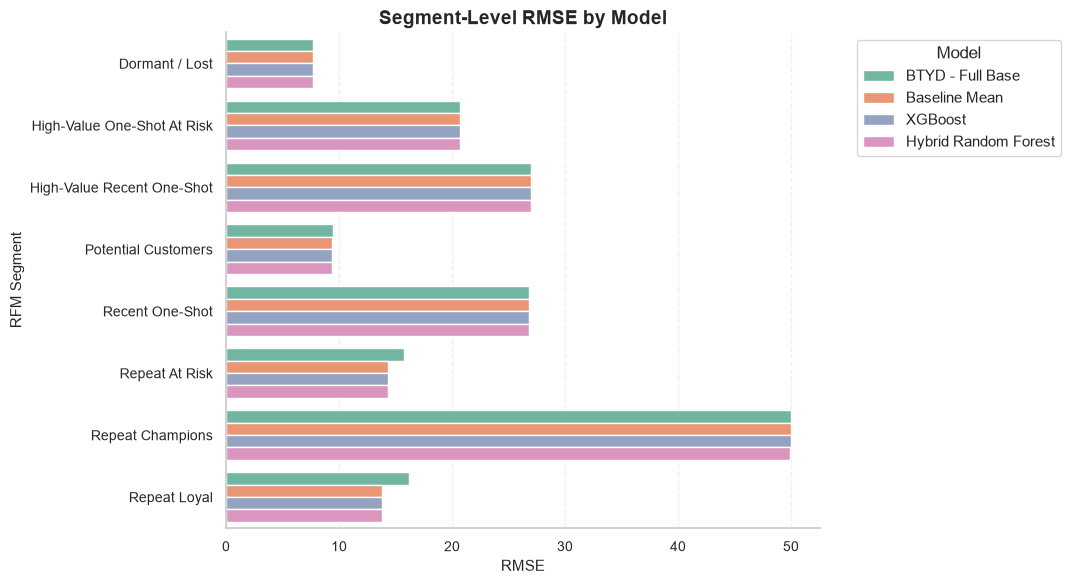

In [173]:
plt.figure(figsize=(11, 6))

ax = sns.barplot(
    data=segment_plot_data,
    x="RMSE",
    y="rfm_segment",
    hue="model",
    hue_order=models_for_segment_plot
)

plt.title("Segment-Level RMSE by Model")
plt.xlabel("RMSE")
plt.ylabel("RFM Segment")

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

plt.legend(
    title="Model",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

The RMSE comparison confirms that model choice has less influence on prediction difficulty than customer-segment characteristics. Error levels are nearly identical across the supervised models within each segment, while large differences emerge between segments.

Repeat Champions are the most difficult group to predict, followed by recent high-value and one-shot customers. This suggests that a single global revenue model cannot fully represent the heterogeneous purchasing dynamics of the customer base.

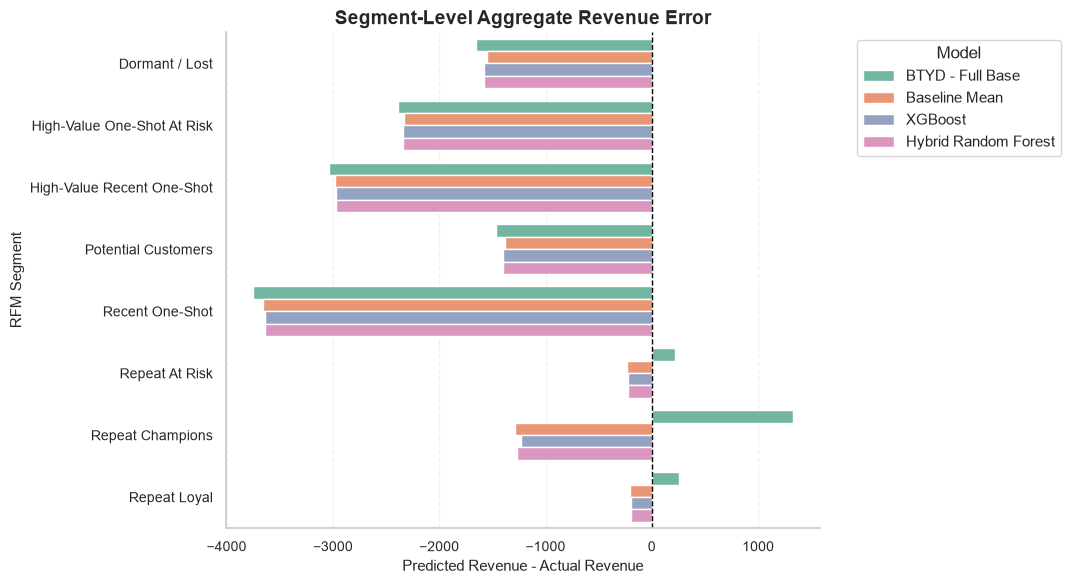

In [174]:
plt.figure(figsize=(11, 6))

ax = sns.barplot(
    data=segment_plot_data,
    x="revenue_error",
    y="rfm_segment",
    hue="model",
    hue_order=models_for_segment_plot
)

plt.axvline(
    0,
    color="black",
    linestyle="--",
    linewidth=1
)

plt.title("Segment-Level Aggregate Revenue Error")
plt.xlabel("Predicted Revenue - Actual Revenue")
plt.ylabel("RFM Segment")

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

plt.legend(
    title="Model",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

The aggregate revenue-error plot reveals systematic underprediction rather than isolated customer-level noise. The largest negative gaps occur among Recent One-Shot, High-Value Recent One-Shot and High-Value At Risk customers, which together account for a substantial share of realized test revenue.

This pattern indicates that the models compress rare but valuable outcomes toward low predictions. For campaign planning, the scores should therefore be used to rank customers within segments, while budget forecasts should be calibrated separately using observed segment-level revenue totals.

## **Explainable AI: Model Interpretation**

Explainability is applied to the strongest tree-based hybrid model in order to understand which customer signals drive its predictions.

Two complementary methods are used. Model-based feature importance measures how frequently and effectively variables contribute to tree splits, while SHAP values estimate the average contribution of each feature to the model output.

Because the regression model was trained on `log1p` transformed revenue, SHAP effects are expressed on the logarithmic prediction scale rather than directly in monetary units.

In [175]:
# Collect all fitted tree-based models

interpretable_models = {}

for name, model in ml_fitted_models.items():

    if name != "Baseline Mean":
        interpretable_models[name] = model

for name, model in hybrid_fitted_models.items():

    interpretable_models[name] = model


# Select the tree-based model with the lowest final test RMSE.
# This selection is used only for post-hoc interpretation,
# not for additional tuning.

best_interpretation_row = (
    model_comparison_df[
        model_comparison_df["model"]
        .isin(interpretable_models.keys())
    ]
    .sort_values(
        ["RMSE", "MAE"]
    )
    .iloc[0]
)

best_model_name = (
    best_interpretation_row["model"]
)

best_pipeline = (
    interpretable_models[best_model_name]
)

print(
    f"Model selected for interpretation: "
    f"{best_model_name}"
)

print(
    f"RMSE: "
    f"{best_interpretation_row['RMSE']:.4f}"
)

print(
    f"MAE: "
    f"{best_interpretation_row['MAE']:.4f}"
)

Model selected for interpretation: Hybrid Random Forest
RMSE: 20.1183
MAE: 0.9571


Hybrid Random Forest is selected for interpretation because it obtains the lowest final RMSE, equal to 20.1174. Its advantage over the other tree-based models is extremely small, so the selection should not be interpreted as evidence of a large performance difference.

The model is nevertheless appropriate for interpretation because it combines the original behavioural and service variables with the BTYD probabilistic signals.

In [176]:
# Extract encoded feature names and model-based feature importance

best_preprocessor = best_pipeline.named_steps["preprocessor"]
best_model = best_pipeline.named_steps["model"]

encoded_feature_names = best_preprocessor.get_feature_names_out()

if not hasattr(best_model, "feature_importances_"):
    raise ValueError("The selected model does not provide feature_importances_.")

encoded_feature_importance = pd.DataFrame({
    "encoded_feature": encoded_feature_names,
    "importance": best_model.feature_importances_
})

encoded_feature_importance = encoded_feature_importance.sort_values(
    "importance",
    ascending=False
)

encoded_feature_importance.head(20)

,encoded_feature,importance
18,num__predicted_purchases_90d,0.225821
16,num__avg_freight_value,0.096749
20,num__btyd_cltv_90d,0.062118
13,num__avg_delivery_time_days,0.059698
5,num__tenure_days,0.053607
17,num__avg_freight_ratio,0.049106
4,num__recency_days,0.047650
9,num__avg_item_price,0.042921
19,num__probability_alive,0.039702
0,num__n_orders,0.034842


In [177]:
# Aggregate encoded feature importance back to original feature names

original_feature_pool = (
    hybrid_feature_cols if best_model_name.startswith("Hybrid") else feature_cols
)

def map_encoded_to_original(encoded_name, original_features):
    clean_name = encoded_name.split("__", 1)[-1]
    
    for feature in sorted(original_features, key=len, reverse=True):
        if clean_name == feature or clean_name.startswith(feature + "_"):
            return feature
    
    return clean_name

encoded_feature_importance["original_feature"] = encoded_feature_importance[
    "encoded_feature"
].apply(lambda x: map_encoded_to_original(x, original_feature_pool))

feature_importance = (
    encoded_feature_importance
    .groupby("original_feature", as_index=False)
    .agg(total_importance=("importance", "sum"))
    .sort_values("total_importance", ascending=False)
)

feature_importance["importance_share_pct"] = (
    feature_importance["total_importance"] /
    feature_importance["total_importance"].sum() * 100
)

feature_importance.round(4).head(20)

,original_feature,total_importance,importance_share_pct
18,predicted_purchases_90d,0.2258,22.5821
3,avg_freight_value,0.0967,9.6749
11,main_product_category,0.0631,6.3091
7,btyd_cltv_90d,0.0621,6.2118
1,avg_delivery_time_days,0.0597,5.9698
22,tenure_days,0.0536,5.3607
2,avg_freight_ratio,0.0491,4.9106
20,recency_days,0.0477,4.7650
4,avg_item_price,0.0429,4.2921
19,probability_alive,0.0397,3.9702


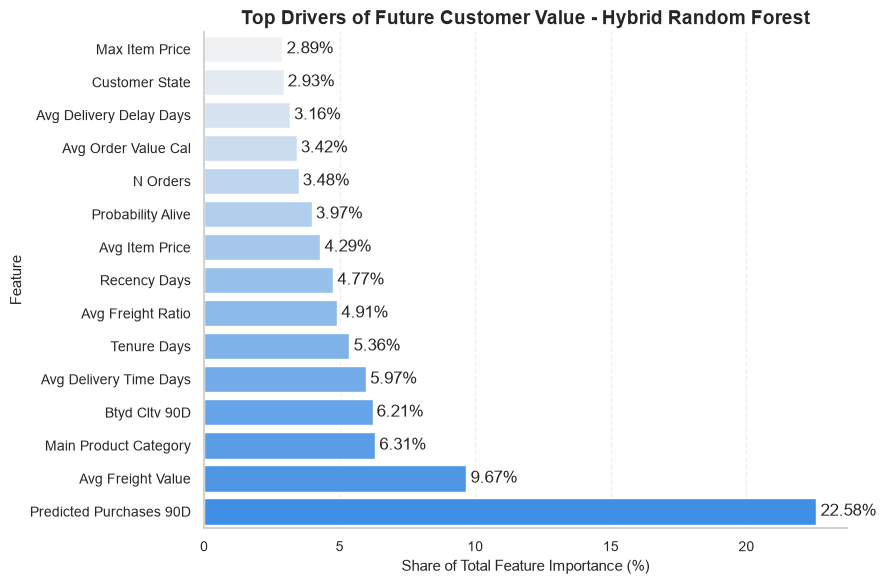

In [178]:
# Plot the main drivers of predicted future customer value with gradient colors

top_features = feature_importance.head(15).sort_values(
    "importance_share_pct",
    ascending=True
).copy()

top_features["feature_label"] = (
    top_features["original_feature"]
    .str.replace("_", " ", regex=False)
    .str.title()
)

gradient_palette = sns.light_palette(
    "#248EFF",
    n_colors=len(top_features)
)

plt.figure(figsize=(9, 6))

ax = sns.barplot(
    data=top_features,
    x="importance_share_pct",
    y="feature_label",
    hue="feature_label",
    palette=gradient_palette,
    legend=False
)

add_horizontal_bar_labels(ax, fmt="{:.2f}%", padding=3)

plt.title(f"Top Drivers of Future Customer Value - {best_model_name}")
plt.xlabel("Share of Total Feature Importance (%)")
plt.ylabel("Feature")
plt.grid(axis="x", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

The impurity-based feature importance ranking assigns the greatest weight to `Main Product Category`, representing 15.10% of total importance. Average freight value follows at 14.56%, while BTYD 90-day CLTV contributes 7.70%.

Delivery experience, customer tenure, predicted purchases, recency and main product category also appear among the principal model inputs. This indicates that the hybrid model combines probabilistic customer-status information with transaction history, logistics and product preferences.

However, impurity-based importance does not indicate whether high feature values increase or decrease predicted revenue. It may also favour continuous variables or variables offering many potential split points. For this reason, the ranking is complemented by SHAP analysis.

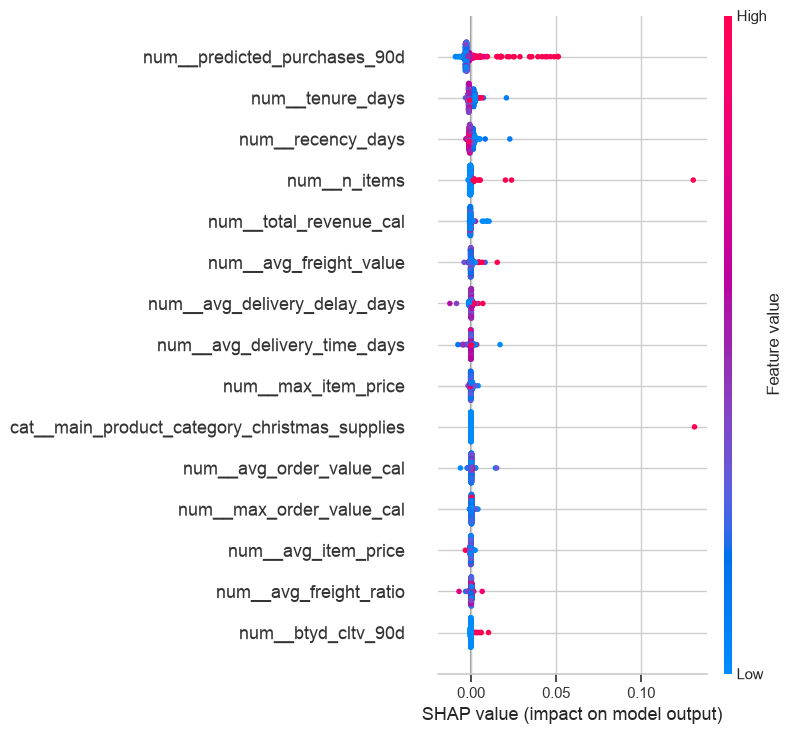

In [179]:
# Optional SHAP interpretation on a test-set sample

try:
    import shap
    shap_available = True

except ImportError:
    shap_available = False


if shap_available:

    # Use the feature space corresponding to the selected model

    X_interpretation = (
        X_test_hybrid
        if best_model_name.startswith("Hybrid")
        else X_test
    )

    shap_sample = X_interpretation.sample(
        n=min(500, len(X_interpretation)),
        random_state=42
    )


    # Extract the fitted preprocessing and tree model

    best_preprocessor = (
        best_pipeline.named_steps["preprocessor"]
    )

    best_model = (
        best_pipeline.named_steps["model"]
    )


    # Transform the sample exactly as during model fitting

    shap_sample_transformed = (
        best_preprocessor
        .transform(shap_sample)
    )

    if hasattr(
        shap_sample_transformed,
        "toarray"
    ):
        shap_sample_transformed = (
            shap_sample_transformed.toarray()
        )


    encoded_feature_names = (
        best_preprocessor
        .get_feature_names_out()
    )


    # Calculate SHAP values

    explainer = shap.TreeExplainer(
        best_model
    )

    try:
        shap_values = explainer.shap_values(
            shap_sample_transformed,
            check_additivity=False
        )

    except TypeError:
        shap_values = explainer.shap_values(
            shap_sample_transformed
        )


    # Convert newer SHAP objects if required

    if hasattr(shap_values, "values"):
        shap_array = shap_values.values
    else:
        shap_array = np.asarray(shap_values)


    # Global SHAP summary plot

    shap.summary_plot(
        shap_array,
        shap_sample_transformed,
        feature_names=encoded_feature_names,
        max_display=15
    )

The SHAP summary shows how individual feature values influence the model’s logarithmic revenue prediction. Probability alive produces the largest global contribution, followed by BTYD 90-day CLTV and recency.

Higher probability-alive and BTYD CLTV values generally produce positive effects for the small group of customers with stronger probabilistic future-value signals. Higher recency, representing a longer time since the last purchase, generally pushes predictions downward, while more recently active customers tend to receive higher predicted future value.

Tenure, historical revenue, order value and purchased-item volume also contribute to the predictions, although their direction and magnitude vary across customers. Most observations remain concentrated close to zero because the target is overwhelmingly composed of zero-revenue cases.

In [180]:
# Aggregate SHAP importance back to original feature names

if shap_available:
    shap_importance_encoded = pd.DataFrame({
        "encoded_feature": encoded_feature_names,
        "mean_abs_shap": np.abs(shap_values).mean(axis=0)
    })
    
    shap_importance_encoded["original_feature"] = shap_importance_encoded[
        "encoded_feature"
    ].apply(lambda x: map_encoded_to_original(x, original_feature_pool))
    
    shap_importance = (
        shap_importance_encoded
        .groupby("original_feature", as_index=False)
        .agg(mean_abs_shap=("mean_abs_shap", "sum"))
        .sort_values("mean_abs_shap", ascending=False)
    )
    
    shap_importance["shap_share_pct"] = (
        shap_importance["mean_abs_shap"] /
        shap_importance["mean_abs_shap"].sum() * 100
    )
    
    shap_importance.round(4).head(20)

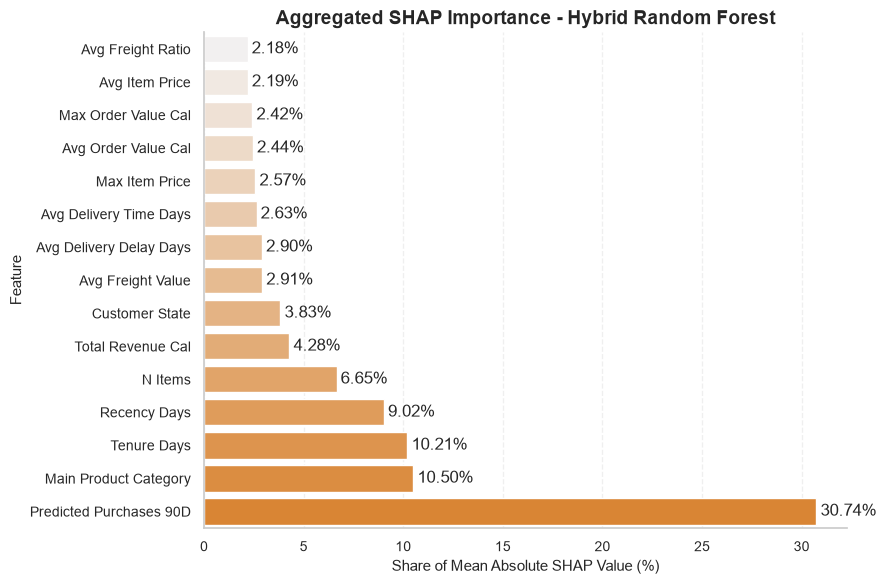

In [181]:
# Plot aggregated SHAP importance with gradient colors

if shap_available:
    top_shap_features = shap_importance.head(15).sort_values(
        "shap_share_pct",
        ascending=True
    ).copy()
    
    top_shap_features["feature_label"] = (
        top_shap_features["original_feature"]
        .str.replace("_", " ", regex=False)
        .str.title()
    )
    
    shap_gradient_palette = sns.light_palette(
        "#F58518",
        n_colors=len(top_shap_features)
    )
    
    plt.figure(figsize=(9, 6))
    
    ax = sns.barplot(
        data=top_shap_features,
        x="shap_share_pct",
        y="feature_label",
        hue="feature_label",
        palette=shap_gradient_palette,
        legend=False
    )
    
    add_horizontal_bar_labels(ax, fmt="{:.2f}%", padding=3)
    
    plt.title(f"Aggregated SHAP Importance - {best_model_name}")
    plt.xlabel("Share of Mean Absolute SHAP Value (%)")
    plt.ylabel("Feature")
    plt.grid(axis="x", linestyle="--", alpha=0.3)
    plt.tight_layout()
    plt.show()

After one-hot encoded variables are aggregated back to their original features, probability alive accounts for 22.82% of total mean absolute SHAP impact. BTYD 90-day CLTV follows at 14.80%, while recency contributes 14.17% and tenure 8.05%.

Main product category represents 6.48%, calibration revenue 5.87% and average calibration order value 4.62%. The corrected hybrid specification therefore shows that probabilistic customer-status signals, recent activity and relationship history are the most influential global drivers of the model output.

The difference between SHAP and impurity-based importance is expected because the two methods measure feature contribution differently. For strategic interpretation, SHAP should receive greater weight because it evaluates the magnitude of each variable’s contribution to individual predictions.

## **Marketing Strategy**

The marketing strategy translates the probabilistic outputs into customer-level communication priorities. The following matrix applies to the 1,503 customers eligible for the complete BG/NBD and Gamma-Gamma CLTV framework.

Customers are divided according to two complementary dimensions: their predicted 90-day CLTV and their probability of remaining active. Median thresholds are used to create four operational groups with different communication objectives, investment levels and retention priorities.

This framework should be interpreted as a resource-allocation tool for the modelled repeat-customer population rather than as a universal segmentation of the complete customer base.

### **CLTV x Probability Alive Matrix**

In [182]:
# Build the strategy dataset for BTYD-eligible customers

strategy_data = (
    ggf_data[
        [
            "customer_unique_id",
            "predicted_purchases_90d",
            "probability_alive",
            "btyd_cltv_90d"
        ]
    ]
    .drop_duplicates(
        subset="customer_unique_id"
    )
    .merge(
        rfm_table[
            [
                "customer_unique_id",
                "rfm_segment"
            ]
        ],
        on="customer_unique_id",
        how="left"
    )
    .merge(
        ml_customer_features[
            [
                "customer_unique_id",
                "customer_state",
                "n_orders",
                "total_revenue_cal",
                "avg_order_value_cal",
                "recency_days",
                "tenure_days",
                "main_product_category",
                "avg_review_score",
                "review_missing_rate",
                "avg_delivery_time_days",
                "avg_delivery_delay_days",
                "late_delivery_rate",
                "avg_freight_value",
                "avg_freight_ratio"
            ]
        ],
        on="customer_unique_id",
        how="left"
    )
)



# Complete missing descriptive labels

strategy_data["rfm_segment"] = (
    strategy_data["rfm_segment"]
    .fillna("Unclassified")
)

strategy_data["customer_state"] = (
    strategy_data["customer_state"]
    .fillna("Unknown")
)

strategy_data["main_product_category"] = (
    strategy_data["main_product_category"]
    .fillna("Unknown")
)


assert strategy_data[
    "customer_unique_id"
].is_unique


# Define median-based decision thresholds

cltv_threshold = (
    strategy_data["btyd_cltv_90d"]
    .median()
)

alive_threshold = (
    strategy_data["probability_alive"]
    .median()
)


strategy_thresholds = pd.DataFrame({
    "decision_dimension": [
        "Predicted 90-day CLTV",
        "Probability alive"
    ],
    "median_threshold": [
        cltv_threshold,
        alive_threshold
    ]
})

strategy_thresholds = (
    strategy_thresholds.round(3)
)

display(strategy_thresholds)


# Assign high and low levels

strategy_data["cltv_level"] = np.where(
    strategy_data["btyd_cltv_90d"]
    >= cltv_threshold,
    "High predicted CLTV",
    "Low predicted CLTV"
)

strategy_data["alive_level"] = np.where(
    strategy_data["probability_alive"]
    >= alive_threshold,
    "High probability alive",
    "Low probability alive"
)


# Assign one operational strategy to each quadrant

def assign_strategy_cell(row):

    if (
        row["cltv_level"] == "High predicted CLTV"
        and row["alive_level"] == "High probability alive"
    ):
        return "Protect High-Value Active"

    elif (
        row["cltv_level"] == "High predicted CLTV"
        and row["alive_level"] == "Low probability alive"
    ):
        return "Priority Win-Back"

    elif (
        row["cltv_level"] == "Low predicted CLTV"
        and row["alive_level"] == "High probability alive"
    ):
        return "Low-Cost Nurture"

    else:
        return "Monitor / Low Priority"


strategy_data["strategy_cell"] = (
    strategy_data.apply(
        assign_strategy_cell,
        axis=1
    )
)


# Summarize each strategy cell

strategy_matrix_summary = (
    strategy_data
    .groupby(
        "strategy_cell",
        as_index=False
    )
    .agg(
        n_customers=(
            "customer_unique_id",
            "nunique"
        ),
        avg_predicted_cltv_90d=(
            "btyd_cltv_90d",
            "mean"
        ),
        total_predicted_cltv_90d=(
            "btyd_cltv_90d",
            "sum"
        ),
        avg_probability_alive=(
            "probability_alive",
            "mean"
        ),
        avg_expected_purchases_90d=(
            "predicted_purchases_90d",
            "mean"
        ),
        avg_review_score=(
            "avg_review_score",
            "mean"
        ),
        avg_late_delivery_rate=(
            "late_delivery_rate",
            "mean"
        ),
        avg_freight_ratio=(
            "avg_freight_ratio",
            "mean"
        )
    )
)


strategy_matrix_summary["customer_share_pct"] = (
    strategy_matrix_summary["n_customers"]
    / strategy_matrix_summary["n_customers"].sum()
    * 100
)

strategy_matrix_summary["predicted_value_share_pct"] = (
    strategy_matrix_summary["total_predicted_cltv_90d"]
    / strategy_matrix_summary[
        "total_predicted_cltv_90d"
    ].sum()
    * 100
)


strategy_matrix_summary = (
    strategy_matrix_summary
    .sort_values(
        "total_predicted_cltv_90d",
        ascending=False
    )
    .reset_index(drop=True)
    .round(3)
)

strategy_matrix_summary

,decision_dimension,median_threshold
0,Predicted 90-day CLTV,3.469
1,Probability alive,0.098


,strategy_cell,n_customers,avg_predicted_cltv_90d,total_predicted_cltv_90d,avg_probability_alive,avg_expected_purchases_90d,avg_review_score,avg_late_delivery_rate,avg_freight_ratio,customer_share_pct,predicted_value_share_pct
0,Protect High-Value Active,553,28.179,15582.849,0.267,0.160,4.258,0.063,0.198,36.793,84.847
1,Priority Win-Back,199,7.614,1515.087,0.074,0.027,4.069,0.083,0.153,13.240,8.250
2,Monitor / Low Priority,552,1.518,837.680,0.058,0.016,4.318,0.046,0.229,36.727,4.561
3,Low-Cost Nurture,199,2.162,430.149,0.125,0.032,4.376,0.045,0.260,13.240,2.342


The matrix divides the 1,503 BTYD-modelled customers into four distinct communication priorities.

The Protect High-Value Active group contains 553 customers and generates approximately R$15,582.85 in total predicted 90-day CLTV. It combines the highest average predicted value, R$28.18, with the highest average probability alive, 0.267. The appropriate objective is value protection, loyalty reinforcement and prevention of avoidable disengagement.

The Priority Win-Back group contains 199 customers and generates approximately R$1,515.09 in predicted value. Its average predicted CLTV remains comparatively high at R$7.61, while average probability alive falls to 0.074. These customers represent the clearest selective reactivation opportunity.

The Low-Cost Nurture group also contains 199 customers. It combines relatively low predicted CLTV, approximately R$2.16 on average, with a higher probability alive of 0.125. These customers should receive automated and inexpensive communications intended to develop future value.

The Monitor / Low Priority group contains 552 customers, with average predicted CLTV of approximately R$1.52 and average probability alive of 0.058. Expensive individual retention actions are unlikely to be justified for this group.

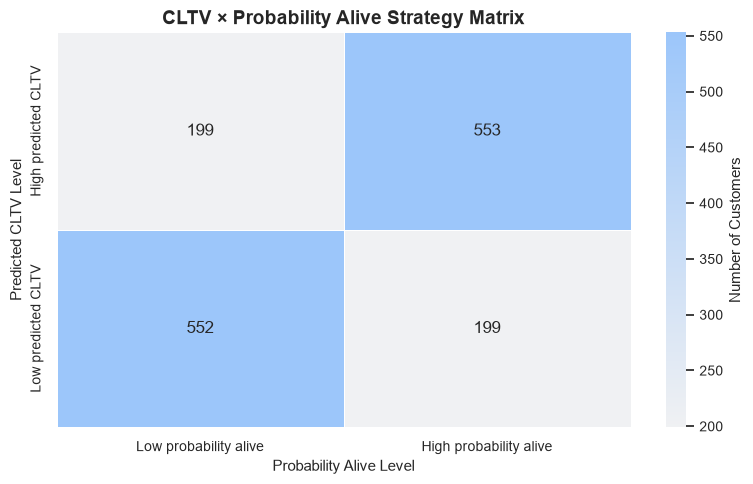

In [183]:
# Count customers in each CLTV × probability-alive quadrant

matrix_counts = (
    strategy_data
    .pivot_table(
        index="cltv_level",
        columns="alive_level",
        values="customer_unique_id",
        aggfunc="nunique",
        fill_value=0
    )
)


matrix_counts = matrix_counts.reindex(
    index=[
        "High predicted CLTV",
        "Low predicted CLTV"
    ],
    columns=[
        "Low probability alive",
        "High probability alive"
    ]
)


plt.figure(figsize=(8, 5))

ax = sns.heatmap(
    matrix_counts,
    annot=True,
    fmt=".0f",
    cmap=sns.light_palette(
        "#9CC6FA",
        as_cmap=True
    ),
    linewidths=0.5,
    linecolor="white",
    cbar_kws={
        "label": "Number of Customers"
    }
)

plt.title(
    "CLTV × Probability Alive Strategy Matrix"
)

plt.xlabel(
    "Probability Alive Level"
)

plt.ylabel(
    "Predicted CLTV Level"
)

plt.tight_layout()
plt.show()

The matrix divides the 1,503 BTYD-modeled customers into four strategically distinct groups. The two largest groups are Protect High-Value Active, with 553 customers, and Monitor / Low Priority, with 552 customers.

Two equally sized but strategically opposite groups contain 199 customers each. Priority Win-Back customers combine high predicted CLTV with low probability alive, while Low-Cost Nurture customers combine lower predicted CLTV with comparatively high probability alive.

Overall, the two high-predicted-CLTV quadrants contain 752 customers, corresponding to approximately 50.03% of the modeled population. Marketing resources should therefore focus primarily on protecting the 553 active high-value customers and selectively reactivating the 199 high-value customers showing weak purchase continuity. The remaining groups should receive lower-cost and more automated communication.

### **Priority Win-Back Segment**

In [184]:
# Focus on Priority Win-Back customers

priority_winback = strategy_data[
    strategy_data["strategy_cell"] == "Priority Win-Back"
].copy()

priority_winback_summary = pd.DataFrame({
    "metric": [
        "priority win-back customers",
        "share of modeled customers (%)",
        "total predicted 90-day CLTV",
        "average predicted 90-day CLTV",
        "average probability alive",
        "average expected purchases 90d",
        "average review score",
        "average late delivery rate",
        "average freight ratio"
    ],
    "value": [
        len(priority_winback),
        len(priority_winback) / len(strategy_data) * 100,
        priority_winback["btyd_cltv_90d"].sum(),
        priority_winback["btyd_cltv_90d"].mean(),
        priority_winback["probability_alive"].mean(),
        priority_winback["predicted_purchases_90d"].mean(),
        priority_winback["avg_review_score"].mean(),
        priority_winback["late_delivery_rate"].mean(),
        priority_winback["avg_freight_ratio"].mean()
    ]
})

priority_winback_summary["value"] = priority_winback_summary["value"].round(3)
priority_winback_summary

,metric,value
0,priority win-back customers,199.000
1,share of modeled customers (%),13.240
2,total predicted 90-day CLTV,1515.087
3,average predicted 90-day CLTV,7.614
4,average probability alive,0.074
5,average expected purchases 90d,0.027
6,average review score,4.069
7,average late delivery rate,0.083
8,average freight ratio,0.153


The Priority Win-Back segment contains 199 customers, corresponding to approximately 13.24% of the BTYD-modeled population. The group represents approximately 1,515.09 in total predicted 90-day CLTV, with an average predicted value of 7.61 per customer.

Its average probability alive is only 0.074 and its expected purchase frequency is approximately 0.027 over the following 90 days. The segment therefore combines comparatively high predicted value with very weak short-term purchase continuity, making it a relevant but selective reactivation audience.

The average review score remains relatively high at 4.069, while the average late-delivery rate is approximately 8.3%. The weak probability of future activity therefore cannot be attributed solely to widespread dissatisfaction or delivery failure. The average freight ratio is approximately 15.3%, suggesting that logistics-related incentives such as selective free shipping may be tested for customers with elevated freight burden, rather than applied indiscriminately to the entire segment.

In [185]:
# Highest-value customers inside the Priority Win-Back group

priority_winback_customers = (
    priority_winback
    .sort_values("btyd_cltv_90d", ascending=False)
    [
        [
            "customer_unique_id",
            "rfm_segment",
            "customer_state",
            "main_product_category",
            "btyd_cltv_90d",
            "probability_alive",
            "predicted_purchases_90d",
            "avg_review_score",
            "late_delivery_rate",
            "avg_freight_ratio"
        ]
    ]
    .head(15)
)

priority_winback_customers.round(3)

,customer_unique_id,rfm_segment,customer_state,main_product_category,btyd_cltv_90d,probability_alive,predicted_purchases_90d,avg_review_score,late_delivery_rate,avg_freight_ratio
962,a1044dd75b74fbc485b040575a14acf0,Repeat Loyal,SP,construction_tools_construction,39.352,0.057,0.021,3.0,0.0,0.160
1275,da1e7179b9c5a1494d78528cbcf05aa0,Repeat Loyal,SC,computers,29.465,0.094,0.019,3.0,0.0,0.131
322,3442a61b2d5bfd9d605d6943701ad650,Repeat Champions,SP,construction_tools_construction,28.356,0.096,0.056,1.0,0.0,0.096
556,5d2dfd15300a557c1ddfad56a8460226,Repeat Champions,DF,furniture_living_room,27.233,0.091,0.050,5.0,0.0,0.117
1303,dd8253fe17486f2e2cbff105e36e4a55,Repeat Loyal,SP,auto,25.850,0.071,0.028,3.5,0.0,0.196
1250,d5419994a02a55d4b7cd00e77fabdbae,Repeat Loyal,SP,cool_stuff,23.907,0.065,0.021,4.0,0.0,0.068
1410,ecdbc4bf2201c807294c7d8c4b777032,Repeat At Risk,SP,food,23.334,0.093,0.017,5.0,0.0,0.089
808,8bb910cd8c3b29e4acf2e94e3aaffbbf,Repeat Loyal,MT,computers_accessories,22.154,0.055,0.019,4.0,0.0,0.107
693,75c7cb4037146f5c8e95ade4214396c5,Repeat Loyal,SP,bed_bath_table,20.262,0.097,0.027,5.0,0.0,0.139
680,73601b1eec55943e90ce8d61253d5c09,Repeat At Risk,MG,consoles_games,19.342,0.059,0.017,4.5,0.0,0.028


The customer-level ranking converts the strategic segment into an actionable campaign audience. The highest-value Priority Win-Back customers should be contacted first, with campaign intensity adjusted according to predicted CLTV, probability alive and observed service signals.

Customers with high historical review scores and no delivery problems are suitable for personalized product reminders or loyalty benefits. Customers with weaker review scores or previous delivery issues should instead receive reassurance, service-oriented messaging or lower-friction recovery offers.

### **Geographic CLTV Disparity**

The previous analyses identify customer-level value and activity signals. This section examines whether the predicted 90-day CLTV of the BTYD-modeled population is geographically concentrated.

The comparison is based on total predicted value rather than average CLTV alone. Total value combines customer volume and customer-level potential, while state averages may be unstable in regions represented by only a few eligible customers. Geographic results are therefore interpreted as resource-allocation signals rather than evidence that location causally determines customer value.

In [186]:
# Summarize predicted CLTV by customer state

state_cltv_strategy = (
    strategy_data
    .dropna(subset=["customer_state"])
    .groupby("customer_state", as_index=False)
    .agg(
        n_customers=("customer_unique_id", "nunique"),
        total_predicted_cltv_90d=("btyd_cltv_90d", "sum"),
        avg_predicted_cltv_90d=("btyd_cltv_90d", "mean"),
        avg_probability_alive=("probability_alive", "mean"),
        avg_review_score=("avg_review_score", "mean"),
        avg_late_delivery_rate=("late_delivery_rate", "mean"),
        avg_freight_ratio=("avg_freight_ratio", "mean")
    )
)

# Overall modeled population and predicted value
total_modeled_customers = state_cltv_strategy["n_customers"].sum()
total_predicted_cltv = state_cltv_strategy[
    "total_predicted_cltv_90d"
].sum()

# Geographic shares
state_cltv_strategy["customer_share_pct"] = (
    state_cltv_strategy["n_customers"]
    / total_modeled_customers
    * 100
)

state_cltv_strategy["predicted_value_share_pct"] = (
    state_cltv_strategy["total_predicted_cltv_90d"]
    / total_predicted_cltv
    * 100
)

# Rank states by total predicted customer value
state_cltv_strategy = (
    state_cltv_strategy
    .sort_values(
        "total_predicted_cltv_90d",
        ascending=False
    )
    .reset_index(drop=True)
)

state_cltv_strategy["cumulative_value_share_pct"] = (
    state_cltv_strategy["predicted_value_share_pct"]
    .cumsum()
)

state_cltv_strategy.round(3).head(15)

,customer_state,n_customers,total_predicted_cltv_90d,avg_predicted_cltv_90d,avg_probability_alive,avg_review_score,avg_late_delivery_rate,avg_freight_ratio,customer_share_pct,predicted_value_share_pct,cumulative_value_share_pct
0,SP,657,7510.461,11.431,0.146,4.333,0.031,0.189,43.713,40.894,40.894
1,RJ,216,3276.212,15.168,0.147,4.120,0.105,0.211,14.371,17.839,58.732
2,MG,174,1901.411,10.928,0.149,4.330,0.039,0.214,11.577,10.353,69.086
3,RS,86,1013.877,11.789,0.152,4.281,0.062,0.232,5.722,5.520,74.606
4,BA,44,717.325,16.303,0.162,4.081,0.126,0.249,2.927,3.906,78.512
5,GO,29,595.415,20.532,0.180,4.368,0.034,0.251,1.929,3.242,81.754
6,PB,8,476.300,59.537,0.239,3.938,0.125,0.279,0.532,2.593,84.347
7,PE,18,440.890,24.494,0.202,3.994,0.093,0.270,1.198,2.401,86.748
8,PR,68,419.859,6.174,0.119,4.441,0.044,0.235,4.524,2.286,89.034
9,SC,51,414.036,8.118,0.103,4.268,0.065,0.205,3.393,2.254,91.288


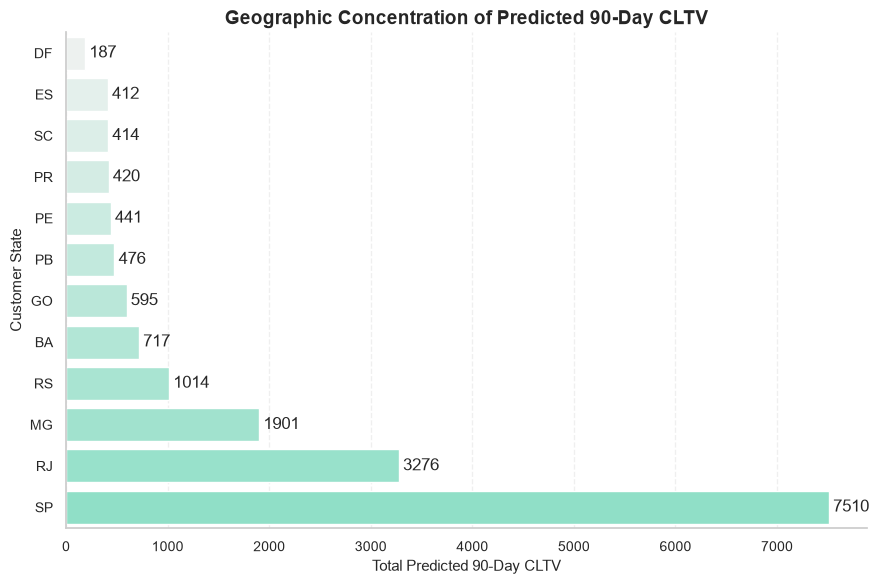

In [187]:
# Plot geographic concentration of predicted CLTV

state_plot = (
    state_cltv_strategy
    .head(12)
    .sort_values(
        "total_predicted_cltv_90d",
        ascending=True
    )
    .copy()
)

state_palette = sns.light_palette(
    "#83ECCC",
    n_colors=len(state_plot)
)

plt.figure(figsize=(9, 6))

ax = sns.barplot(
    data=state_plot,
    x="total_predicted_cltv_90d",
    y="customer_state",
    hue="customer_state",
    palette=state_palette,
    legend=False
)

add_horizontal_bar_labels(
    ax,
    fmt="{:.0f}",
    padding=3
)

plt.title("Geographic Concentration of Predicted 90-Day CLTV")
plt.xlabel("Total Predicted 90-Day CLTV")
plt.ylabel("Customer State")
plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)
plt.tight_layout()
plt.show()

Predicted 90-day CLTV is strongly concentrated geographically. In the current model output, São Paulo represents the largest value pool, with approximately 7,510 in total predicted CLTV, followed by Rio de Janeiro with approximately 3,276 and Minas Gerais with approximately 1,901.

This concentration is partly driven by customer volume. It should therefore be interpreted as an indication of where the largest modeled CRM audiences are located, rather than as evidence that residence in a particular state increases customer value.

Several states contain only a small number of BTYD-eligible customers. Their average CLTV, probability alive and service metrics may consequently be unstable. For campaign planning, total predicted value and customer volume should receive greater weight than state-level averages. Geographic information should also be applied as an overlay on customer-level targeting, not as a substitute for it.

### **Migration-Style Segment Tracking**

RFM segmentation describes customer status at the end of the calibration period, but its strategic usefulness also depends on what customers do afterwards. This section connects each calibration RFM segment with observed behavior during the subsequent 90-day holdout period.

Customers are classified as having no holdout purchase, low holdout value or high holdout value. The distinction between low and high value is based on the median positive holdout revenue, so it is calculated only among customers who actually purchased.

The holdout variables are used exclusively for retrospective evaluation. They are not included among the predictors and would not be available when a campaign is launched at the calibration boundary.

In [188]:
# Connect calibration RFM segments with subsequent holdout behavior

migration_data = (
    rfm_table[
        [
            "customer_unique_id",
            "rfm_segment"
        ]
    ]
    .merge(
        customer_target[
            [
                "customer_unique_id",
                "target_revenue_90d",
                "target_orders_90d",
                "repurchased_in_holdout"
            ]
        ],
        on="customer_unique_id",
        how="left"
    )
)

# Customers without a matched holdout transaction generated no holdout value
migration_data["target_revenue_90d"] = (
    migration_data["target_revenue_90d"]
    .fillna(0)
)

migration_data["target_orders_90d"] = (
    migration_data["target_orders_90d"]
    .fillna(0)
)

migration_data["repurchased_in_holdout"] = (
    migration_data["repurchased_in_holdout"]
    .fillna(0)
    .astype(int)
)

# Derive a consistent purchase indicator from observed holdout orders
migration_data["has_holdout_purchase"] = (
    migration_data["target_orders_90d"] > 0
).astype(int)

# Median revenue among customers with a positive holdout purchase
positive_holdout_revenue = migration_data.loc[
    migration_data["target_revenue_90d"] > 0,
    "target_revenue_90d"
]

if positive_holdout_revenue.empty:
    raise ValueError(
        "No positive holdout revenue is available "
        "for the migration analysis."
    )

positive_revenue_median = (
    positive_holdout_revenue.median()
)

# Convert holdout outcomes into three business-oriented behavior groups
migration_data["holdout_behavior"] = np.select(
    [
        migration_data["has_holdout_purchase"] == 0,
        (
            (migration_data["has_holdout_purchase"] == 1)
            & (
                migration_data["target_revenue_90d"]
                < positive_revenue_median
            )
        ),
        (
            (migration_data["has_holdout_purchase"] == 1)
            & (
                migration_data["target_revenue_90d"]
                >= positive_revenue_median
            )
        )
    ],
    [
        "No Holdout Purchase",
        "Low Holdout Value",
        "High Holdout Value"
    ],
    default="No Holdout Purchase"
)

# Use a lifecycle-oriented order for reporting
preferred_rfm_order = [
    "Repeat Champions",
    "Repeat Loyal",
    "Repeat At Risk",
    "High-Value Recent One-Shot",
    "High-Value At Risk",
    "Potential Customers",
    "Recent One-Shot",
    "Dormant / Lost"
]

available_segments = set(
    migration_data["rfm_segment"].dropna()
)

rfm_order = [
    segment
    for segment in preferred_rfm_order
    if segment in available_segments
]

behavior_order = [
    "No Holdout Purchase",
    "Low Holdout Value",
    "High Holdout Value"
]

# Segment-level totals and repurchase rates
segment_overview = (
    migration_data
    .groupby("rfm_segment", as_index=False)
    .agg(
        segment_customers=(
            "customer_unique_id",
            "nunique"
        ),
        holdout_buyers=(
            "has_holdout_purchase",
            "sum"
        ),
        total_segment_holdout_revenue=(
            "target_revenue_90d",
            "sum"
        )
    )
)

segment_overview["repurchase_rate_pct"] = (
    segment_overview["holdout_buyers"]
    / segment_overview["segment_customers"]
    * 100
)

# Behavior composition within each RFM segment
migration_summary = (
    migration_data
    .groupby(
        [
            "rfm_segment",
            "holdout_behavior"
        ],
        as_index=False
    )
    .agg(
        n_customers=(
            "customer_unique_id",
            "nunique"
        ),
        total_holdout_revenue=(
            "target_revenue_90d",
            "sum"
        ),
        avg_holdout_revenue=(
            "target_revenue_90d",
            "mean"
        )
    )
)

# Guarantee that every segment-behavior combination is represented
complete_index = pd.MultiIndex.from_product(
    [
        rfm_order,
        behavior_order
    ],
    names=[
        "rfm_segment",
        "holdout_behavior"
    ]
)

migration_summary = (
    migration_summary
    .set_index(
        [
            "rfm_segment",
            "holdout_behavior"
        ]
    )
    .reindex(
        complete_index,
        fill_value=0
    )
    .reset_index()
)

migration_summary = migration_summary.merge(
    segment_overview,
    on="rfm_segment",
    how="left"
)

migration_summary["segment_share_pct"] = (
    migration_summary["n_customers"]
    / migration_summary["segment_customers"]
    * 100
)

migration_summary["rfm_segment"] = pd.Categorical(
    migration_summary["rfm_segment"],
    categories=rfm_order,
    ordered=True
)

migration_summary["holdout_behavior"] = pd.Categorical(
    migration_summary["holdout_behavior"],
    categories=behavior_order,
    ordered=True
)

migration_summary = (
    migration_summary
    .sort_values(
        [
            "rfm_segment",
            "holdout_behavior"
        ]
    )
    .reset_index(drop=True)
)

migration_summary.round(3)

,rfm_segment,holdout_behavior,n_customers,total_holdout_revenue,avg_holdout_revenue,segment_customers,holdout_buyers,total_segment_holdout_revenue,repurchase_rate_pct,segment_share_pct
0,Repeat Champions,No Holdout Purchase,803,0.00,0.000,827,24,5394.49,2.902,97.098
1,Repeat Champions,Low Holdout Value,10,701.72,70.172,827,24,5394.49,2.902,1.209
2,Repeat Champions,High Holdout Value,14,4692.77,335.198,827,24,5394.49,2.902,1.693
3,Repeat Loyal,No Holdout Purchase,601,0.00,0.000,612,11,985.12,1.797,98.203
4,Repeat Loyal,Low Holdout Value,7,436.01,62.287,612,11,985.12,1.797,1.144
5,Repeat Loyal,High Holdout Value,4,549.11,137.278,612,11,985.12,1.797,0.654
6,Repeat At Risk,No Holdout Purchase,786,0.00,0.000,791,5,643.15,0.632,99.368
7,Repeat At Risk,Low Holdout Value,3,166.85,55.617,791,5,643.15,0.632,0.379
8,Repeat At Risk,High Holdout Value,2,476.30,238.150,791,5,643.15,0.632,0.253
9,High-Value Recent One-Shot,No Holdout Purchase,11469,0.00,0.000,11534,65,13414.47,0.564,99.436


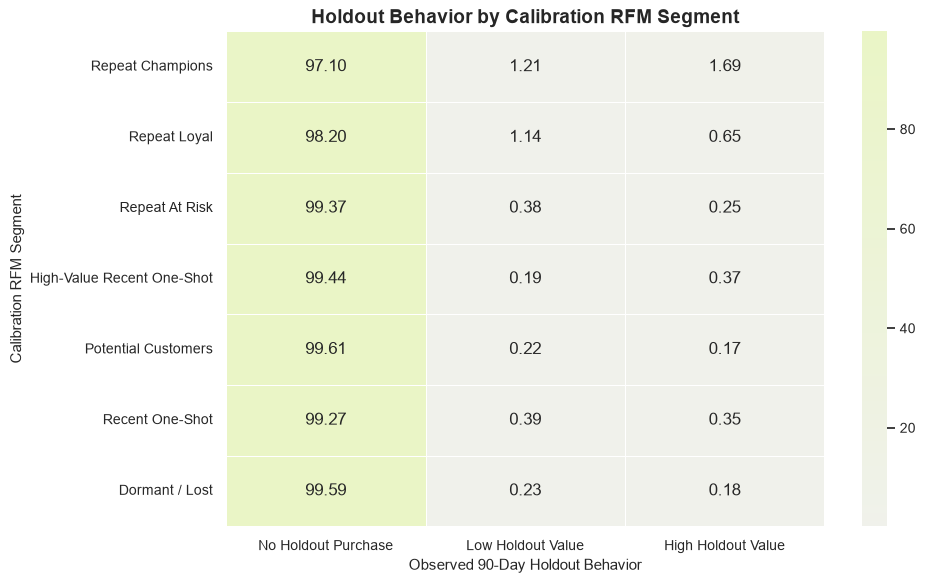

In [189]:
# Visualize holdout behavior composition within each RFM segment

migration_heatmap = (
    migration_summary
    .pivot_table(
        index="rfm_segment",
        columns="holdout_behavior",
        values="segment_share_pct",
        fill_value=0,
        observed=False
    )
    .reindex(
        index=rfm_order,
        columns=behavior_order
    )
)

plt.figure(figsize=(10, 6))

ax = sns.heatmap(
    migration_heatmap,
    annot=True,
    fmt=".2f",
    cmap=sns.light_palette(
        "#EAF5C6",
        as_cmap=True
    ),
    linewidths=0.5,
    linecolor="white"
)

plt.title(
    "Holdout Behavior by Calibration RFM Segment"
)
plt.xlabel("Observed 90-Day Holdout Behavior")
plt.ylabel("Calibration RFM Segment")
plt.tight_layout()
plt.show()

The migration analysis confirms that holdout purchasing is extremely rare across the complete calibration population. More than 97% of every RFM segment generates no purchase during the 90-day holdout window.

Repeat Champions display the strongest relative continuation signal: approximately 2.90% generate holdout revenue, including 1.69% in the high-value group and 1.21% in the low-value group. Repeat Loyal customers follow with an overall positive holdout rate of approximately 1.79%. These percentages remain low in absolute terms, but they are substantially higher than those observed for most one-shot, potential or dormant segments.

Recent One-Shot customers produce the largest absolute number of positive holdout cases because the segment is large, while Repeat Champions produce a stronger conversion rate relative to their segment size. This distinction is important for communication planning: large segments offer reach, whereas smaller repeat segments provide stronger prior evidence of future activity.

The very low conversion rates also indicate that the 90-day holdout is a demanding retention window. These results should be used to compare segments relatively and to identify lifecycle leakage, not to conclude that almost all customers are permanently lost.

### **Segment-specific Campaign Actions**

The analytical outputs are translated into differentiated campaign actions rather than a single undifferentiated retention campaign. Each action links a model signal to a communication objective, activation rule, channel and measurable KPI.

The geographic recommendation is treated as an overlay on customer-level eligibility. A customer should first qualify through predicted value, probability alive or lifecycle status; geographic concentration can then influence delivery intensity and regional budget weighting.

In [190]:
# Translate analytical signals into operational campaign actions

top_states_text = ", ".join(
    state_cltv_strategy
    .head(3)["customer_state"]
    .astype(str)
    .tolist()
)

campaign_actions = pd.DataFrame({
    "campaign_name": [
        "Value Guard",
        "Priority Recovery",
        "Smart Nurture",
        "Efficient Reach",
        "Geo-Value Overlay",
        "Lifecycle Leak Alert"
    ],
    "target_group": [
        "Protect High-Value Active",
        "Priority Win-Back",
        "Low-Cost Nurture",
        "Monitor / Low Priority",
        "High-CLTV Geographic Areas",
        "Historically Valuable Inactive Segments"
    ],
    "analytical_signal": [
        "High predicted CLTV and high probability alive",
        "High predicted CLTV but lower probability alive",
        "Low predicted CLTV but high probability alive",
        "Low predicted CLTV and low probability alive",
        f"Predicted value is concentrated in {top_states_text}",
        "Repeat segments show stronger relative conversion but substantial holdout inactivity"
    ],
    "activation_rule": [
        "Customer belongs to the Protect High-Value Active strategy cell",
        "Customer belongs to the Priority Win-Back strategy cell",
        "Customer belongs to the Low-Cost Nurture strategy cell",
        "Customer belongs to the Monitor / Low Priority strategy cell",
        "Apply only after customer-level eligibility has been established",
        "Trigger when a historically valuable repeat customer exceeds an inactivity threshold"
    ],
    "marketing_objective": [
        "Protect future value without unnecessary discounting",
        "Recover valuable customers showing weakening activity",
        "Stimulate an additional purchase at controlled cost",
        "Maintain light contact while avoiding inefficient spending",
        "Weight CRM delivery toward the largest modeled value pools",
        "Detect value leakage before the customer becomes fully dormant"
    ],
    "recommended_action": [
        "Use loyalty recognition, early access and personalized recommendations rather than broad discounts",
        "Use a service-aware win-back message with a personalized incentive, free shipping or reassurance based on observed friction",
        "Use automated reminders, relevant bundles and low-intensity promotional nudges",
        "Use newsletters or seasonal communication only, without expensive paid retargeting",
        "Increase delivery intensity in high-value states while preserving customer-level selection",
        "Launch a staged reactivation flow after a defined period without a new order"
    ],
    "preferred_channel": [
        "Email, app notification and CRM loyalty flow",
        "Email plus selective paid retargeting",
        "Automated email or low-cost CRM workflow",
        "Newsletter or seasonal campaign",
        "Geo-weighted CRM and regional communication",
        "Lifecycle automation and CRM alerts"
    ],
    "main_kpi": [
        "Repeat purchase rate and retained CLTV",
        "Reactivation rate and recovered revenue",
        "Incremental conversion per communication cost",
        "Campaign efficiency and cost saving",
        "Incremental revenue by state",
        "Reduction in customer value leakage"
    ]
})

campaign_actions

,campaign_name,target_group,analytical_signal,activation_rule,marketing_objective,recommended_action,preferred_channel,main_kpi
0,Value Guard,Protect High-Value Active,High predicted CLTV and high probability alive,Customer belongs to the Protect High-Value Act...,Protect future value without unnecessary disco...,"Use loyalty recognition, early access and pers...","Email, app notification and CRM loyalty flow",Repeat purchase rate and retained CLTV
1,Priority Recovery,Priority Win-Back,High predicted CLTV but lower probability alive,Customer belongs to the Priority Win-Back stra...,Recover valuable customers showing weakening a...,Use a service-aware win-back message with a pe...,Email plus selective paid retargeting,Reactivation rate and recovered revenue
2,Smart Nurture,Low-Cost Nurture,Low predicted CLTV but high probability alive,Customer belongs to the Low-Cost Nurture strat...,Stimulate an additional purchase at controlled...,"Use automated reminders, relevant bundles and ...",Automated email or low-cost CRM workflow,Incremental conversion per communication cost
3,Efficient Reach,Monitor / Low Priority,Low predicted CLTV and low probability alive,Customer belongs to the Monitor / Low Priority...,Maintain light contact while avoiding ineffici...,Use newsletters or seasonal communication only...,Newsletter or seasonal campaign,Campaign efficiency and cost saving
4,Geo-Value Overlay,High-CLTV Geographic Areas,"Predicted value is concentrated in SP, RJ, MG",Apply only after customer-level eligibility ha...,Weight CRM delivery toward the largest modeled...,Increase delivery intensity in high-value stat...,Geo-weighted CRM and regional communication,Incremental revenue by state
5,Lifecycle Leak Alert,Historically Valuable Inactive Segments,Repeat segments show stronger relative convers...,Trigger when a historically valuable repeat cu...,Detect value leakage before the customer becom...,Launch a staged reactivation flow after a defi...,Lifecycle automation and CRM alerts,Reduction in customer value leakage


The campaign framework deliberately separates value protection from discount-driven acquisition. Customers who are both valuable and active should not automatically receive strong incentives, because indiscriminate discounting could reduce margin without changing behavior. Their communication should emphasize recognition, access and relevance.

Priority Win-Back customers require a more intervention-oriented strategy because they combine substantial predicted value with weaker continuation probability. Their campaign can justify higher contact intensity, but incentives should remain selective and should reflect delivery, freight or customer-experience signals where available.

Low-Cost Nurture and Monitor / Low Priority audiences receive less expensive automated communication. This prevents the large size of low-value groups from consuming a disproportionate share of the marketing budget.

The lifecycle migration analysis is used as retrospective evidence that inactivity monitoring is necessary. Holdout outcomes themselves must not be used as campaign features at the calibration date. In production, the equivalent trigger would be a defined period without a new purchase after scoring.

## **Final Business Recommendations**

The final recommendation separates three different business requirements: minimizing prediction error, ranking customers for operational targeting and providing interpretable behavioral signals for CRM strategy.

No single model is best for all three purposes. Model selection must therefore reflect the intended decision rather than relying on one metric alone.

In [191]:
# Compare models on prediction error, targeting value and aggregate calibration

final_model_ranking = (
    model_comparison_df[
        [
            "model",
            "MAE",
            "MSE",
            "RMSE",
            "R2",
            "top_decile_value_capture_pct",
            "total_predicted_revenue",
            "total_actual_revenue"
        ]
    ]
    .copy()
)

# Distance from the best observed RMSE
best_observed_rmse = final_model_ranking["RMSE"].min()

final_model_ranking["rmse_gap_from_best"] = (
    final_model_ranking["RMSE"]
    - best_observed_rmse
)

# Share of realized aggregate revenue reproduced by each model
final_model_ranking["aggregate_revenue_coverage_pct"] = (
    final_model_ranking["total_predicted_revenue"]
    / final_model_ranking["total_actual_revenue"]
    * 100
)

final_model_ranking = (
    final_model_ranking
    .sort_values("RMSE")
    .reset_index(drop=True)
)

final_model_ranking.round(4)

,model,MAE,MSE,RMSE,R2,top_decile_value_capture_pct,total_predicted_revenue,total_actual_revenue,rmse_gap_from_best,aggregate_revenue_coverage_pct
0,Hybrid Random Forest,0.9571,404.7441,20.1183,-0.0017,30.4310,409.7284,14031.33,0.0000,2.9201
1,Hybrid XGBoost,0.9585,404.7475,20.1183,-0.0017,31.7377,431.3658,14031.33,0.0000,3.0743
2,XGBoost,0.9601,404.8210,20.1202,-0.0019,30.2187,452.8139,14031.33,0.0019,3.2272
3,Baseline Mean,0.9569,404.8613,20.1212,-0.0020,6.5335,401.9368,14031.33,0.0029,2.8646
4,Random Forest,0.9615,404.9831,20.1242,-0.0023,29.2528,475.8850,14031.33,0.0059,3.3916
5,BTYD - Full Base,1.0997,405.9747,20.1488,-0.0048,17.8543,3531.3018,14031.33,0.0305,25.1673


The final comparison shows that differences in conventional regression error are extremely small. Hybrid Random Forest obtains the lowest RMSE, approximately 20.118, but the improvement over the baseline is only marginal. All models also produce negative R² values, indicating that none explains holdout revenue variation better than a constant prediction in a strong overall regression sense.

The targeting comparison provides a more useful operational distinction. Hybrid XGBoost captures approximately 30.72% of realized test revenue inside the top predicted customer decile, while the baseline captures only approximately 6.53%. The model therefore creates meaningful concentration for campaign prioritization even though it does not provide an accurate customer-level revenue forecast.

The BTYD full-base estimate produces a substantially larger aggregate revenue prediction than the machine learning models, but it still remains far below the realized total. It also captures a smaller share of top-decile value than the tree-based models. BTYD is consequently more useful as a source of interpretable behavioral signals than as the sole targeting or financial-planning model.

Overall, the results support a ranking and segmentation use case rather than an exact revenue-budgeting use case. The very similar RMSE values and persistent aggregate underprediction mean that model selection should not be justified by small differences in average error alone.

In [192]:
# Select models according to the business decision they support

best_rmse_model = (
    final_model_ranking
    .sort_values("RMSE")
    .iloc[0]
)

best_targeting_model = (
    final_model_ranking
    .sort_values(
        "top_decile_value_capture_pct",
        ascending=False
    )
    .iloc[0]
)

baseline_row = (
    final_model_ranking.loc[
        final_model_ranking["model"] == "Baseline Mean"
    ]
    .iloc[0]
)

model_decision_table = pd.DataFrame({
    "business_use": [
        "Lowest holdout error among tested alternatives",
        "Operational customer prioritization",
        "Interpretable CRM segmentation",
        "Absolute revenue budgeting"
    ],
    "recommended_choice": [
        best_rmse_model["model"],
        best_targeting_model["model"],
        "BTYD probability alive and predicted 90-day CLTV",
        "No current model should be used as a stand-alone budget forecast"
    ],
    "evidence": [
        (
            f"{best_rmse_model['model']} has the lowest RMSE "
            f"({best_rmse_model['RMSE']:.4f}), but the difference "
            f"from the baseline RMSE ({baseline_row['RMSE']:.4f}) "
            "is very small."
        ),
        (
            f"{best_targeting_model['model']} captures "
            f"{best_targeting_model['top_decile_value_capture_pct']:.2f}% "
            "of realized test revenue inside the top predicted decile."
        ),
        (
            "Probability alive and expected CLTV are directly connected "
            "to repeat activity and expected future customer value."
        ),
        (
            "All R² values are negative and all models substantially "
            "underpredict aggregate realized holdout revenue."
        )
    ],
    "decision_rule": [
        "Use as the lowest-error benchmark, not as proof of strong forecasting accuracy",
        "Use for campaign ranking and top-decile audience selection",
        "Use to define interpretable retention and win-back strategy cells",
        "Retain human review and scenario-based planning until calibration improves"
    ]
})

model_decision_table

,business_use,recommended_choice,evidence,decision_rule
0,Lowest holdout error among tested alternatives,Hybrid Random Forest,Hybrid Random Forest has the lowest RMSE (20.1...,"Use as the lowest-error benchmark, not as proo..."
1,Operational customer prioritization,Hybrid XGBoost,Hybrid XGBoost captures 31.74% of realized tes...,Use for campaign ranking and top-decile audien...
2,Interpretable CRM segmentation,BTYD probability alive and predicted 90-day CLTV,Probability alive and expected CLTV are direct...,Use to define interpretable retention and win-...
3,Absolute revenue budgeting,No current model should be used as a stand-alo...,All R² values are negative and all models subs...,Retain human review and scenario-based plannin...


The recommended operating framework is therefore model-specific. Hybrid Random Forest can be retained as the lowest-error benchmark, while Hybrid XGBoost should currently drive the ranked targeting list because it provides the strongest top-decile value concentration.

BTYD probability alive and predicted CLTV should remain part of the CRM strategy layer because they explain whether a customer appears active and economically valuable. These signals make the final campaign rules easier to interpret than a purely black-box score.

The models should not yet be used to determine the company’s absolute revenue budget. Their predicted totals remain substantially below observed revenue, and their main validated strength is relative prioritization rather than calibrated monetary forecasting.

## **Illustrative Marketing Budget Allocation**

The following allocation translates model outputs into an initial campaign portfolio. The percentages are managerial starting points rather than statistically optimized budget shares. They must be validated through controlled experiments measuring incremental revenue, campaign cost and customer-level uplift.

Geography is applied as an overlay within eligible customer groups rather than as a separate audience, preventing the same customer from being counted in multiple independent budget pools.

In [193]:
# Create an illustrative campaign budget portfolio

top_states_text = ", ".join(
    state_cltv_strategy
    .head(3)["customer_state"]
    .astype(str)
    .tolist()
)

budget_allocation = pd.DataFrame({
    "priority": [
        1,
        2,
        3,
        4,
        5
    ],
    "budget_pool": [
        "High-Value Protection",
        "Priority Win-Back",
        "Low-Cost Nurture",
        "Lifecycle Reactivation Tests",
        "Always-On Low-Priority Communication"
    ],
    "illustrative_budget_share_pct": [
        35,
        25,
        15,
        15,
        10
    ],
    "target_definition": [
        "High predicted CLTV and high probability alive",
        "High predicted CLTV and lower probability alive",
        "Lower predicted CLTV but relatively high probability alive",
        "Historically valuable customers exceeding an inactivity threshold",
        "Low predicted CLTV and low probability alive"
    ],
    "recommended_action": [
        "Use loyalty recognition, personalized recommendations and early-access communication",
        "Use service-aware win-back messages and selective personalized incentives",
        "Use automated reminders, bundles and controlled promotional nudges",
        "Reserve a test-and-learn budget for triggered reactivation experiments",
        "Use newsletters and seasonal communication without expensive retargeting"
    ],
    "geographic_guidance": [
        f"Within the qualified audience, prioritize delivery in {top_states_text}",
        f"Within the qualified audience, prioritize delivery in {top_states_text}",
        "Apply geographic weighting only after customer-level qualification",
        "Use regional differences as test strata rather than causal assumptions",
        "No dedicated geographic premium"
    ],
    "main_kpi": [
        "Retained CLTV and repeat purchase rate",
        "Incremental reactivation rate and recovered revenue",
        "Incremental conversion per communication cost",
        "Incremental uplift relative to a randomized control group",
        "Campaign efficiency and cost saving"
    ]
})

assert (
    budget_allocation[
        "illustrative_budget_share_pct"
    ].sum()
    == 100
)

budget_allocation

,priority,budget_pool,illustrative_budget_share_pct,target_definition,recommended_action,geographic_guidance,main_kpi
0,1,High-Value Protection,35,High predicted CLTV and high probability alive,"Use loyalty recognition, personalized recommen...","Within the qualified audience, prioritize deli...",Retained CLTV and repeat purchase rate
1,2,Priority Win-Back,25,High predicted CLTV and lower probability alive,Use service-aware win-back messages and select...,"Within the qualified audience, prioritize deli...",Incremental reactivation rate and recovered re...
2,3,Low-Cost Nurture,15,Lower predicted CLTV but relatively high proba...,"Use automated reminders, bundles and controlle...",Apply geographic weighting only after customer...,Incremental conversion per communication cost
3,4,Lifecycle Reactivation Tests,15,Historically valuable customers exceeding an i...,Reserve a test-and-learn budget for triggered ...,Use regional differences as test strata rather...,Incremental uplift relative to a randomized co...
4,5,Always-On Low-Priority Communication,10,Low predicted CLTV and low probability alive,Use newsletters and seasonal communication wit...,No dedicated geographic premium,Campaign efficiency and cost saving


The proposed portfolio assigns the largest share of resources to value protection and priority recovery. Together, these two groups receive 60% of the illustrative campaign budget because they contain the strongest combination of future value and actionable retention risk.

Low-Cost Nurture receives a smaller allocation because the expected individual value is lower and communication should remain automated. A separate test-and-learn pool is reserved for inactivity-triggered reactivation, allowing Olist to estimate incremental campaign effects before scaling the intervention.

Only 10% is assigned to broad low-priority communication. This prevents the size of low-value audiences from dominating spending while still maintaining a minimal customer relationship.

The geographic signal should modify delivery intensity inside these audiences, particularly in São Paulo, Rio de Janeiro and Minas Gerais. It should not override customer-level scores, and it should not lead to broad regional campaigns targeting customers who do not otherwise qualify.

The percentages are not estimated profit-maximizing solutions. Customer audiences should be deduplicated according to the stated priority order, and the allocation should be updated using observed incremental lift, cost per conversion and recovered contribution margin.

## **Limitations and Future Improvements**

### **Limitations**

The most important limitation is the extreme sparsity of the 90-day holdout target. Only 419 of the 75,386 calibration customers generate positive holdout revenue, corresponding to approximately 0.56% of the population. This produces a strongly zero-inflated distribution in which conventional regression models are dominated by the large number of zero outcomes. Consequently, MAE, RMSE and especially R² provide only a partial representation of marketing usefulness.

The Gamma-Gamma monetary model is estimated only for repeat customers satisfying its eligibility conditions. In the current analysis, the valid BTYD monetary signal is therefore based on a much smaller subset than the complete customer population. Hybrid models partially address this limitation through an availability indicator, but the placeholder values used for ineligible customers do not contain the same amount of behavioral information as genuine BTYD estimates.

All models are evaluated on a single 90-day temporal holdout. Results may depend on the specific calibration boundary, seasonal purchasing patterns and the limited observation horizon. A customer classified as inactive during this period may still return later, so the absence of a holdout purchase should not automatically be interpreted as permanent churn.

The monetary target represents revenue rather than profit. Product margin, seller fees, discount cost, return cost, campaign expenditure and customer-service cost are not included. A high-revenue customer may therefore not necessarily be the most profitable customer to target.

The RFM and CLTV strategy thresholds are based on medians within the modeled sample. These rules are operationally transparent but remain heuristic and may change when the observation period or customer composition changes.

Geographic comparisons are based on unequal and sometimes very small state-level samples. Large total predicted CLTV may reflect a larger customer population, while high state averages may be generated by only a few customers. Geographic findings should not be interpreted causally.

Feature importance and SHAP values explain the fitted model rather than the underlying economic mechanism. Correlated predictors can divide or exchange importance, and a strong model contribution does not prove that changing that feature would causally increase CLTV.

Finally, the current models substantially underpredict aggregate holdout revenue. They are therefore more reliable for relative ranking and segmentation than for exact financial forecasting or automated budget determination.

### **Future Improvements**

A two-stage or hurdle modeling framework would be the most important next improvement. The first model could estimate the probability that a customer makes any purchase during the holdout period, while a second conditional model could estimate revenue only among predicted purchasers. This would explicitly separate purchase incidence from purchase amount and would better reflect the structure of the observed target.

Alternative distributions designed for non-negative and zero-heavy outcomes, including Tweedie regression, Gamma regression for positive values or zero-inflated probabilistic models, should also be compared with the current log-transformed tree models.

Evaluation should be expanded to multiple rolling temporal splits. Repeating calibration and holdout evaluation across different dates would reveal whether ranking performance is stable across seasons and would reduce dependence on one unusually sparse holdout window.

Aggregate revenue calibration could be improved through post-model calibration, segment-level adjustment or probabilistic prediction intervals. Conformal or bootstrap-based intervals would also communicate uncertainty instead of presenting each CLTV estimate as a precise value.

Future versions should predict contribution margin or profit-based CLTV rather than revenue alone. Incorporating product margins, freight subsidies, campaign costs, returns, discounts and a financial discount rate would make the output more suitable for real marketing-budget decisions.

The geographic analysis could be strengthened through partial-pooling or hierarchical models, which would reduce instability in states represented by only a few customers. Geographic effects should also be normalized for customer volume and tested for interactions with delivery and freight conditions.

The final campaign strategy should be validated using randomized control groups. A/B tests or uplift models would estimate the incremental effect of loyalty, win-back and nurture campaigns, distinguishing customers who would repurchase naturally from those whose behavior can actually be changed by communication.

Lastly, the deployed system should include regular monitoring for data drift, changes in repurchase rates, calibration deterioration and campaign fatigue. Model scores, strategy thresholds and budget shares should be updated as new purchasing and campaign-response data become available.